In [1]:
import os
import glob
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import xarray as xr
import scipy.stats as st
from matplotlib.colors import BoundaryNorm
# from matplotlib.backends.backend_agg import FigureCanvasAgg as FigureCanvas
# from matplotlib.figure import Figure
import matplotlib.gridspec as gridspec
import pandas as pd
import datetime
import copy
from scipy.stats import linregress
import seaborn as sns
import colorcet as cc
from sklearn.neighbors import KernelDensity
from scipy.ndimage import label, binary_dilation, generate_binary_structure, filters, iterate_structure
import warnings

In [2]:
xr.__version__

'2024.2.0'

In [3]:
def list_dirs(in_dir):
    """
    List sub-directories.
    """
    dirs = []
    for it in os.scandir(in_dir):
        if it.is_dir():
            dirs.append(it.path)
    return dirs

def find_lasso_files(start_dates, root_datadir, in_basename, domain):
    files = []
    # Loop over dates
    for ii in range(0, len(start_dates)):
        # Get sub-directories (cases)
        idate = start_dates[ii]
        case_dirs = list_dirs(f'{root_datadir}/{idate}/')
        if len(case_dirs) > 0:
            # Loop over cases
            for icase in case_dirs:
                # Find config sub-directories
                # config_dirs = list_dirs(icase)
                config_dirs = [f'{icase}/base/']
                if len(config_dirs) > 0:
                    # Loop over configs
                    for iconfig in config_dirs:
                        # Find track stats file
                        fname = sorted(glob.glob(f'{iconfig}/{domain}/stats/{in_basename}*nc'))
                        if len(fname) > 0:
                            files.append(fname[0])
    return files

In [4]:
# LASSO case dates
start_dates = [
    "20181129", 
    "20181204",
    "20181205", 
    "20181219", 
    "20190122", 
    "20190123",
    "20190125",
    "20190129",
    "20190208",
]

# LASSO tracking directory
# rootdir_les = '/gpfs/wolf/atm131/proj-shared/zfeng/cacti/les/'
# rootdir_meso = '/gpfs/wolf/atm131/proj-shared/zfeng/cacti/meso/'
rootdir_les = '/gpfs/wolf2/arm/atm131/proj-shared/zfeng/cacti/les/'
rootdir_meso = '/gpfs/wolf2/arm/atm131/proj-shared/zfeng/cacti/meso/'
in_basename = 'trackstats_20'
in_basename_w = 'stats_3d_w_'
in_basename_env = 'stats_1d_env_'

figdir = '/gpfs/wolf2/arm/atm131/proj-shared/zfeng/cacti/les/figures/'

# Domain 4 boundaries
# lon_range = [-65.4, -63.1]
# lat_range = [-33.3, -30.8]
lon_range = [-65., -63.1]
lat_range = [-33., -30.8]
lifetime_range = [15, 1000]

# Find LASSO files
files_d2 = find_lasso_files(start_dates, rootdir_meso, in_basename, 'd2')
files_d3 = find_lasso_files(start_dates, rootdir_les, in_basename, 'd3')
files_d4 = find_lasso_files(start_dates, rootdir_les, in_basename, 'd4')
wfiles_d2 = find_lasso_files(start_dates, rootdir_meso, in_basename_w, 'd2')
wfiles_d3 = find_lasso_files(start_dates, rootdir_les, in_basename_w, 'd3')
wfiles_d4 = find_lasso_files(start_dates, rootdir_les, in_basename_w, 'd4')
efiles_d2 = find_lasso_files(start_dates, rootdir_meso, in_basename_env, 'd2')
efiles_d3 = find_lasso_files(start_dates, rootdir_les, in_basename_env, 'd3')
efiles_d4 = find_lasso_files(start_dates, rootdir_les, in_basename_env, 'd4')

print(f'Number of stats files (D2): {len(files_d2)}')
print(f'Number of W files (D2): {len(wfiles_d2)}')
print(f'Number of ENV files (D2): {len(efiles_d2)}')

print(f'Number of stats files (D3): {len(files_d3)}')
print(f'Number of W files (D3): {len(wfiles_d3)}')
print(f'Number of ENV files (D3): {len(efiles_d3)}')

print(f'Number of stats files (D4): {len(files_d4)}')
print(f'Number of W files (D4): {len(wfiles_d4)}')
print(f'Number of ENV files (D4): {len(efiles_d4)}')

files_d2, files_d3, files_d4, wfiles_d2, wfiles_d3, wfiles_d4

Number of stats files (D2): 18
Number of W files (D2): 18
Number of ENV files (D2): 18
Number of stats files (D3): 18
Number of W files (D3): 18
Number of ENV files (D3): 18
Number of stats files (D4): 18
Number of W files (D4): 18
Number of ENV files (D4): 18


(['/gpfs/wolf2/arm/atm131/proj-shared/zfeng/cacti/meso//20181129/gefs03/base//d2/stats/trackstats_20181129.1200_20181130.0000.nc',
  '/gpfs/wolf2/arm/atm131/proj-shared/zfeng/cacti/meso//20181129/gefs18/base//d2/stats/trackstats_20181129.1200_20181130.0000.nc',
  '/gpfs/wolf2/arm/atm131/proj-shared/zfeng/cacti/meso//20181129/gefs00/base//d2/stats/trackstats_20181129.1200_20181130.0000.nc',
  '/gpfs/wolf2/arm/atm131/proj-shared/zfeng/cacti/meso//20181129/gefs09/base//d2/stats/trackstats_20181129.1200_20181130.0000.nc',
  '/gpfs/wolf2/arm/atm131/proj-shared/zfeng/cacti/meso//20181204/gefs19/base//d2/stats/trackstats_20181204.1200_20181205.0000.nc',
  '/gpfs/wolf2/arm/atm131/proj-shared/zfeng/cacti/meso//20181204/gefs18/base//d2/stats/trackstats_20181204.1200_20181205.0000.nc',
  '/gpfs/wolf2/arm/atm131/proj-shared/zfeng/cacti/meso//20181205/gefs01/base//d2/stats/trackstats_20181205.1200_20181206.0000.nc',
  '/gpfs/wolf2/arm/atm131/proj-shared/zfeng/cacti/meso//20181219/eda09/base//d2/sta

## Read & combine data files

In [6]:
# Read track data (LASSO D2)
dst_d2 = xr.open_mfdataset(files_d2, concat_dim='tracks', combine='nested', engine='netcdf4')
# Renumber tracks to make it continuous
ntracks_d2 = dst_d2.sizes['tracks']
dst_d2['tracks'] = np.arange(0, ntracks_d2)
print(f'Number of tracks (D2): {ntracks_d2}')

# Read W data (LASSO D2)
dsw_d2 = xr.open_mfdataset(wfiles_d2, concat_dim='tracks', combine='nested')
# Renumber tracks to make it continuous
dsw_d2['tracks'] = np.arange(0, ntracks_d2)

# Read ENV data (LASSO D2)
dse_d2 = xr.open_mfdataset(efiles_d2, concat_dim='tracks', combine='nested')
dse_d2['tracks'] = np.arange(0, ntracks_d2)
# dse_d2 = dse_d2.rename({'z': 'height'})

# Combine 2D and 3D datasets by coordinates
ds_d2 = xr.combine_by_coords([dst_d2, dsw_d2, dse_d2], combine_attrs='drop_conflicts')
ntimes_d2 = ds_d2.sizes['times']
ds_d2

Number of tracks (D2): 6498


<xarray.Dataset> Size: 39GB
Dimensions:                  (tracks: 6498, times: 212, height: 101, z: 40,
                              core: 10)
Coordinates:
  * tracks                   (tracks) int64 52kB 0 1 2 3 ... 6494 6495 6496 6497
  * times                    (times) int64 2kB -12 -11 -10 -9 ... 197 198 199
  * height                   (height) float64 808B 0.0 200.0 ... 1.98e+04 2e+04
  * z                        (z) float64 320B 250.0 500.0 ... 2e+04 2.1e+04
  * core                     (core) int64 80B 0 1 2 3 4 5 6 7 8 9
Data variables: (12/189)
    temperature              (tracks, times, height) float32 557MB dask.array<chunksize=(1, 212, 101), meta=np.ndarray>
    qv                       (tracks, times, height) float32 557MB dask.array<chunksize=(1, 212, 101), meta=np.ndarray>
    rh                       (tracks, times, height) float32 557MB dask.array<chunksize=(1, 212, 101), meta=np.ndarray>
    pressure                 (tracks, times, height) float32 557MB dask.array<chunksize=(1, 212, 101), meta=np.ndarray>
    u                        (tracks, times, height) float32 557MB dask.array<chunksize=(1, 212, 101), meta=np.ndarray>
    v                        (tracks, times, height) float32 557MB dask.array<chunksize=(1, 212, 101), meta=np.ndarray>
    ...                       ...
    start_split_tracknumber  (tracks) float64 52kB dask.array<chunksize=(219,), meta=np.ndarray>
    start_split_timeindex    (tracks) float64 52kB dask.array<chunksize=(219,), meta=np.ndarray>
    start_split_cloudnumber  (tracks) float64 52kB dask.array<chunksize=(219,), meta=np.ndarray>
    end_merge_tracknumber    (tracks) float64 52kB dask.array<chunksize=(219,), meta=np.ndarray>
    end_merge_timeindex      (tracks) float64 52kB dask.array<chunksize=(219,), meta=np.ndarray>
    end_merge_cloudnumber    (tracks) float64 52kB dask.array<chunksize=(219,), meta=np.ndarray>
Attributes:
    title:                 Tracked cell W statistics
    source_trackfile:      /gpfs/wolf/atm131/proj-shared/zfeng/cacti/meso/201...
    startdate:             20181129.1200
    enddate:               20181130.0000
    timegap_hour:          0.5
    time_resolution_hour:  0.08333
    pixel_radius_km:       2.5

In [7]:
# Read track data (LASSO D3)
dst_d3 = xr.open_mfdataset(files_d3, concat_dim='tracks', combine='nested', engine='netcdf4')
# Renumber tracks to make it continuous
ntracks_d3 = dst_d3.sizes['tracks']
dst_d3['tracks'] = np.arange(0, ntracks_d3)
print(f'Number of tracks (D3): {ntracks_d3}')

# Read W data (LASSO D3)
dsw_d3 = xr.open_mfdataset(wfiles_d3, concat_dim='tracks', combine='nested')
# Renumber tracks to make it continuous
dsw_d3['tracks'] = np.arange(0, ntracks_d3)

# Read ENV data (LASSO D3)
dse_d3 = xr.open_mfdataset(efiles_d3, concat_dim='tracks', combine='nested')
dse_d3['tracks'] = np.arange(0, ntracks_d3)
# dse_d3 = dse_d3.rename({'z': 'height'})

# Combine 2D and 3D datasets by coordinates
ds_d3 = xr.combine_by_coords([dst_d3, dsw_d3, dse_d3], combine_attrs='drop_conflicts')
ntimes_d3 = ds_d3.sizes['times']
ds_d3

Number of tracks (D3): 11051


<xarray.Dataset> Size: 66GB
Dimensions:                  (tracks: 11051, times: 212, height: 101, z: 40,
                              core: 10)
Coordinates:
  * tracks                   (tracks) int64 88kB 0 1 2 3 ... 11048 11049 11050
  * times                    (times) int64 2kB -12 -11 -10 -9 ... 197 198 199
  * height                   (height) float64 808B 0.0 200.0 ... 1.98e+04 2e+04
  * z                        (z) float64 320B 250.0 500.0 ... 2e+04 2.1e+04
  * core                     (core) int64 80B 0 1 2 3 4 5 6 7 8 9
Data variables: (12/189)
    temperature              (tracks, times, height) float32 946MB dask.array<chunksize=(1, 212, 101), meta=np.ndarray>
    qv                       (tracks, times, height) float32 946MB dask.array<chunksize=(1, 212, 101), meta=np.ndarray>
    rh                       (tracks, times, height) float32 946MB dask.array<chunksize=(1, 212, 101), meta=np.ndarray>
    pressure                 (tracks, times, height) float32 946MB dask.array<chunksize=(1, 212, 101), meta=np.ndarray>
    u                        (tracks, times, height) float32 946MB dask.array<chunksize=(1, 212, 101), meta=np.ndarray>
    v                        (tracks, times, height) float32 946MB dask.array<chunksize=(1, 212, 101), meta=np.ndarray>
    ...                       ...
    start_split_tracknumber  (tracks) float64 88kB dask.array<chunksize=(369,), meta=np.ndarray>
    start_split_timeindex    (tracks) float64 88kB dask.array<chunksize=(369,), meta=np.ndarray>
    start_split_cloudnumber  (tracks) float64 88kB dask.array<chunksize=(369,), meta=np.ndarray>
    end_merge_tracknumber    (tracks) float64 88kB dask.array<chunksize=(369,), meta=np.ndarray>
    end_merge_timeindex      (tracks) float64 88kB dask.array<chunksize=(369,), meta=np.ndarray>
    end_merge_cloudnumber    (tracks) float64 88kB dask.array<chunksize=(369,), meta=np.ndarray>
Attributes:
    title:                 Tracked cell W statistics
    source_trackfile:      /gpfs/wolf/atm131/proj-shared/zfeng/cacti/les/2018...
    startdate:             20181129.1200
    enddate:               20181130.0000
    timegap_hour:          0.5
    time_resolution_hour:  0.08333
    pixel_radius_km:       0.5

In [8]:
# Read track data (LASSO D4)
dst_d4 = xr.open_mfdataset(files_d4, concat_dim='tracks', combine='nested', engine='netcdf4')
# Renumber tracks to make it continuous
ntracks_d4 = dst_d4.sizes['tracks']
dst_d4['tracks'] = np.arange(0, ntracks_d4)
print(f'Number of tracks (D4): {ntracks_d4}')

# Read W data (LASSO D4)
dsw_d4 = xr.open_mfdataset(wfiles_d4, concat_dim='tracks', combine='nested')
# Renumber tracks to make it continuous
dsw_d4['tracks'] = np.arange(0, ntracks_d4)

# Read ENV data (LASSO D4)
dse_d4 = xr.open_mfdataset(efiles_d4, concat_dim='tracks', combine='nested')
dse_d4['tracks'] = np.arange(0, ntracks_d4)
# dse_d4 = dse_d4.rename({'z': 'height'})

# Combine 2D and 3D datasets by coordinates
ds_d4 = xr.combine_by_coords([dst_d4, dsw_d4, dse_d4], combine_attrs='drop_conflicts')
ntimes_d4 = ds_d4.sizes['times']
ds_d4

Number of tracks (D4): 8824


<xarray.Dataset> Size: 40GB
Dimensions:                  (tracks: 8824, times: 212, height: 101, z: 40,
                              core: 10)
Coordinates:
  * tracks                   (tracks) int64 71kB 0 1 2 3 ... 8820 8821 8822 8823
  * times                    (times) int64 2kB -12 -11 -10 -9 ... 197 198 199
  * height                   (height) float64 808B 0.0 200.0 ... 1.98e+04 2e+04
  * z                        (z) float64 320B 250.0 500.0 ... 2e+04 2.1e+04
  * core                     (core) int64 80B 0 1 2 3 4 5 6 7 8 9
Data variables: (12/183)
    temperature              (tracks, times, height) float32 756MB dask.array<chunksize=(1, 212, 101), meta=np.ndarray>
    qv                       (tracks, times, height) float32 756MB dask.array<chunksize=(1, 212, 101), meta=np.ndarray>
    rh                       (tracks, times, height) float32 756MB dask.array<chunksize=(1, 212, 101), meta=np.ndarray>
    pressure                 (tracks, times, height) float32 756MB dask.array<chunksize=(1, 212, 101), meta=np.ndarray>
    u                        (tracks, times, height) float32 756MB dask.array<chunksize=(1, 212, 101), meta=np.ndarray>
    v                        (tracks, times, height) float32 756MB dask.array<chunksize=(1, 212, 101), meta=np.ndarray>
    ...                       ...
    start_split_tracknumber  (tracks) float64 71kB dask.array<chunksize=(295,), meta=np.ndarray>
    start_split_timeindex    (tracks) float64 71kB dask.array<chunksize=(295,), meta=np.ndarray>
    start_split_cloudnumber  (tracks) float64 71kB dask.array<chunksize=(295,), meta=np.ndarray>
    end_merge_tracknumber    (tracks) float64 71kB dask.array<chunksize=(295,), meta=np.ndarray>
    end_merge_timeindex      (tracks) float64 71kB dask.array<chunksize=(295,), meta=np.ndarray>
    end_merge_cloudnumber    (tracks) float64 71kB dask.array<chunksize=(295,), meta=np.ndarray>
Attributes:
    title:                 Tracked cell W statistics
    source_trackfile:      /gpfs/wolf/atm131/proj-shared/zfeng/cacti/les/2018...
    startdate:             20181129.1200
    enddate:               20181130.0000
    timegap_hour:          0.5
    time_resolution_hour:  0.08333
    pixel_radius_km:       0.5

## Subset tracks

In [9]:
# Get track min/max lat/lon
minlon_d2 = ds_d2['meanlon'].min(dim='times').load()
maxlon_d2 = ds_d2['meanlon'].max(dim='times').load()
minlat_d2 = ds_d2['meanlat'].min(dim='times').load()
maxlat_d2 = ds_d2['meanlat'].max(dim='times').load()
# Subset d2 tracks that are within D4 boundary
ds_d2 = ds_d2.where((minlon_d2 >= min(lon_range)) & (maxlon_d2 <= max(lon_range)) & \
                    (minlat_d2 >= min(lat_range)) & (maxlat_d2 <= max(lat_range)), drop=True)
# Renumber tracks to make it continuous
ntracks_d2 = ds_d2.sizes['tracks']
ds_d2['tracks'] = np.arange(0, ntracks_d2)
print(f'Number of tracks (D2): {ntracks_d2}')

Number of tracks (D2): 3567


In [10]:
# Get track min/max lat/lon
minlon_d3 = ds_d3['meanlon'].min(dim='times').load()
maxlon_d3 = ds_d3['meanlon'].max(dim='times').load()
minlat_d3 = ds_d3['meanlat'].min(dim='times').load()
maxlat_d3 = ds_d3['meanlat'].max(dim='times').load()
# Subset D3 tracks that are within D4 boundary
ds_d3 = ds_d3.where((minlon_d3 >= min(lon_range)) & (maxlon_d3 <= max(lon_range)) & \
                    (minlat_d3 >= min(lat_range)) & (maxlat_d3 <= max(lat_range)), drop=True)
# Renumber tracks to make it continuous
ntracks_d3 = ds_d3.sizes['tracks']
ds_d3['tracks'] = np.arange(0, ntracks_d3)
print(f'Number of tracks (D3): {ntracks_d3}')

Number of tracks (D3): 5932


In [11]:
# Get track min/max lat/lon
minlon_d4 = ds_d4['meanlon'].min(dim='times').load()
maxlon_d4 = ds_d4['meanlon'].max(dim='times').load()
minlat_d4 = ds_d4['meanlat'].min(dim='times').load()
maxlat_d4 = ds_d4['meanlat'].max(dim='times').load()
# Subset d4 tracks that are within D4 boundary
ds_d4 = ds_d4.where((minlon_d4 >= min(lon_range)) & (maxlon_d4 <= max(lon_range)) & \
                    (minlat_d4 >= min(lat_range)) & (maxlat_d4 <= max(lat_range)), drop=True)
# Renumber tracks to make it continuous
ntracks_d4 = ds_d4.sizes['tracks']
ds_d4['tracks'] = np.arange(0, ntracks_d4)
print(f'Number of tracks (D4): {ntracks_d4}')

Number of tracks (D4): 5548


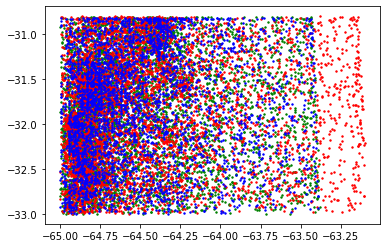

In [12]:
plt.scatter(ds_d3['meanlon'].mean(dim='times'), ds_d3['meanlat'].mean(dim='times'), s=2, c='g')
plt.scatter(ds_d4['meanlon'].mean(dim='times'), ds_d4['meanlat'].mean(dim='times'), s=2, c='r')
plt.scatter(ds_d2['meanlon'].mean(dim='times'), ds_d2['meanlat'].mean(dim='times'), s=2, c='b')

In [13]:
minlon_d4 = ds_d4['meanlon'].min().values
maxlon_d4 = ds_d4['meanlon'].max().values
minlat_d4 = ds_d4['meanlat'].min().values
maxlat_d4 = ds_d4['meanlat'].max().values
print(minlon_d4, maxlon_d4, minlat_d4, maxlat_d4)
print(lon_range, lat_range)

-64.99961 -63.10074 -32.998272 -30.800056
[-65.0, -63.1] [-33.0, -30.8]


/ccsopen/home/zhe1feng1/anaconda3/envs/py310/lib/python3.10/site-packages/numpy/lib/nanfunctions.py:1563: RuntimeWarning: All-NaN slice encountered
  return function_base._ureduce(a,


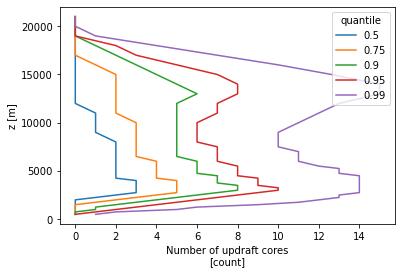

In [14]:
pts = [0.5, 0.75, 0.9, 0.95, 0.99]
nCoreUp_pts_d2 = ds_d2.nCore_up.chunk(dict(tracks=-1)).quantile(pts, dim=('tracks','times'), skipna=True, keep_attrs=True)
nCoreUp_pts_d2.plot.line(y='z')

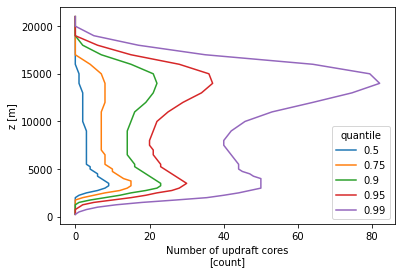

In [15]:
nCoreUp_pts_d3 = ds_d3.nCore_up.chunk(dict(tracks=-1)).quantile(pts, dim=('tracks','times'), skipna=True, keep_attrs=True)
nCoreUp_pts_d3.plot.line(y='z')

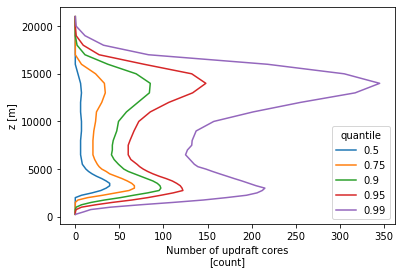

In [16]:
nCoreUp_pts_d4 = ds_d4.nCore_up.chunk(dict(tracks=-1)).quantile(pts, dim=('tracks','times'), skipna=True, keep_attrs=True)
nCoreUp_pts_d4.plot.line(y='z')

/ccsopen/home/zhe1feng1/anaconda3/envs/py310/lib/python3.10/site-packages/numpy/lib/nanfunctions.py:1563: RuntimeWarning: All-NaN slice encountered
  return function_base._ureduce(a,


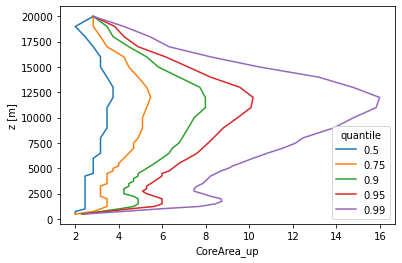

In [17]:
CoreArea_pts_d2 = ds_d2.CoreArea_up.chunk(dict(tracks=-1)).quantile(pts, dim=('tracks','times','core'), skipna=True, keep_attrs=True)
# Convert area to equivalent radius
CoreRadius_pts_d2 = np.sqrt(CoreArea_pts_d2 / np.pi)
CoreRadius_pts_d2.plot.line(y='z')

/ccsopen/home/zhe1feng1/anaconda3/envs/py310/lib/python3.10/site-packages/numpy/lib/nanfunctions.py:1563: RuntimeWarning: All-NaN slice encountered
  return function_base._ureduce(a,


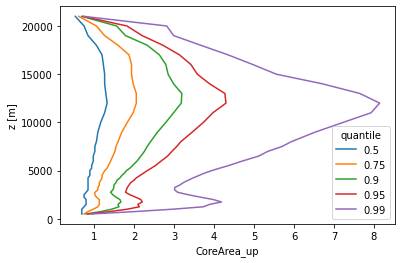

In [18]:
CoreArea_pts_d3 = ds_d3.CoreArea_up.chunk(dict(tracks=-1)).quantile(pts, dim=('tracks','times','core'), skipna=True, keep_attrs=True)
# Convert area to equivalent radius
CoreRadius_pts_d3 = np.sqrt(CoreArea_pts_d3 / np.pi)
CoreRadius_pts_d3.plot.line(y='z')

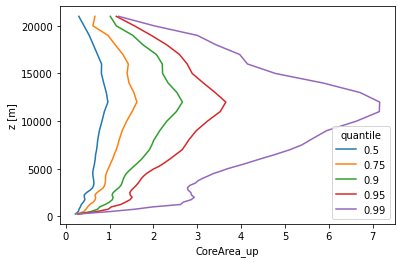

In [19]:
CoreArea_pts_d4 = ds_d4.CoreArea_up.chunk(dict(tracks=-1)).quantile(pts, dim=('tracks','times','core'), skipna=True, keep_attrs=True)
# Convert area to equivalent radius
CoreRadius_pts_d4 = np.sqrt(CoreArea_pts_d4 / np.pi)
CoreRadius_pts_d4.plot.line(y='z')

In [20]:
CoreArea_pts_d2.attrs

{'long_name': 'Updraft core area', 'units': 'km^2'}

## Find merge/split track indices

In [21]:
def find_merge_split_tracks(ds):
    """
    Find merge/split track indices.
    """
    # non-split tracks
    idx_nsplit = np.isnan(ds.start_split_cloudnumber.load())
    # non-merge tracks
    idx_nmerge = np.isnan(ds.end_merge_cloudnumber.load())
    # non-merge and non-split tracks
    idx_nms = np.isnan(ds.start_split_cloudnumber.load()) & np.isnan(ds.end_merge_cloudnumber.load())
    # merge or split tracks
    idx_ms = ~np.isnan(ds.start_split_cloudnumber.load()) | ~np.isnan(ds.end_merge_cloudnumber.load())
    # Group outputs to dictionary
    out_dict = {
        'ms': idx_ms,
        'nms': idx_nms,
        'nm': idx_nmerge,
        'ns': idx_nsplit,
    }
    return out_dict

In [22]:
tid_d2 = find_merge_split_tracks(ds_d2)
tid_d3 = find_merge_split_tracks(ds_d3)
tid_d4 = find_merge_split_tracks(ds_d4)

## Subset DataSets with non-merge/non-split tracks

In [23]:
dsnms_d2 = ds_d2.isel(tracks=tid_d2['nms'])
dsnms_d3 = ds_d3.isel(tracks=tid_d3['nms'])
dsnms_d4 = ds_d4.isel(tracks=tid_d4['nms'])

# Get number of tracks
ntracks_nms_d2 = dsnms_d2.sizes['tracks']
ntracks_nms_d3 = dsnms_d3.sizes['tracks']
ntracks_nms_d4 = dsnms_d4.sizes['tracks']
print(f'D2 non-merge-split tracks: {ntracks_nms_d2}')
print(f'D3 non-merge-split tracks: {ntracks_nms_d3}')
print(f'D4 non-merge-split tracks: {ntracks_nms_d4}')

D2 non-merge-split tracks: 1271
D3 non-merge-split tracks: 2553
D4 non-merge-split tracks: 2833


In [24]:
# Convert MU parcel height from AGL to MSL
mu_parcel_ht_msl_d2 = dsnms_d2.initial_ht_parcel_mu + dsnms_d2.Z_surface
mu_parcel_ht_msl_d3 = dsnms_d3.initial_ht_parcel_mu + dsnms_d3.Z_surface
mu_parcel_ht_msl_d4 = dsnms_d4.initial_ht_parcel_mu + dsnms_d4.Z_surface

mu_parcel_ht_msl_d2.attrs = {
    'long_name': 'Height above MSL of the MU parcel origin',
    'units': 'm',
}
mu_parcel_ht_msl_d3.attrs = {
    'long_name': 'Height above MSL of the MU parcel origin',
    'units': 'm',
}
mu_parcel_ht_msl_d4.attrs = {
    'long_name': 'Height above MSL of the MU parcel origin',
    'units': 'm',
}
# Add to DataSet
dsnms_d2['mu_parcel_ht_msl'] = mu_parcel_ht_msl_d2
dsnms_d3['mu_parcel_ht_msl'] = mu_parcel_ht_msl_d3
dsnms_d4['mu_parcel_ht_msl'] = mu_parcel_ht_msl_d4

## Subset DataSets with non-split tracks (for deep cells)

In [25]:
# dsns_d2 = ds_d2.isel(tracks=tid_d2['ns'])
# dsns_d3 = ds_d3.isel(tracks=tid_d3['ns'])
# dsns_d4 = ds_d4.isel(tracks=tid_d4['ns'])

# ntracks_ns_d2 = dsns_d2.sizes['tracks']
# ntracks_ns_d3 = dsns_d3.sizes['tracks']
# ntracks_ns_d4 = dsns_d4.sizes['tracks']
# print(f'D2 non-split tracks: {ntracks_ns_d2}')
# print(f'D3 non-split tracks: {ntracks_ns_d3}')
# print(f'D4 non-split tracks: {ntracks_ns_d4}')

In [26]:
# Get some constents common for all Datasets
ntimes = dsnms_d2.dims['times']
nz = dsnms_d2.dims['z']
ncores = dsnms_d2.dims['core']

time_res = 5.0  # [min]
xtime = dsnms_d2.times * time_res
height = dsnms_d2.z / 1000.

/tmp/ipykernel_3311147/4178959725.py:2: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
  ntimes = dsnms_d2.dims['times']
/tmp/ipykernel_3311147/4178959725.py:3: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
  nz = dsnms_d2.dims['z']
/tmp/ipykernel_3311147/4178959725.py:4: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
  ncores = dsnms_d2.dims['core']


In [27]:
# Get cell track lifetime: track_duration x time_resolution [min]
track_lifetime_d2 = dsnms_d2['track_duration'].load() * time_res
track_lifetime_d3 = dsnms_d3['track_duration'].load() * time_res
track_lifetime_d4 = dsnms_d4['track_duration'].load() * time_res

# Cell max reflectivity
maxdbz_d2 = dsnms_d2['max_dbz'].load()
maxdbz_d3 = dsnms_d3['max_dbz'].load()
maxdbz_d4 = dsnms_d4['max_dbz'].load()
# Cell ETH
maxETH_10dbz_d2 = dsnms_d2['maxETH_10dbz'].load()
maxETH_10dbz_d3 = dsnms_d3['maxETH_10dbz'].load()
maxETH_10dbz_d4 = dsnms_d4['maxETH_10dbz'].load()
# Cell diameter
cellarea_d2 = dsnms_d2['cell_area'].load()
cellarea_d3 = dsnms_d3['cell_area'].load()
cellarea_d4 = dsnms_d4['cell_area'].load()
celldiam_d2 = 2 * np.sqrt(cellarea_d2 / np.pi)
celldiam_d3 = 2 * np.sqrt(cellarea_d3 / np.pi)
celldiam_d4 = 2 * np.sqrt(cellarea_d4 / np.pi)

In [28]:
# Get preCI MU LNB
preCI_time = -3  # preCI time
# Select preCI time, the drop the times coordinate (this avoids conflict with cell lifetime-max variables that has no times coordinate)
MULNB_d2 = ((dsnms_d2.EL_height_mu).sel(times=preCI_time)/1000).reset_coords('times', drop=True)
MULNB_d3 = ((dsnms_d3.EL_height_mu).sel(times=preCI_time)/1000).reset_coords('times', drop=True)
MULNB_d4 = ((dsnms_d4.EL_height_mu).sel(times=preCI_time)/1000).reset_coords('times', drop=True)

(array([0.00071505, 0.        , 0.0014301 , 0.00572041, 0.00071505,
        0.00071505, 0.00572041, 0.01001073, 0.01144083, 0.00572041,
        0.00929567, 0.00929567, 0.00715052, 0.0178763 , 0.06721487,
        0.1158384 , 0.15373615, 0.18948874, 0.15159099, 0.06506972,
        0.0178763 , 0.03360744, 0.05720415, 0.06506972, 0.11226314,
        0.1558813 , 0.13228459, 0.15802646, 0.15016089, 0.12441902,
        0.10439757, 0.04862353, 0.01144083, 0.        , 0.        ,
        0.        ]),
 array([ 0. ,  0.5,  1. ,  1.5,  2. ,  2.5,  3. ,  3.5,  4. ,  4.5,  5. ,
         5.5,  6. ,  6.5,  7. ,  7.5,  8. ,  8.5,  9. ,  9.5, 10. , 10.5,
        11. , 11.5, 12. , 12.5, 13. , 13.5, 14. , 14.5, 15. , 15.5, 16. ,
        16.5, 17. , 17.5, 18. ]),
 <BarContainer object of 36 artists>)

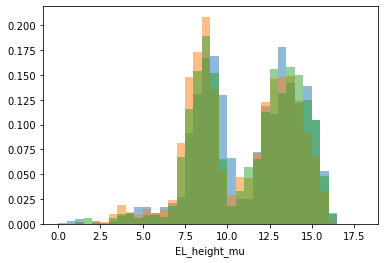

In [29]:
bins = np.arange(0, 18.1, 0.5)
MULNB_d2.plot.hist(bins=bins, alpha=0.5, label='D2', density=True)
MULNB_d3.plot.hist(bins=bins, alpha=0.5, label='D3', density=True)
MULNB_d4.plot.hist(bins=bins, alpha=0.5, label='D4', density=True)

In [30]:
# bins = np.arange(5,200,5)
# track_lifetime_d2.plot.hist(bins=bins, alpha=0.5, label='D2')
# track_lifetime_d3.plot.hist(bins=bins, alpha=0.5, label='D3')
# track_lifetime_d4.plot.hist(bins=bins, alpha=0.5, label='D4')
# plt.legend()

In [31]:
# bins = np.arange(2,16,1)
# maxETH_10dbz_d2.max(dim='times').plot.hist(bins=bins, alpha=0.5, label='D2')
# maxETH_10dbz_d3.max(dim='times').plot.hist(bins=bins, alpha=0.5, label='D3')
# maxETH_10dbz_d4.max(dim='times').plot.hist(bins=bins, alpha=0.5, label='D4')
# plt.legend()

## Get lifetime-max 10dBZ ETH and cell diameter percentile values

In [32]:
ETH_percentiles = [0.33, 0.5, 0.66]
# width_percentiles = [0.33, 0.5, 0.66]
trackmaxETH_10dbz_d2 = maxETH_10dbz_d2.max(dim='times')
max10dbz_pts_d2 = trackmaxETH_10dbz_d2.quantile(ETH_percentiles, keep_attrs=True, skipna=True)
print(f"Max 10dBZ ETH percentile values (D2): {max10dbz_pts_d2.values}")

trackmaxCellDiam_d2 = celldiam_d2.max(dim='times')
maxCellDiam_pts_d2 = trackmaxCellDiam_d2.quantile(ETH_percentiles, keep_attrs=True, skipna=True)
print(f"Max CellDiam percentile values (D2): {maxCellDiam_pts_d2.values}")

Max 10dBZ ETH percentile values (D2): [4.   4.75 6.  ]
Max CellDiam percentile values (D2): [ 9.7720499  10.17107201 11.96826839]


In [33]:
trackmaxETH_10dbz_d3 = maxETH_10dbz_d3.max(dim='times')
max10dbz_pts_d3 = trackmaxETH_10dbz_d3.quantile(ETH_percentiles, keep_attrs=True, skipna=True)
print(f"Max 10dBZ ETH percentile values (D3): {max10dbz_pts_d3.values}")

trackmaxCellDiam_d3 = celldiam_d3.max(dim='times')
maxCellDiam_pts_d3 = trackmaxCellDiam_d3.quantile(ETH_percentiles, keep_attrs=True, skipna=True)
print(f"Max CellDiam percentile values (D3): {maxCellDiam_pts_d3.values}")

Max 10dBZ ETH percentile values (D3): [5.25 6.   7.  ]
Max CellDiam percentile values (D3): [4.95074368 5.58519173 6.635397  ]


In [34]:
trackmaxETH_10dbz_d4 = maxETH_10dbz_d4.max(dim='times')
max10dbz_pts_d4 = trackmaxETH_10dbz_d4.quantile(ETH_percentiles, keep_attrs=True, skipna=True)
print(f"Max 10dBZ ETH percentile values (D4): {max10dbz_pts_d4.values}")

trackmaxCellDiam_d4 = celldiam_d4.max(dim='times')
maxCellDiam_pts_d4 = trackmaxCellDiam_d4.quantile(ETH_percentiles, keep_attrs=True, skipna=True)
print(f"Max CellDiam percentile values (D4): {maxCellDiam_pts_d4.values}")

Max 10dBZ ETH percentile values (D4): [5.  5.5 6.5]
Max CellDiam percentile values (D4): [4.91849089 5.4408474  6.30783129]


## Plot cell diameter & ETH PDF with narrow & wide cell cutoffs

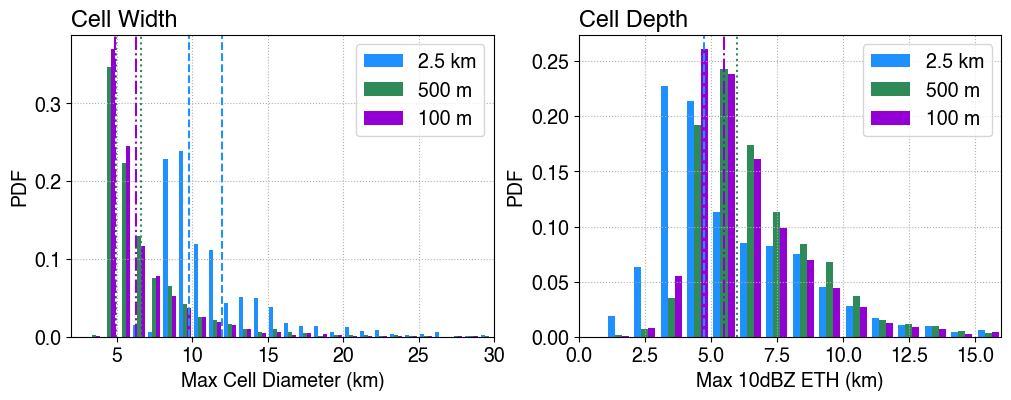

In [35]:
mpl.rcParams['font.size'] = 14
mpl.rcParams['font.family'] = 'Helvetica'

fig, axes = plt.subplots(1, 2, figsize=(12,4), dpi=100)
lcolors = {'d2':'dodgerblue', 'd3':'seagreen', 'd4':'darkviolet'}
name_map = {'d2':'2.5 km', 'd3':'500 m', 'd4':'100 m'}

ax = axes[0]
bins = np.arange(2, 31, 1)
bar_data = [trackmaxCellDiam_d2, trackmaxCellDiam_d3, trackmaxCellDiam_d4]
bar_labels = list(name_map.values())
bar_colors = list(lcolors.values())
ax.hist(bar_data, bins=bins, alpha=1, label=bar_labels, histtype='bar', color=bar_colors, density=True)
ax.legend()
# Percentile lines
ax.axvline(maxCellDiam_pts_d2.sel(quantile=0.33), ls='--', color=lcolors['d2'],)
ax.axvline(maxCellDiam_pts_d2.sel(quantile=0.66), ls='--', color=lcolors['d2'],)
ax.axvline(maxCellDiam_pts_d3.sel(quantile=0.33), ls=':', color=lcolors['d3'],)
ax.axvline(maxCellDiam_pts_d3.sel(quantile=0.66), ls=':', color=lcolors['d3'],)
ax.axvline(maxCellDiam_pts_d4.sel(quantile=0.33), ls='dashdot', color=lcolors['d4'],)
ax.axvline(maxCellDiam_pts_d4.sel(quantile=0.66), ls='dashdot', color=lcolors['d4'],)
ax.set_xlim((2,30))
ax.set_xlabel('Max Cell Diameter (km)')
ax.set_ylabel('PDF')
ax.set_title('Cell Width', loc='left')
ax.grid(ls=':')

ax = axes[1]
bins = np.arange(0, 17, 1)
bar_data = [trackmaxETH_10dbz_d2, trackmaxETH_10dbz_d3, trackmaxETH_10dbz_d4]
ax.hist(bar_data, bins=bins, alpha=1, label=bar_labels, histtype='bar', color=bar_colors, density=True)

# Percentile lines
ax.axvline(max10dbz_pts_d2.sel(quantile=0.5), ls='--', color=lcolors['d2'],)
# ax.axvline(max10dbz_pts_d2.sel(quantile=0.66), ls='--', color=lcolors['d2'],)
ax.axvline(max10dbz_pts_d3.sel(quantile=0.5), ls=':', color=lcolors['d3'],)
# ax.axvline(max10dbz_pts_d3.sel(quantile=0.66), ls=':', color=lcolors['d3'],)
ax.axvline(max10dbz_pts_d4.sel(quantile=0.5), ls='dashdot', color=lcolors['d4'],)
# ax.axvline(max10dbz_pts_d4.sel(quantile=0.66), ls='dashdot', color=lcolors['d4'],)
ax.legend()
ax.set_xlim((0,16))
ax.set_xlabel('Max 10dBZ ETH (km)')
ax.set_ylabel('PDF')
ax.set_title('Cell Depth', loc='left')
ax.grid(ls=':')

# figname = f'{figdir}PDF_maxCellDiam_maxETH10dBZ_d2_d3_d4.png'
# fig.savefig(figname, bbox_inches='tight', dpi=300, facecolor='w')

In [36]:
# bins = np.arange(5,200,5)
# track_lifetime_d2.where(trackmaxETH_10dbz_d2 <= max10dbz_pts_d2.sel(quantile=0.33), drop=True).plot.hist(bins=bins, alpha=0.5, label='D2 (shallow)')
# track_lifetime_d2.where(trackmaxETH_10dbz_d2 >= max10dbz_pts_d2.sel(quantile=0.66), drop=True).plot.hist(bins=bins, alpha=0.5, label='D2 (deep)')
# plt.legend()

In [37]:
# bins = np.arange(5,200,5)
# track_lifetime_d3.where(trackmaxETH_10dbz_d3 <= max10dbz_pts_d3.sel(quantile=0.33), drop=True).plot.hist(bins=bins, alpha=0.5, label='D3 (shallow)')
# track_lifetime_d3.where(trackmaxETH_10dbz_d3 >= max10dbz_pts_d3.sel(quantile=0.66), drop=True).plot.hist(bins=bins, alpha=0.5, label='D3 (deep)')
# plt.legend()

# Separate narrow vs. wide cell DataSets

In [38]:
# MU LNB threshold, cells must have LNB > this to be retained in the subsequent analysis
MULNB_thresh = 6.0  # [km]

# Quantiles for narrow & wide
narrow_qt = 0.33
wide_qt = 0.66

In [39]:
# Define narrow vs. wide thresholds
narrow_diam_d2 = maxCellDiam_pts_d2.sel(quantile=narrow_qt).item()
wide_diam_d2 = maxCellDiam_pts_d2.sel(quantile=wide_qt).item()
print(f'Narrow diameter threshold (D2): {narrow_diam_d2:.02f} km')
print(f'Wide diameter threshold (D2): {wide_diam_d2:.02f} km')

# Separate narrow vs. wide cell DataSets, also require LNB > MULNB_thresh
narrow_tracks_d2 = ((trackmaxCellDiam_d2 <= narrow_diam_d2) & (MULNB_d2 > MULNB_thresh)).compute()
wide_tracks_d2 = ((trackmaxCellDiam_d2 >= wide_diam_d2) & (MULNB_d2 > MULNB_thresh)).compute()
# Subset DataSets
ds_narrow_d2 = dsnms_d2.where(narrow_tracks_d2, drop=True)
ds_wide_d2 = dsnms_d2.where(wide_tracks_d2, drop=True)
ntracks_narrow_d2 = ds_narrow_d2.sizes['tracks']
ntracks_wide_d2 = ds_wide_d2.sizes['tracks']
print(f'Number of narrow cells (D2): {ntracks_narrow_d2}')
print(f'Number of wide cells (D2): {ntracks_wide_d2}')

# Get cell track lifetime: track_duration x time_resolution [min]
narrow_track_lifetime_d2 = ds_narrow_d2.track_duration * time_res
wide_track_lifetime_d2 = ds_wide_d2.track_duration * time_res
# Lifetime-max 10dBZ ETH
narrow_maxETH10dbz_d2 = ds_narrow_d2.maxETH_10dbz.max(dim='times')
wide_maxETH10dbz_d2 = ds_wide_d2.maxETH_10dbz.max(dim='times')
# Lifetime-max diameter
narrow_maxdiam_d2 = 2 * np.sqrt(ds_narrow_d2.cell_area.max(dim='times') / np.pi)
wide_maxdiam_d2 = 2 * np.sqrt(ds_wide_d2.cell_area.max(dim='times') / np.pi)

Narrow diameter threshold (D2): 9.77 km
Wide diameter threshold (D2): 11.97 km
Number of narrow cells (D2): 588
Number of wide cells (D2): 446


In [40]:
# Define narrow vs. wide thresholds
narrow_diam_d3 = maxCellDiam_pts_d3.sel(quantile=narrow_qt).item()
wide_diam_d3 = maxCellDiam_pts_d3.sel(quantile=wide_qt).item()
print(f'Narrow diameter threshold (D3): {narrow_diam_d3:.02f} km')
print(f'Wide diameter threshold (D3): {wide_diam_d3:.02f} km')

# Separate narrow vs. wide cell DataSets, also require LNB > MULNB_thresh
narrow_tracks_d3 = ((trackmaxCellDiam_d3 <= narrow_diam_d3) & (MULNB_d3 > MULNB_thresh)).compute()
wide_tracks_d3 = ((trackmaxCellDiam_d3 >= wide_diam_d3) & (MULNB_d3 > MULNB_thresh)).compute()
# Subset DataSets
ds_narrow_d3 = dsnms_d3.where(narrow_tracks_d3, drop=True)
ds_wide_d3 = dsnms_d3.where(wide_tracks_d3, drop=True)
ntracks_narrow_d3 = ds_narrow_d3.sizes['tracks']
ntracks_wide_d3 = ds_wide_d3.sizes['tracks']
print(f'Number of narrow cells (D3): {ntracks_narrow_d3}')
print(f'Number of wide cells (D3): {ntracks_wide_d3}')

# Get cell track lifetime: track_duration x time_resolution [min]
narrow_track_lifetime_d3 = ds_narrow_d3.track_duration * time_res
wide_track_lifetime_d3 = ds_wide_d3.track_duration * time_res
# Lifetime-max 10dBZ ETH
narrow_maxETH10dbz_d3 = ds_narrow_d3.maxETH_10dbz.max(dim='times')
wide_maxETH10dbz_d3 = ds_wide_d3.maxETH_10dbz.max(dim='times')
# Lifetime-max diameter
narrow_maxdiam_d3 = 2 * np.sqrt(ds_narrow_d3.cell_area.max(dim='times') / np.pi)
wide_maxdiam_d3 = 2 * np.sqrt(ds_wide_d3.cell_area.max(dim='times') / np.pi)

Narrow diameter threshold (D3): 4.95 km
Wide diameter threshold (D3): 6.64 km
Number of narrow cells (D3): 824
Number of wide cells (D3): 823


In [41]:
# Define narrow vs. wide thresholds
narrow_diam_d4 = maxCellDiam_pts_d4.sel(quantile=narrow_qt).item()
wide_diam_d4 = maxCellDiam_pts_d4.sel(quantile=wide_qt).item()
print(f'Narrow diameter threshold (D4): {narrow_diam_d4:.02f} km')
print(f'Wide diameter threshold (D4): {wide_diam_d4:.02f} km')

# Separate narrow vs. wide cell DataSets, also require LNB > MULNB_thresh
narrow_tracks_d4 = ((trackmaxCellDiam_d4 <= narrow_diam_d4) & (MULNB_d4 > MULNB_thresh)).compute()
wide_tracks_d4 = ((trackmaxCellDiam_d4 >= wide_diam_d4) & (MULNB_d4 > MULNB_thresh)).compute()
# Subset DataSets
ds_narrow_d4 = dsnms_d4.where(narrow_tracks_d4, drop=True)
ds_wide_d4 = dsnms_d4.where(wide_tracks_d4, drop=True)
ntracks_narrow_d4 = ds_narrow_d4.sizes['tracks']
ntracks_wide_d4 = ds_wide_d4.sizes['tracks']
print(f'Number of narrow cells (D4): {ntracks_narrow_d4}')
print(f'Number of wide cells (D4): {ntracks_wide_d4}')

# Get cell track lifetime: track_duration x time_resolution [min]
narrow_track_lifetime_d4 = ds_narrow_d4.track_duration * time_res
wide_track_lifetime_d4 = ds_wide_d4.track_duration * time_res
# Lifetime-max 10dBZ ETH
narrow_maxETH10dbz_d4 = ds_narrow_d4.maxETH_10dbz.max(dim='times')
wide_maxETH10dbz_d4 = ds_wide_d4.maxETH_10dbz.max(dim='times')
# Lifetime-max diameter
narrow_maxdiam_d4 = 2 * np.sqrt(ds_narrow_d4.cell_area.max(dim='times') / np.pi)
wide_maxdiam_d4 = 2 * np.sqrt(ds_wide_d4.cell_area.max(dim='times') / np.pi)

Narrow diameter threshold (D4): 4.92 km
Wide diameter threshold (D4): 6.31 km
Number of narrow cells (D4): 939
Number of wide cells (D4): 914


# Separate shallow vs. deep cell DataSets

## Get lifetime-max 10-dBZ ETH median values as shallow vs. deep cell threhsolds for both narrow & wide cells

In [42]:
maxETH10dbz_thresh_d2 = max10dbz_pts_d2.sel(quantile=0.5).item()
print(f"D2 shallow-Deep max 10dBZ ETH threshold: {maxETH10dbz_thresh_d2} km")

maxETH10dbz_thresh_d3 = max10dbz_pts_d3.sel(quantile=0.5).item()
print(f"D3 shallow-Deep max 10dBZ ETH threshold: {maxETH10dbz_thresh_d3} km")

maxETH10dbz_thresh_d4 = max10dbz_pts_d4.sel(quantile=0.5).item()
print(f"D4 shallow-Deep max 10dBZ ETH threshold: {maxETH10dbz_thresh_d4} km")

D2 shallow-Deep max 10dBZ ETH threshold: 4.75 km
D3 shallow-Deep max 10dBZ ETH threshold: 6.0 km
D4 shallow-Deep max 10dBZ ETH threshold: 5.5 km


## D2 wide cell DataSet

In [43]:
# Get median lifetime-max 10dBZ ETH as threshold to further separate shallow vs. deep cells
wide_maxETH10dbz_thresh_d2 = wide_maxETH10dbz_d2.median()
print(f'D2 wide cell 10-dBZ ETH median: {wide_maxETH10dbz_thresh_d2:.01f} km')

# Separate shallow & deep DataSets
ds_wide_deep_d2 = ds_wide_d2.where(wide_maxETH10dbz_d2 >= maxETH10dbz_thresh_d2, drop=True)
ds_wide_shallow_d2 = ds_wide_d2.where(wide_maxETH10dbz_d2 < maxETH10dbz_thresh_d2, drop=True)
# ds_wide_deep_d2 = ds_wide_d2.where(wide_maxETH10dbz_d2 >= wide_maxETH10dbz_thresh_d2, drop=True)
# ds_wide_shallow_d2 = ds_wide_d2.where(wide_maxETH10dbz_d2 < wide_maxETH10dbz_thresh_d2, drop=True)

# Get number of tracks
ntracks_wide_deep_d2 = ds_wide_deep_d2.dims['tracks']
ntracks_wide_shallow_d2 = ds_wide_shallow_d2.dims['tracks']
print(f'D2 number of wide & deep tracks: {ntracks_wide_deep_d2}')
print(f'D2 number of wide & shallow tracks: {ntracks_wide_shallow_d2}')

D2 wide cell 10-dBZ ETH median: 7.5 km
D2 number of wide & deep tracks: 379
D2 number of wide & shallow tracks: 67


/tmp/ipykernel_3311147/360283527.py:12: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
  ntracks_wide_deep_d2 = ds_wide_deep_d2.dims['tracks']
/tmp/ipykernel_3311147/360283527.py:13: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
  ntracks_wide_shallow_d2 = ds_wide_shallow_d2.dims['tracks']


## D2 narrow cell DataSet

In [44]:
# Get median lifetime-max 10dBZ ETH as threshold to further separate shallow vs. deep cells
narrow_maxETH10dbz_thresh_d2 = narrow_maxETH10dbz_d2.median()
print(f'D2 narrow cell 10-dBZ ETH median: {narrow_maxETH10dbz_thresh_d2:.01f} km')

# Separate shallow & deep DataSets
# ds_narrow_deep_d2 = ds_narrow_d2.where(narrow_maxETH10dbz_d2 >= narrow_maxETH10dbz_thresh_d2, drop=True)
# ds_narrow_shallow_d2 = ds_narrow_d2.where(narrow_maxETH10dbz_d2 < narrow_maxETH10dbz_thresh_d2, drop=True)
ds_narrow_deep_d2 = ds_narrow_d2.where(narrow_maxETH10dbz_d2 >= maxETH10dbz_thresh_d2, drop=True)
ds_narrow_shallow_d2 = ds_narrow_d2.where(narrow_maxETH10dbz_d2 < maxETH10dbz_thresh_d2, drop=True)

# Get number of tracks
ntracks_narrow_deep_d2 = ds_narrow_deep_d2.dims['tracks']
ntracks_narrow_shallow_d2 = ds_narrow_shallow_d2.dims['tracks']
print(f'D2 number of narrow & deep tracks: {ntracks_narrow_deep_d2}')
print(f'D2 number of narrow & shallow tracks: {ntracks_narrow_shallow_d2}')

D2 narrow cell 10-dBZ ETH median: 3.8 km
D2 number of narrow & deep tracks: 134
D2 number of narrow & shallow tracks: 454


/tmp/ipykernel_3311147/2686371051.py:12: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
  ntracks_narrow_deep_d2 = ds_narrow_deep_d2.dims['tracks']
/tmp/ipykernel_3311147/2686371051.py:13: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
  ntracks_narrow_shallow_d2 = ds_narrow_shallow_d2.dims['tracks']


In [45]:
# # Define cell lifetime range for filtering, unit: [min]
# # shallow_lifetime_range = [15,100]
# shallow_lifetime_range = [10,200]
# deep_lifetime_range = [10,200]

# # Select percentiles to define shallow vs. deep cells
# percentile_shallow = ETH_percentiles[0]
# percentile_deep = ETH_percentiles[2]
# print(f'Percentile thresholds for shallow: {percentile_shallow}, deep: {percentile_deep}')

In [46]:
# trackmaxETH_10dbz_d2.shape, dsns_d2.end_merge_cloudnumber.shape

In [47]:
# # Get shallow vs. deep cell/track IDs
# # Shallow: 1. ETH; 2. Lifetime; 3. Not end as merging
# cid_shallow_d2 = (
#     (trackmaxETH_10dbz_d2 <= max10dbz_pts_d2.sel(quantile=percentile_shallow)) \
#     & (track_lifetime_d2 >= min(shallow_lifetime_range)) \
#     & (np.isnan(dsns_d2.end_merge_cloudnumber)) \
# )
# # Deep: 1. ETH; 2. Lifetime
# cid_deep_d2 = (
#     (trackmaxETH_10dbz_d2 >= max10dbz_pts_d2.sel(quantile=percentile_deep)) \
#     & (track_lifetime_d2 >= min(deep_lifetime_range))
# )

# print('D2 shallow', np.count_nonzero(cid_shallow_d2 == True))
# print('D2 deep', np.count_nonzero(cid_deep_d2 == True))

# # Check ETH histogram for shallow vs. deep groups
# bins = np.arange(0,20,1)
# trackmaxETH_10dbz_d2.sel(tracks=cid_shallow_d2).plot.hist(bins=bins, alpha=0.5, label='D2 shallow')
# trackmaxETH_10dbz_d2.sel(tracks=cid_deep_d2).plot.hist(bins=bins, alpha=0.5, label='D2 deep')

In [48]:
# # Get shallow vs. deep cell/track IDs
# # Shallow: 1. ETH; 2. Lifetime; 3. Not end as merging
# cid_shallow_d3 = (
#     (trackmaxETH_10dbz_d3 <= max10dbz_pts_d3.sel(quantile=percentile_shallow)) \
#     & (track_lifetime_d3 >= min(shallow_lifetime_range)) \
#     & (np.isnan(dsns_d3.end_merge_cloudnumber)) \
# )
# # Deep: 1. ETH; 2. Lifetime
# cid_deep_d3 = (
#     (trackmaxETH_10dbz_d3 >= max10dbz_pts_d3.sel(quantile=percentile_deep)) \
#     & (track_lifetime_d3 >= min(deep_lifetime_range))
# )

# print('D3 shallow', np.count_nonzero(cid_shallow_d3 == True))
# print('D3 deep', np.count_nonzero(cid_deep_d3 == True))

# # Check ETH histogram for shallow vs. deep groups
# bins = np.arange(0,20,1)
# trackmaxETH_10dbz_d3.sel(tracks=cid_shallow_d3).plot.hist(bins=bins, alpha=0.5, label='d3 shallow')
# trackmaxETH_10dbz_d3.sel(tracks=cid_deep_d3).plot.hist(bins=bins, alpha=0.5, label='d3 deep')

In [49]:
# # Get shallow vs. deep cell/track IDs
# # Shallow: 1. ETH; 2. Lifetime; 3. Not end as merging
# cid_shallow_d4 = (
#     (trackmaxETH_10dbz_d4 <= max10dbz_pts_d4.sel(quantile=percentile_shallow)) \
#     & (track_lifetime_d4 >= min(shallow_lifetime_range)) \
#     & (np.isnan(dsns_d4.end_merge_cloudnumber)) \
# )
# # Deep: 1. ETH; 2. Lifetime
# cid_deep_d4 = (
#     (trackmaxETH_10dbz_d4 >= max10dbz_pts_d4.sel(quantile=percentile_deep)) \
#     & (track_lifetime_d4 >= min(deep_lifetime_range))
# )

# print('d4 shallow', np.count_nonzero(cid_shallow_d4 == True))
# print('d4 deep', np.count_nonzero(cid_deep_d4 == True))

# # Check ETH histogram for shallow vs. deep groups
# bins = np.arange(0,20,1)
# trackmaxETH_10dbz_d4.sel(tracks=cid_shallow_d4).plot.hist(bins=bins, alpha=0.5, label='d4 shallow')
# trackmaxETH_10dbz_d4.sel(tracks=cid_deep_d4).plot.hist(bins=bins, alpha=0.5, label='d4 deep')

In [50]:
# # Get shallow vs. deep cell/track IDs
# cid_shallow_d3 = (trackmaxETH_10dbz_d3 <= max10dbz_pts_d3.sel(quantile=percentile_shallow)) & (track_lifetime_d3 >= min(shallow_lifetime_range))
# cid_deep_d3 = (trackmaxETH_10dbz_d3 >= max10dbz_pts_d3.sel(quantile=percentile_deep)) & (track_lifetime_d3 >= min(deep_lifetime_range))

# # Check ETH histogram for shallow vs. deep groups
# bins = np.arange(0,16,1)
# trackmaxETH_10dbz_d3.sel(tracks=cid_shallow_d3).plot.hist(bins=bins, alpha=0.5, label='d3 shallow')
# trackmaxETH_10dbz_d3.sel(tracks=cid_deep_d3).plot.hist(bins=bins, alpha=0.5, label='d3 deep')

In [51]:
# # Get shallow vs. deep cell/track IDs
# cid_shallow_d4 = (trackmaxETH_10dbz_d4 <= max10dbz_pts_d4.sel(quantile=percentile_shallow)) & (track_lifetime_d4 >= min(shallow_lifetime_range))
# cid_deep_d4 = (trackmaxETH_10dbz_d4 >= max10dbz_pts_d4.sel(quantile=percentile_deep)) & (track_lifetime_d4 >= min(deep_lifetime_range))

# # Check ETH histogram for shallow vs. deep groups
# bins = np.arange(0,16,1)
# trackmaxETH_10dbz_d4.sel(tracks=cid_shallow_d4).plot.hist(bins=bins, alpha=0.5, label='d4 shallow')
# trackmaxETH_10dbz_d4.sel(tracks=cid_deep_d4).plot.hist(bins=bins, alpha=0.5, label='d4 deep')

## Filter updraft variables above max ETH

In [52]:
# Buffer height above which to filter updraft variables [km]
ETH_buffer = 1.0

In [53]:
# Filter updrafts above 10dBZ ETH + 1 km
maxETH_10dbz_narrow_deep_d2 = ds_narrow_deep_d2['maxETH_10dbz'].load()
CoreArea_up_narrow_deep_d2 = ds_narrow_deep_d2['CoreArea_up'].where(height <= maxETH_10dbz_narrow_deep_d2+ETH_buffer).isel(core=0).load()
CoreMaxW_up_narrow_deep_d2 = ds_narrow_deep_d2['CoreMaxW_up'].where(height <= maxETH_10dbz_narrow_deep_d2+ETH_buffer).isel(core=0).load()

maxETH_10dbz_narrow_shallow_d2 = ds_narrow_shallow_d2['maxETH_10dbz'].load()
CoreArea_up_narrow_shallow_d2 = ds_narrow_shallow_d2['CoreArea_up'].where(height <= maxETH_10dbz_narrow_shallow_d2+ETH_buffer).isel(core=0).load()
CoreMaxW_up_narrow_shallow_d2 = ds_narrow_shallow_d2['CoreMaxW_up'].where(height <= maxETH_10dbz_narrow_shallow_d2+ETH_buffer).isel(core=0).load()

# Number of sample at each time & height for all tracks
nsample_CoreArea_up_narrow_shallow_d2 = (CoreArea_up_narrow_shallow_d2 > 0).sum(dim='tracks')
nsample_CoreArea_up_narrow_deep_d2 = (CoreArea_up_narrow_deep_d2 > 0).sum(dim='tracks')
# Make 0 sample NaN
nsample_CoreArea_up_narrow_deep_d2 = nsample_CoreArea_up_narrow_deep_d2.where(nsample_CoreArea_up_narrow_deep_d2 > 0)
nsample_CoreArea_up_narrow_shallow_d2 = nsample_CoreArea_up_narrow_shallow_d2.where(nsample_CoreArea_up_narrow_shallow_d2 > 0)

In [54]:
# Filter updrafts above 10dBZ ETH + 1 km
maxETH_10dbz_wide_deep_d2 = ds_wide_deep_d2['maxETH_10dbz'].load()
CoreArea_up_wide_deep_d2 = ds_wide_deep_d2['CoreArea_up'].where(height <= maxETH_10dbz_wide_deep_d2+ETH_buffer).isel(core=0).load()
CoreMaxW_up_wide_deep_d2 = ds_wide_deep_d2['CoreMaxW_up'].where(height <= maxETH_10dbz_wide_deep_d2+ETH_buffer).isel(core=0).load()

maxETH_10dbz_wide_shallow_d2 = ds_wide_shallow_d2['maxETH_10dbz'].load()
CoreArea_up_wide_shallow_d2 = ds_wide_shallow_d2['CoreArea_up'].where(height <= maxETH_10dbz_wide_shallow_d2+ETH_buffer).isel(core=0).load()
CoreMaxW_up_wide_shallow_d2 = ds_wide_shallow_d2['CoreMaxW_up'].where(height <= maxETH_10dbz_wide_shallow_d2+ETH_buffer).isel(core=0).load()

# Number of sample at each time & height for all tracks
nsample_CoreArea_up_wide_shallow_d2 = (CoreArea_up_wide_shallow_d2 > 0).sum(dim='tracks')
nsample_CoreArea_up_wide_deep_d2 = (CoreArea_up_wide_deep_d2 > 0).sum(dim='tracks')
# Make 0 sample NaN
nsample_CoreArea_up_wide_deep_d2 = nsample_CoreArea_up_wide_deep_d2.where(nsample_CoreArea_up_wide_deep_d2 > 0)
nsample_CoreArea_up_wide_shallow_d2 = nsample_CoreArea_up_wide_shallow_d2.where(nsample_CoreArea_up_wide_shallow_d2 > 0)

In [55]:
# dss_shallow_d2 = dsns_d2.sel(tracks=cid_shallow_d2)
# dss_deep_d2 = dsns_d2.sel(tracks=cid_deep_d2)

# # Filter updrafts above 10dBZ ETH + 1 km
# maxETH_10dbz_shallow_d2 = dss_shallow_d2['maxETH_10dbz'].load()
# CoreArea_up_shallow_d2 = dss_shallow_d2['CoreArea_up'].where(height <= maxETH_10dbz_shallow_d2+1).isel(core=0).load()
# CoreMaxW_up_shallow_d2 = dss_shallow_d2['CoreMaxW_up'].where(height <= maxETH_10dbz_shallow_d2+1).isel(core=0).load()

# maxETH_10dbz_deep_d2 = dss_deep_d2['maxETH_10dbz'].load()
# CoreArea_up_deep_d2 = dss_deep_d2['CoreArea_up'].where(height <= maxETH_10dbz_deep_d2+1).isel(core=0).load()
# CoreMaxW_up_deep_d2 = dss_deep_d2['CoreMaxW_up'].where(height <= maxETH_10dbz_deep_d2+1).isel(core=0).load()

In [56]:
# dss_shallow_d3 = dsns_d3.sel(tracks=cid_shallow_d3)
# dss_deep_d3 = dsns_d3.sel(tracks=cid_deep_d3)

# # Filter updrafts above 10dBZ ETH + 1 km
# maxETH_10dbz_shallow_d3 = dss_shallow_d3['maxETH_10dbz'].load()
# CoreArea_up_shallow_d3 = dss_shallow_d3['CoreArea_up'].where(height <= maxETH_10dbz_shallow_d3+1).isel(core=0).load()
# CoreMaxW_up_shallow_d3 = dss_shallow_d3['CoreMaxW_up'].where(height <= maxETH_10dbz_shallow_d3+1).isel(core=0).load()

# maxETH_10dbz_deep_d3 = dss_deep_d3['maxETH_10dbz'].load()
# CoreArea_up_deep_d3 = dss_deep_d3['CoreArea_up'].where(height <= maxETH_10dbz_deep_d3+1).isel(core=0).load()
# CoreMaxW_up_deep_d3 = dss_deep_d3['CoreMaxW_up'].where(height <= maxETH_10dbz_deep_d3+1).isel(core=0).load()

In [57]:
# dss_shallow_d4 = dsns_d4.sel(tracks=cid_shallow_d4)
# dss_deep_d4 = dsns_d4.sel(tracks=cid_deep_d4)

# # Filter updrafts above 10dBZ ETH + 1 km
# maxETH_10dbz_shallow_d4 = dss_shallow_d4['maxETH_10dbz'].load()
# CoreArea_up_shallow_d4 = dss_shallow_d4['CoreArea_up'].where(height <= maxETH_10dbz_shallow_d4+1).isel(core=0).load()
# CoreMaxW_up_shallow_d4 = dss_shallow_d4['CoreMaxW_up'].where(height <= maxETH_10dbz_shallow_d4+1).isel(core=0).load()

# maxETH_10dbz_deep_d4 = dss_deep_d4['maxETH_10dbz'].load()
# CoreArea_up_deep_d4 = dss_deep_d4['CoreArea_up'].where(height <= maxETH_10dbz_deep_d4+1).isel(core=0).load()
# CoreMaxW_up_deep_d4 = dss_deep_d4['CoreMaxW_up'].where(height <= maxETH_10dbz_deep_d4+1).isel(core=0).load()

In [58]:
# # Number of sample at each time & height for all tracks
# nsample_CoreArea_up_shallow_d2 = (CoreArea_up_shallow_d2 > 0).sum(dim='tracks')
# nsample_CoreArea_up_deep_d2 = (CoreArea_up_deep_d2 > 0).sum(dim='tracks')
# # Make 0 sample NaN
# nsample_CoreArea_up_deep_d2 = nsample_CoreArea_up_deep_d2.where(nsample_CoreArea_up_deep_d2 > 0)
# nsample_CoreArea_up_shallow_d2 = nsample_CoreArea_up_shallow_d2.where(nsample_CoreArea_up_shallow_d2 > 0)

In [59]:
# # Number of sample at each time & height for all tracks
# nsample_CoreArea_up_shallow_d3 = (CoreArea_up_shallow_d3 > 0).sum(dim='tracks')
# nsample_CoreArea_up_deep_d3 = (CoreArea_up_deep_d3 > 0).sum(dim='tracks')
# # Make 0 sample NaN
# nsample_CoreArea_up_deep_d3 = nsample_CoreArea_up_deep_d3.where(nsample_CoreArea_up_deep_d3 > 0)
# nsample_CoreArea_up_shallow_d3 = nsample_CoreArea_up_shallow_d3.where(nsample_CoreArea_up_shallow_d3 > 0)

In [60]:
# # Number of sample at each time & height for all tracks
# nsample_CoreArea_up_shallow_d4 = (CoreArea_up_shallow_d4 > 0).sum(dim='tracks')
# nsample_CoreArea_up_deep_d4 = (CoreArea_up_deep_d4 > 0).sum(dim='tracks')
# # Make 0 sample NaN
# nsample_CoreArea_up_deep_d4 = nsample_CoreArea_up_deep_d4.where(nsample_CoreArea_up_deep_d4 > 0)
# nsample_CoreArea_up_shallow_d4 = nsample_CoreArea_up_shallow_d4.where(nsample_CoreArea_up_shallow_d4 > 0)

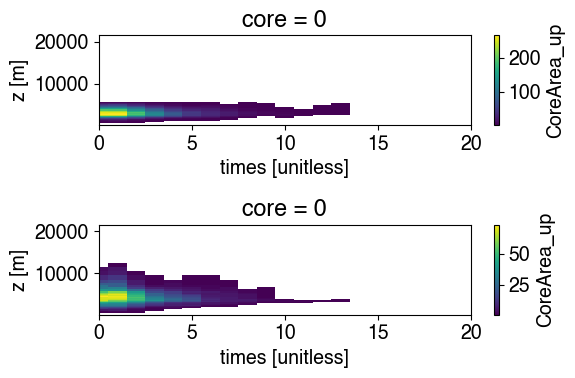

In [61]:
fig, axes = plt.subplots(2, 1, dpi=100)
nsample_CoreArea_up_narrow_shallow_d2.transpose().plot(ax=axes[0])
nsample_CoreArea_up_narrow_deep_d2.transpose().plot(ax=axes[1])
axes[0].set_xlim(0,20)
axes[1].set_xlim(0,20)
fig.tight_layout()

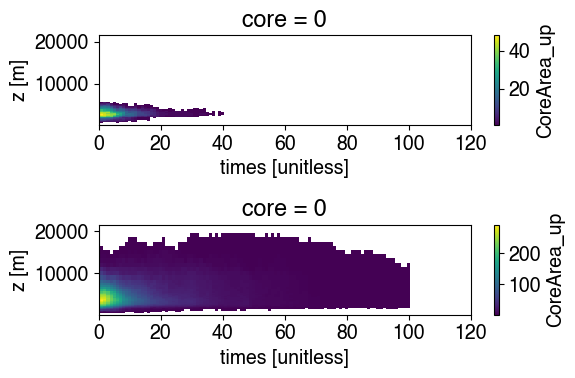

In [62]:
fig, axes = plt.subplots(2, 1, dpi=100)
nsample_CoreArea_up_wide_shallow_d2.transpose().plot(ax=axes[0])
nsample_CoreArea_up_wide_deep_d2.transpose().plot(ax=axes[1])
axes[0].set_xlim(0,120)
axes[1].set_xlim(0,120)
fig.tight_layout()

In [63]:
# fig, axes = plt.subplots(2, 1, dpi=100)
# nsample_CoreArea_up_narrow_shallow_d2.transpose().plot(ax=axes[0])
# nsample_CoreArea_up_narrow_deep_d2.transpose().plot(ax=axes[1])
# axes[0].set_xlim(0,20)
# axes[1].set_xlim(0,20)
# fig.tight_layout()

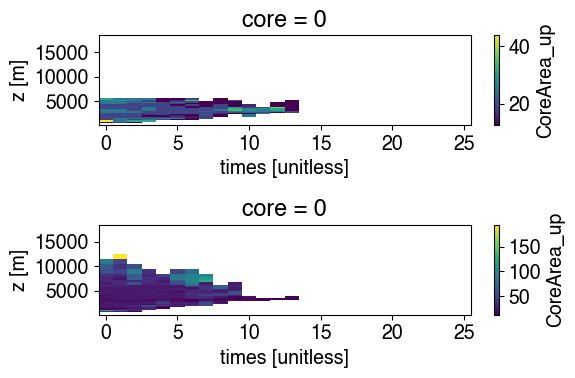

In [64]:
fig, axes = plt.subplots(2, 1, dpi=100)
CoreArea_up_narrow_shallow_d2.median(dim='tracks').transpose().sel(times=slice(0,25), z=slice(0,18000)).plot(ax=axes[0])
CoreArea_up_narrow_deep_d2.median(dim='tracks').transpose().sel(times=slice(0,25), z=slice(0,18000)).plot(ax=axes[1])
fig.tight_layout()

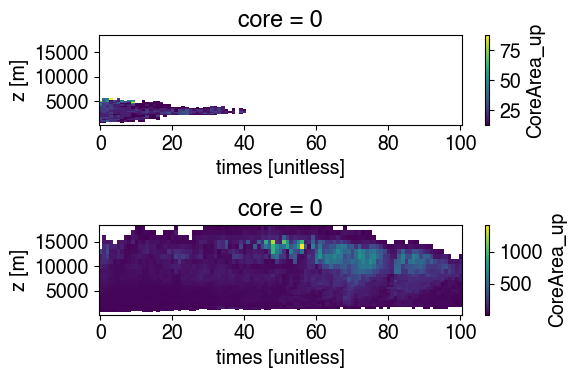

In [65]:
fig, axes = plt.subplots(2, 1, dpi=100)
CoreArea_up_wide_shallow_d2.median(dim='tracks').transpose().sel(times=slice(0,100), z=slice(0,18000)).plot(ax=axes[0])
CoreArea_up_wide_deep_d2.median(dim='tracks').transpose().sel(times=slice(0,100), z=slice(0,18000)).plot(ax=axes[1])
fig.tight_layout()

In [66]:
# fig, axes = plt.subplots(2, 1, dpi=100)
# CoreArea_up_shallow_d4.median(dim='tracks').transpose().sel(times=slice(0,25), z=slice(0,18000)).plot(ax=axes[0])
# CoreArea_up_deep_d4.median(dim='tracks').transpose().sel(times=slice(0,25), z=slice(0,18000)).plot(ax=axes[1])
# fig.tight_layout()

In [67]:
# fig, axes = plt.subplots(2, 1, dpi=100)
# CoreMaxW_up_shallow_d2.median(dim='tracks').transpose().sel(times=slice(0,25), z=slice(0,18000)).plot(ax=axes[0])
# CoreMaxW_up_deep_d2.median(dim='tracks').transpose().sel(times=slice(0,25), z=slice(0,18000)).plot(ax=axes[1])
# fig.tight_layout()

## Get preCI environmental variables: LCL, LFC

In [68]:
# Time for representative environment
time_env = -3

# Convert HAMSL to AGL, then select a representative time before CI
LCL_mu_narrow_deep_d2 = (ds_narrow_deep_d2['LCL_height_mu'] + ds_narrow_deep_d2['Z_surface']).sel(times=time_env) / 1000.
LCL_mu_narrow_shallow_d2 = (ds_narrow_shallow_d2['LCL_height_mu'] + ds_narrow_shallow_d2['Z_surface']).sel(times=time_env) / 1000.
LFC_mu_narrow_deep_d2 = (ds_narrow_deep_d2['LFC_height_mu'] + ds_narrow_deep_d2['Z_surface']).sel(times=time_env) / 1000.
LFC_mu_narrow_shallow_d2 = (ds_narrow_shallow_d2['LFC_height_mu'] + ds_narrow_shallow_d2['Z_surface']).sel(times=time_env) / 1000.

In [69]:
LCL_mu_wide_deep_d2 = (ds_wide_deep_d2['LCL_height_mu'] + ds_wide_deep_d2['Z_surface']).sel(times=time_env) / 1000.
LCL_mu_wide_shallow_d2 = (ds_wide_shallow_d2['LCL_height_mu'] + ds_wide_shallow_d2['Z_surface']).sel(times=time_env) / 1000.
LFC_mu_wide_deep_d2 = (ds_wide_deep_d2['LFC_height_mu'] + ds_wide_deep_d2['Z_surface']).sel(times=time_env) / 1000.
LFC_mu_wide_shallow_d2 = (ds_wide_shallow_d2['LFC_height_mu'] + ds_wide_shallow_d2['Z_surface']).sel(times=time_env) / 1000.

In [70]:
# # Time for representative environment
# time_env = -3

# # Convert HAMSL to AGL, then select a representative time before CI
# LCL_mu_deep_d2 = (dss_deep_d2['LCL_height_mu'] + dss_deep_d2['Z_surface']).sel(times=time_env) / 1000.
# LCL_mu_shallow_d2 = (dss_shallow_d2['LCL_height_mu'] + dss_shallow_d2['Z_surface']).sel(times=time_env) / 1000.
# LFC_mu_deep_d2 = (dss_deep_d2['LFC_height_mu'] + dss_deep_d2['Z_surface']).sel(times=time_env) / 1000.
# LFC_mu_shallow_d2 = (dss_shallow_d2['LFC_height_mu'] + dss_shallow_d2['Z_surface']).sel(times=time_env) / 1000.

(array([ 2., 10., 16., 21., 24., 28., 21., 10.,  0.,  2.]),
 array([0.67641246, 1.1202207 , 1.5640287 , 2.0078368 , 2.451645  ,
        2.8954532 , 3.3392613 , 3.7830694 , 4.2268777 , 4.670686  ,
        5.114494  ], dtype=float32),
 <BarContainer object of 10 artists>)

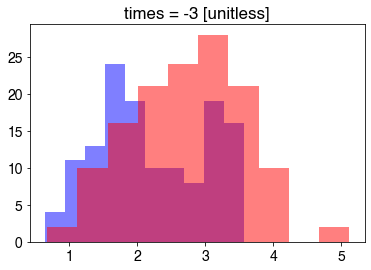

In [71]:
LCL_mu_narrow_deep_d2.plot.hist(color='b', alpha=0.5)
LFC_mu_narrow_deep_d2.plot.hist(color='r', alpha=0.5)

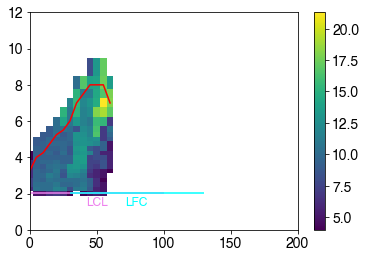

In [72]:
itrack = 2
plt.pcolormesh(xtime, height, 2*np.sqrt(CoreArea_up_wide_deep_d2.isel(tracks=itrack).transpose()/np.pi), shading='nearest')
plt.plot(xtime, maxETH_10dbz_wide_deep_d2.isel(tracks=itrack), color='r')
line_length = 100
LCL_t0 = 0
LCL_t1 = LCL_t0 + line_length
LFC_t0 = 30
LFC_t1 = LFC_t0 + line_length
plt.hlines(y=LCL_mu_wide_deep_d2.isel(tracks=itrack), xmin=LCL_t0, xmax=LCL_t1, color='violet')
plt.hlines(y=LFC_mu_wide_deep_d2.isel(tracks=itrack), xmin=LFC_t0, xmax=LFC_t1, color='cyan')
LCL_text_x = LCL_t0 + line_length / 2
LCL_text_y = LCL_mu_wide_deep_d2.isel(tracks=itrack)-0.2
LFC_text_x = LFC_t0 + line_length / 2
LFC_text_y = LFC_mu_wide_deep_d2.isel(tracks=itrack)-0.2
plt.text(LCL_text_x, LCL_text_y, 'LCL', ha='center', va='top', color='violet', fontsize=12)
plt.text(LFC_text_x, LFC_text_y, 'LFC', ha='center', va='top', color='cyan', fontsize=12)
plt.xlim(0,200)
plt.ylim(0,12)
plt.colorbar()

In [73]:
# Get updraft track coordinates
c_times = CoreMaxW_up_wide_deep_d2.coords['times'].data
c_z = CoreMaxW_up_wide_deep_d2.coords['z'].data

# Define a time window to sample updraft
time_start = 0  # [min]
time_end = 60  # [min]
tidx_start = np.where(xtime == time_start)[0].item()
tidx_end = np.where(xtime == time_end)[0].item()
print(tidx_start, tidx_end)

12 24


In [74]:
# xtime.data[tidx_start], xtime.data[tidx_end]

In [75]:
CoreArea_up_wide_deep_d2.shape, CoreMaxW_up_wide_deep_d2.shape, maxETH_10dbz_wide_deep_d2.shape

((379, 212, 40), (379, 212, 40), (379, 212))

## Make 2D updraft object masks for each track 

In [76]:
def get_W_properties(W_binary):
    """
    Get W object properties given a 2D binary array
    
    Args:
        W_binary: np.array [times, height]
            Binary array.
            
    Returns:
        out_dict: dictionary
            A dictionary containing W object property variables.    
    """
    
    # Label the connected pixels
    label_image, n_obj = label(W_binary > 0)
    # Trim the times, then get the unique values of the labeled image, and the pixel counts
    label_num_, npix_ = np.unique(label_image[tidx_start:tidx_end,:], return_counts=True)
    # Trim the 0 (not an object), then count the number of W objects
    label_num_W = np.trim_zeros(label_num_)
    n_obj_W = len(label_num_W)

    # Make output arrays
    mask_time2d = np.zeros(label_image.shape)
    mask_small = np.full(label_image.shape, np.NaN)
    mask_small_plt = np.full(label_image.shape, np.NaN)
    max_indices_z = np.full(label_image.shape, -1, dtype=int)
    mask_top = np.full(label_image.shape[0], np.NaN)
    mask_base = np.full(label_image.shape[0], np.NaN)
    Wtime_start = np.NaN
    Wtime_end = np.NaN
    Wlifetime = np.NaN

    # Get the size (pixel count) of the W objects
    if n_obj_W > 0:
        # Exclude the first value (0)
        npix_W = npix_[1:]
        # Get the largest object number
        big_cell = label_num_W[np.argmax(npix_W)]

        # Mask time period to keep object    
        mask_time2d[tidx_start:tidx_end+1,:] = 1
        # Make a binary mask of the largest object
        mask_small[(label_image==big_cell) & (mask_time2d==1)] = 1
        # Make a mask for small objects (for plotting purpose)
        mask_small_plt[(mask_small != 1) & (W_binary > 0)] = 1

        #------------------------------------
        # Get updraft top heights
        # Get indices of the last occurrence of the max value along the y-axis (height)
        max_indices_z = np.argmax(mask_small[:,::-1]==1, axis=1)
        # Invert the indices to get the correct position along the original y-axis
        max_indices_z = mask_small.shape[1] - 1 - max_indices_z
        # Filter out indices where the mask is False
        max_indices_z[np.isnan(np.nanmax(mask_small, axis=1))] = -1
        # Apply indices to height array using advanced indexing
        mask_top = height.data[max_indices_z]
        # Replace times when indices is invalid with NaN (< 0)
        mask_top[max_indices_z < 0] = np.NaN
        #------------------------------------
        #------------------------------------
        # Get updraft base heights
        # Get indices of the last occurrence of the max value along the y-axis (height)
        min_indices_z = np.argmax(mask_small==1, axis=1)
        # Filter out indices where the mask is False
        min_indices_z[np.isnan(np.nanmax(mask_small, axis=1))] = -1
        # Apply indices to height array using advanced indexing
        mask_base = height.data[min_indices_z]
        # Replace times when indices is invalid with NaN (< 0)
        mask_base[min_indices_z < 0] = np.NaN
        #------------------------------------

        # Find start/end time indices of the largest object
        tind, zind = np.where(label_image==big_cell)
        istart, iend = min(tind), max(tind)
        # Mark start/end time and lifetime
        Wtime_start = xtime[istart]
        Wtime_end = xtime[iend]
        Wlifetime = (iend - istart + 1) * time_res

    # Put outputs to a dictionary
    out_dict = {
        'mask_small': mask_small,
        'mask_small_plt': mask_small_plt,
        'mask_top': mask_top,
        'mask_base': mask_base,
        'Wtime_start': Wtime_start,
        'Wtime_end': Wtime_end,
        'Wlifetime': Wlifetime,
    }
        
    return out_dict

In [77]:
def make_W_mask(da_W):
    """
    Make W object masks for all tracks
    
    Args:
        da_W: DataArray [tracks, times, height]
            Data array containing W.
            
    Returns:
        out_dict: dictionary
            A dictionary containing W object property variables.    
    """

    # Make a binary array for W
    binary_w = np.zeros_like(da_W)
    binary_w[da_W > 0] = 1
    
    # Make output arrays
    _ntracks = da_W.sizes['tracks']
    _ntimes = da_W.sizes['times']
    Wmask = np.full(da_W.shape, np.NaN)
    Wmask_plt = np.full(da_W.shape, np.NaN)
    Wtime_start = np.full(_ntracks, np.NaN)
    Wtime_end = np.full(_ntracks, np.NaN)
    Wlifetime = np.full(_ntracks, np.NaN)
    Wtop = np.full((_ntracks, _ntimes), np.NaN)
    Wbase = np.full((_ntracks, _ntimes), np.NaN)

    # Loop over each track
    for itrack in range(0, _ntracks):
        # Get the binary mask for this track
        iW_binary = binary_w[itrack,:,:].squeeze()
        # Call function to get W object properties
        iW_object_dict = get_W_properties(iW_binary)
        
        # Save values to output arrays
        Wmask[itrack,:,:] = iW_object_dict['mask_small']
        Wmask_plt[itrack,:,:] = iW_object_dict['mask_small_plt']
        Wtop[itrack,:] = iW_object_dict['mask_top']
        Wbase[itrack,:] = iW_object_dict['mask_base']
        Wtime_start[itrack] = iW_object_dict['Wtime_start']
        Wtime_end[itrack] = iW_object_dict['Wtime_end']
        Wlifetime[itrack] = iW_object_dict['Wlifetime']    

    # Convert to DataArrays
    Wmask = xr.DataArray(Wmask, coords=da_W.coords, dims=('tracks','times','z'))
    Wmask_plt = xr.DataArray(Wmask_plt, coords=da_W.coords, dims=('tracks','times','z'))
    Wtop = xr.DataArray(Wtop, coords={'tracks':da_W.coords['tracks'], 'times':da_W.coords['times']}, dims=('tracks','times'))
    Wbase = xr.DataArray(Wbase, coords={'tracks':da_W.coords['tracks'], 'times':da_W.coords['times']}, dims=('tracks','times'))
    Wtime_start = xr.DataArray(Wtime_start, coords={'tracks':da_W.coords['tracks']}, dims=('tracks'))
    Wtime_end = xr.DataArray(Wtime_end, coords={'tracks':da_W.coords['tracks']}, dims=('tracks'))
    Wlifetime = xr.DataArray(Wlifetime, coords={'tracks':da_W.coords['tracks']}, dims=('tracks'))
    # Put outputs in a dictionary
    out_dict = {
        'Wmask': Wmask,
        'Wmask_plt': Wmask_plt,
        'Wtop': Wtop,
        'Wbase': Wbase,
        'Wtime_start': Wtime_start,
        'Wtime_end': Wtime_end,
        'Wlifetime': Wlifetime,        
    }
    return out_dict

In [78]:
Wmask_dict_narrow_deep_d2 = make_W_mask(CoreArea_up_narrow_deep_d2)
Wmask_dict_narrow_shallow_d2 = make_W_mask(CoreArea_up_narrow_shallow_d2)

Wmask_dict_wide_deep_d2 = make_W_mask(CoreArea_up_wide_deep_d2)
Wmask_dict_wide_shallow_d2 = make_W_mask(CoreArea_up_wide_shallow_d2)

/tmp/ipykernel_3311147/3586628271.py:54: RuntimeWarning: All-NaN slice encountered
  max_indices_z[np.isnan(np.nanmax(mask_small, axis=1))] = -1
/tmp/ipykernel_3311147/3586628271.py:65: RuntimeWarning: All-NaN slice encountered
  min_indices_z[np.isnan(np.nanmax(mask_small, axis=1))] = -1


In [79]:
# Wmask_dict_deep_d3 = make_W_mask(CoreArea_up_deep_d3)
# Wmask_dict_shallow_d3 = make_W_mask(CoreArea_up_shallow_d3)

In [80]:
# Wmask_dict_deep_d4 = make_W_mask(CoreArea_up_deep_d4)
# Wmask_dict_shallow_d4 = make_W_mask(CoreArea_up_shallow_d4)

In [81]:
# Wmask_dict_deep_d2['Wlifetime'].sizes['tracks']

In [82]:
# CoreArea_up_shallow_d2.isel(times=slice(tidx_start,tidx_end)).plot.hist()

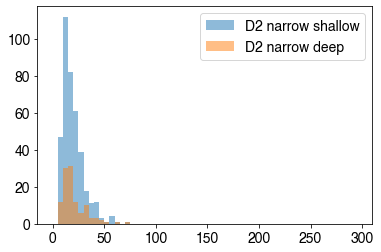

In [83]:
bins = np.arange(0, 300, 5)
plt.hist(Wmask_dict_narrow_shallow_d2['Wlifetime'], bins=bins, alpha=0.5, label='D2 narrow shallow')
plt.hist(Wmask_dict_narrow_deep_d2['Wlifetime'], bins=bins, alpha=0.5, label='D2 narrow deep')
plt.legend()

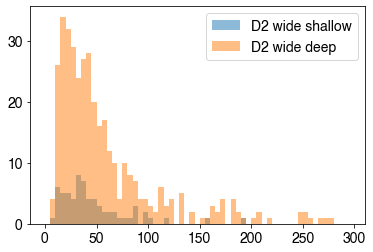

In [84]:
bins = np.arange(0, 300, 5)
plt.hist(Wmask_dict_wide_shallow_d2['Wlifetime'], bins=bins, alpha=0.5, label='D2 wide shallow')
plt.hist(Wmask_dict_wide_deep_d2['Wlifetime'], bins=bins, alpha=0.5, label='D2 wide deep')
plt.legend()

In [85]:
# bins = np.arange(0, 300, 5)
# plt.hist(Wmask_dict_shallow_d3['Wlifetime'], bins=bins, alpha=0.5, label='D2 shallow')
# plt.hist(Wmask_dict_deep_d3['Wlifetime'], bins=bins, alpha=0.5, label='D2 deep')

In [86]:
# bins = np.arange(0, 300, 5)
# plt.hist(Wmask_dict_shallow_d4['Wlifetime'], bins=bins, alpha=0.5, label='D2 shallow')
# plt.hist(Wmask_dict_deep_d4['Wlifetime'], bins=bins, alpha=0.5, label='D2 deep')

## Subset tracks based on W statistics

In [87]:
# Find track indices where updraft objects exist (Wmask lifetime > 0)
Wid_narrow_shallow_d2 = (Wmask_dict_narrow_shallow_d2['Wlifetime'] > 0)
Wid_narrow_deep_d2 = (Wmask_dict_narrow_deep_d2['Wlifetime'] > 0)

# Subset shallow/deep DataSets using the track indices
ds_narrow_shallow_d2sub = ds_narrow_shallow_d2.sel(tracks=Wid_narrow_shallow_d2)
ds_narrow_deep_d2sub = ds_narrow_deep_d2.sel(tracks=Wid_narrow_deep_d2)

ntracks_narrow_shallow_d2sub = ds_narrow_shallow_d2sub.sizes['tracks']
print(f'D2 number of narrow-shallow tracks: {ntracks_narrow_shallow_d2sub}')
print(f'Narrow-deep tracks will be further filtered below.')

# Subset these variables as they are already loaded in memory
CoreMaxW_up_narrow_shallow_d2sub = CoreMaxW_up_narrow_shallow_d2.isel(tracks=Wid_narrow_shallow_d2)
CoreArea_up_narrow_shallow_d2sub = CoreArea_up_narrow_shallow_d2.isel(tracks=Wid_narrow_shallow_d2)
maxETH_10dbz_narrow_shallow_d2sub = maxETH_10dbz_narrow_shallow_d2.isel(tracks=Wid_narrow_shallow_d2)

# Subset these variables as they are already loaded in memory
CoreMaxW_up_narrow_deep_d2sub = CoreMaxW_up_narrow_deep_d2.isel(tracks=Wid_narrow_deep_d2)
CoreArea_up_narrow_deep_d2sub = CoreArea_up_narrow_deep_d2.isel(tracks=Wid_narrow_deep_d2)
maxETH_10dbz_narrow_deep_d2sub = maxETH_10dbz_narrow_deep_d2.isel(tracks=Wid_narrow_deep_d2)

# Subset tracks for the W mask dictionary
Wmask_dict_narrow_shallow_d2sub = {}
Wmask_dict_narrow_deep_d2sub = {}
for key, var in Wmask_dict_narrow_shallow_d2.items():
    Wmask_dict_narrow_shallow_d2sub[key] = Wmask_dict_narrow_shallow_d2[key].isel(tracks=Wid_narrow_shallow_d2)
for key, var in Wmask_dict_narrow_deep_d2.items():
    Wmask_dict_narrow_deep_d2sub[key] = Wmask_dict_narrow_deep_d2[key].isel(tracks=Wid_narrow_deep_d2)

D2 number of narrow-shallow tracks: 392
Narrow-deep tracks will be further filtered below.


In [88]:
# Find track indices where updraft objects exist (Wmask lifetime > 0)
Wid_wide_shallow_d2 = (Wmask_dict_wide_shallow_d2['Wlifetime'] > 0)
Wid_wide_deep_d2 = (Wmask_dict_wide_deep_d2['Wlifetime'] > 0)

# Subset shallow/deep DataSets using the track indices
ds_wide_shallow_d2sub = ds_wide_shallow_d2.sel(tracks=Wid_wide_shallow_d2)
ds_wide_deep_d2sub = ds_wide_deep_d2.sel(tracks=Wid_wide_deep_d2)

ntracks_wide_shallow_d2sub = ds_wide_shallow_d2sub.sizes['tracks']
print(f'D2 number of wide-shallow tracks: {ntracks_wide_shallow_d2sub}')
print(f'wide-deep tracks will be further filtered below.')

# Subset these variables as they are already loaded in memory
CoreMaxW_up_wide_shallow_d2sub = CoreMaxW_up_wide_shallow_d2.isel(tracks=Wid_wide_shallow_d2)
CoreArea_up_wide_shallow_d2sub = CoreArea_up_wide_shallow_d2.isel(tracks=Wid_wide_shallow_d2)
maxETH_10dbz_wide_shallow_d2sub = maxETH_10dbz_wide_shallow_d2.isel(tracks=Wid_wide_shallow_d2)

# Subset these variables as they are already loaded in memory
CoreMaxW_up_wide_deep_d2sub = CoreMaxW_up_wide_deep_d2.isel(tracks=Wid_wide_deep_d2)
CoreArea_up_wide_deep_d2sub = CoreArea_up_wide_deep_d2.isel(tracks=Wid_wide_deep_d2)
maxETH_10dbz_wide_deep_d2sub = maxETH_10dbz_wide_deep_d2.isel(tracks=Wid_wide_deep_d2)

# Subset tracks for the W mask dictionary
Wmask_dict_wide_shallow_d2sub = {}
Wmask_dict_wide_deep_d2sub = {}
for key, var in Wmask_dict_wide_shallow_d2.items():
    Wmask_dict_wide_shallow_d2sub[key] = Wmask_dict_wide_shallow_d2[key].isel(tracks=Wid_wide_shallow_d2)
for key, var in Wmask_dict_wide_deep_d2.items():
    Wmask_dict_wide_deep_d2sub[key] = Wmask_dict_wide_deep_d2[key].isel(tracks=Wid_wide_deep_d2)

D2 number of wide-shallow tracks: 65
wide-deep tracks will be further filtered below.


In [89]:
# # Find track indices where updraft objects exist (Wmask lifetime > 0)
# Wid_shallow_d2 = (Wmask_dict_shallow_d2['Wlifetime'] > 0)
# Wid_deep_d2 = (Wmask_dict_deep_d2['Wlifetime'] > 0)

# # Subset shallow/deep DataSets using the track indices
# dss_shallow_d2sub = dss_shallow_d2.sel(tracks=Wid_shallow_d2)
# dss_deep_d2sub = dss_deep_d2.sel(tracks=Wid_deep_d2)

# ntracks_shallow_d2sub = dss_shallow_d2sub.sizes['tracks']
# print(f'D2 number of shallow tracks: {ntracks_shallow_d2sub}')
# print(f'Deep tracks will be further filtered below.')

# # Subset these variables as they are already loaded in memory
# CoreMaxW_up_shallow_d2sub = CoreMaxW_up_shallow_d2.isel(tracks=Wid_shallow_d2)
# CoreArea_up_shallow_d2sub = CoreArea_up_shallow_d2.isel(tracks=Wid_shallow_d2)
# maxETH_10dbz_shallow_d2sub = maxETH_10dbz_shallow_d2.isel(tracks=Wid_shallow_d2)

# CoreMaxW_up_deep_d2sub = CoreMaxW_up_deep_d2.isel(tracks=Wid_deep_d2)
# CoreArea_up_deep_d2sub = CoreArea_up_deep_d2.isel(tracks=Wid_deep_d2)
# maxETH_10dbz_deep_d2sub = maxETH_10dbz_deep_d2.isel(tracks=Wid_deep_d2)

# # Subset tracks for the W mask dictionary
# Wmask_dict_shallow_d2sub = {}
# Wmask_dict_deep_d2sub = {}
# for key, var in Wmask_dict_shallow_d2.items():
#     Wmask_dict_shallow_d2sub[key] = Wmask_dict_shallow_d2[key].isel(tracks=Wid_shallow_d2)
#     Wmask_dict_deep_d2sub[key] = Wmask_dict_deep_d2[key].isel(tracks=Wid_deep_d2)

In [90]:
# # Find track indices where updraft objects exist (Wmask lifetime > 0)
# Wid_shallow_d3 = (Wmask_dict_shallow_d3['Wlifetime'] > 0)
# Wid_deep_d3 = (Wmask_dict_deep_d3['Wlifetime'] > 0)

# # Subset shallow/deep DataSets using the track indices
# dss_shallow_d3sub = dss_shallow_d3.sel(tracks=Wid_shallow_d3)
# dss_deep_d3sub = dss_deep_d3.sel(tracks=Wid_deep_d3)

# ntracks_shallow_d3sub = dss_shallow_d3sub.sizes['tracks']
# print(f'D3 number of shallow tracks: {ntracks_shallow_d3sub}')
# print(f'Deep tracks will be further filtered below.')

# # Subset these variables as they are already loaded in memory
# CoreMaxW_up_shallow_d3sub = CoreMaxW_up_shallow_d3.isel(tracks=Wid_shallow_d3)
# CoreArea_up_shallow_d3sub = CoreArea_up_shallow_d3.isel(tracks=Wid_shallow_d3)
# maxETH_10dbz_shallow_d3sub = maxETH_10dbz_shallow_d3.isel(tracks=Wid_shallow_d3)

# CoreMaxW_up_deep_d3sub = CoreMaxW_up_deep_d3.isel(tracks=Wid_deep_d3)
# CoreArea_up_deep_d3sub = CoreArea_up_deep_d3.isel(tracks=Wid_deep_d3)
# maxETH_10dbz_deep_d3sub = maxETH_10dbz_deep_d3.isel(tracks=Wid_deep_d3)

# # Subset tracks for the W mask dictionary
# Wmask_dict_shallow_d3sub = {}
# Wmask_dict_deep_d3sub = {}
# for key, var in Wmask_dict_shallow_d3.items():
#     Wmask_dict_shallow_d3sub[key] = Wmask_dict_shallow_d3[key].isel(tracks=Wid_shallow_d3)
#     Wmask_dict_deep_d3sub[key] = Wmask_dict_deep_d3[key].isel(tracks=Wid_deep_d3)

In [91]:
# # Find track indices where updraft objects exist (Wmask lifetime > 0)
# Wid_shallow_d4 = (Wmask_dict_shallow_d4['Wlifetime'] > 0)
# Wid_deep_d4 = (Wmask_dict_deep_d4['Wlifetime'] > 0)

# # Subset shallow/deep DataSets using the track indices
# dss_shallow_d4sub = dss_shallow_d4.sel(tracks=Wid_shallow_d4)
# dss_deep_d4sub = dss_deep_d4.sel(tracks=Wid_deep_d4)

# ntracks_shallow_d4sub = dss_shallow_d4sub.sizes['tracks']
# print(f'D4 number of shallow tracks: {ntracks_shallow_d4sub}')
# print(f'Deep tracks will be further filtered below.')

# # Subset these variables as they are already loaded in memory
# CoreMaxW_up_shallow_d4sub = CoreMaxW_up_shallow_d4.isel(tracks=Wid_shallow_d4)
# CoreArea_up_shallow_d4sub = CoreArea_up_shallow_d4.isel(tracks=Wid_shallow_d4)
# maxETH_10dbz_shallow_d4sub = maxETH_10dbz_shallow_d4.isel(tracks=Wid_shallow_d4)

# CoreMaxW_up_deep_d4sub = CoreMaxW_up_deep_d4.isel(tracks=Wid_deep_d4)
# CoreArea_up_deep_d4sub = CoreArea_up_deep_d4.isel(tracks=Wid_deep_d4)
# maxETH_10dbz_deep_d4sub = maxETH_10dbz_deep_d4.isel(tracks=Wid_deep_d4)

# # Subset tracks for the W mask dictionary
# Wmask_dict_shallow_d4sub = {}
# Wmask_dict_deep_d4sub = {}
# for key, var in Wmask_dict_shallow_d4.items():
#     Wmask_dict_shallow_d4sub[key] = Wmask_dict_shallow_d4[key].isel(tracks=Wid_shallow_d4)
#     Wmask_dict_deep_d4sub[key] = Wmask_dict_deep_d4[key].isel(tracks=Wid_deep_d4)

## Sebset preCI environmental variables to match subset tracks

In [92]:
# Convert HAMSL to AGL, then select a representative time before CI
LCL_mu_narrow_shallow_d2sub = (ds_narrow_shallow_d2sub['LCL_height_mu'] + ds_narrow_shallow_d2sub['Z_surface']).sel(times=time_env) / 1000.
LCL_mu_narrow_deep_d2sub = (ds_narrow_deep_d2sub['LCL_height_mu'] + ds_narrow_deep_d2sub['Z_surface']).sel(times=time_env) / 1000.
LFC_mu_narrow_shallow_d2sub = (ds_narrow_shallow_d2sub['LFC_height_mu'] + ds_narrow_shallow_d2sub['Z_surface']).sel(times=time_env) / 1000.
LFC_mu_narrow_deep_d2sub = (ds_narrow_deep_d2sub['LFC_height_mu'] + ds_narrow_deep_d2sub['Z_surface']).sel(times=time_env) / 1000.

LCL_mu_wide_shallow_d2sub = (ds_wide_shallow_d2sub['LCL_height_mu'] + ds_wide_shallow_d2sub['Z_surface']).sel(times=time_env) / 1000.
LCL_mu_wide_deep_d2sub = (ds_wide_deep_d2sub['LCL_height_mu'] + ds_wide_deep_d2sub['Z_surface']).sel(times=time_env) / 1000.
LFC_mu_wide_shallow_d2sub = (ds_wide_shallow_d2sub['LFC_height_mu'] + ds_wide_shallow_d2sub['Z_surface']).sel(times=time_env) / 1000.
LFC_mu_wide_deep_d2sub = (ds_wide_deep_d2sub['LFC_height_mu'] + ds_wide_deep_d2sub['Z_surface']).sel(times=time_env) / 1000.

In [93]:
# # Time for representative environment [time indices]
# time_env = -3

# # Convert HAMSL to AGL, then select a representative time before CI
# LCL_mu_shallow_d2sub = (dss_shallow_d2sub['LCL_height_mu'] + dss_shallow_d2sub['Z_surface']).sel(times=time_env) / 1000.
# LCL_mu_deep_d2sub = (dss_deep_d2sub['LCL_height_mu'] + dss_deep_d2sub['Z_surface']).sel(times=time_env) / 1000.
# LFC_mu_shallow_d2sub = (dss_shallow_d2sub['LFC_height_mu'] + dss_shallow_d2sub['Z_surface']).sel(times=time_env) / 1000.
# LFC_mu_deep_d2sub = (dss_deep_d2sub['LFC_height_mu'] + dss_deep_d2sub['Z_surface']).sel(times=time_env) / 1000.

In [94]:
# # Convert HAMSL to AGL, then select a representative time before CI
# LCL_mu_shallow_d3sub = (dss_shallow_d3sub['LCL_height_mu'] + dss_shallow_d3sub['Z_surface']).sel(times=time_env) / 1000.
# LCL_mu_deep_d3sub = (dss_deep_d3sub['LCL_height_mu'] + dss_deep_d3sub['Z_surface']).sel(times=time_env) / 1000.
# LFC_mu_shallow_d3sub = (dss_shallow_d3sub['LFC_height_mu'] + dss_shallow_d3sub['Z_surface']).sel(times=time_env) / 1000.
# LFC_mu_deep_d3sub = (dss_deep_d3sub['LFC_height_mu'] + dss_deep_d3sub['Z_surface']).sel(times=time_env) / 1000.

In [95]:
# # Convert HAMSL to AGL, then select a representative time before CI
# LCL_mu_shallow_d4sub = (dss_shallow_d4sub['LCL_height_mu'] + dss_shallow_d4sub['Z_surface']).sel(times=time_env) / 1000.
# LCL_mu_deep_d4sub = (dss_deep_d4sub['LCL_height_mu'] + dss_deep_d4sub['Z_surface']).sel(times=time_env) / 1000.
# LFC_mu_shallow_d4sub = (dss_shallow_d4sub['LFC_height_mu'] + dss_shallow_d4sub['Z_surface']).sel(times=time_env) / 1000.
# LFC_mu_deep_d4sub = (dss_deep_d4sub['LFC_height_mu'] + dss_deep_d4sub['Z_surface']).sel(times=time_env) / 1000.

## Function to fit a linear line for cloud-top height within a time period

In [96]:
def fit_linear(xtime, Wtop, tidx_end, min_nsample=3):
    """
    Perform linear fit to a 1D time series array
    
    Args:
        xtime: np.array
            Array containing time values
        Wtop: np.array
            Array containing values to be fitted
        tidx_end: int
            Max time index to subset the time series before fitting
        min_nsample: int
            Minimum number of valid samples for fitting
            
    Returns:
        out_dict: dictionary
            A dictionary containing W object property variables.    
    """
    # Set default values
    slope, intercept, r_value, p_value, std_err = np.NaN, np.NaN, np.NaN, np.NaN, np.NaN
    nt = len(xtime)
    predicted_x = np.full(nt, np.NaN, dtype=np.float32)
    predicted_y = np.full(nt, np.NaN, dtype=np.float32)
    
    # Find time index for max Wtop within the subet time period
    _Wtop_max_tidx = Wtop[0:tidx_end+1].argmax().item()

    # Subset times to Wtop max
    _xtime = xtime.data[0:_Wtop_max_tidx+1]
    _Wtop = Wtop.data[0:_Wtop_max_tidx+1]
    
    # Find valid value time indices
    tidx_valid = _Wtop > 0
    n_valid = np.count_nonzero(tidx_valid)
    # print(n_valid)
    if (n_valid >= min_nsample):
        _xtime = _xtime[tidx_valid]
        _Wtop = _Wtop[tidx_valid]

        # Perform linear regression
        slope, intercept, r_value, p_value, std_err = linregress(_xtime, _Wtop)
        
        # Find indices matching the subsetted time to the full time
        t_idx = np.where(np.isin(xtime, _xtime))[0]
        # Save the valid subsetted time
        predicted_x[t_idx] = _xtime
        # Predict y values using the linear fit
        predicted_y[t_idx] = slope * _xtime + intercept
        
    # Put output values in a dictionary
    out_dict = {
        'slope': slope,
        'intercept': intercept,
        'r_value': r_value,
        'p_value': p_value,
        'std_err': std_err,
        'predicted_x': predicted_x,
        'predicted_y': predicted_y,
    }
    return out_dict

## Calculate linear fit for updraft-top height

In [97]:
# Minimum number of sample to fit updraft top height
# min_nsample_fit = 3
min_nsample_fit = 2

In [98]:
# _Wtop = Wmask_dict_narrow_deep_d2sub['Wtop'].isel(tracks=25)
# fit_dict = fit_linear(xtime, _Wtop, tidx_end, min_nsample=min_nsample_fit)
# fit_dict

In [99]:
# Make arrays to store data (narrow cells)
ntracks_narrow_deep_d2sub = Wmask_dict_narrow_deep_d2sub['Wtop'].sizes['tracks']
Wtop_slope_narrow_deep_d2sub = np.full(ntracks_narrow_deep_d2sub, np.NaN, dtype=np.float32)
Wtop_fit_narrow_deep_d2sub = np.full((ntracks_narrow_deep_d2sub, ntimes), np.NaN, dtype=np.float32)

# Loop over each track (narrow cells)
for itrack in range(ntracks_narrow_deep_d2sub):
    _Wtop = Wmask_dict_narrow_deep_d2sub['Wtop'].isel(tracks=itrack)
    fit_dict = fit_linear(xtime, _Wtop, tidx_end, min_nsample=min_nsample_fit)
    Wtop_slope_narrow_deep_d2sub[itrack] = fit_dict['slope']
    Wtop_fit_narrow_deep_d2sub[itrack,:] = fit_dict['predicted_y']

# Make arrays to store data (wide cells)
ntracks_wide_deep_d2sub = Wmask_dict_wide_deep_d2sub['Wtop'].sizes['tracks']
Wtop_slope_wide_deep_d2sub = np.full(ntracks_wide_deep_d2sub, np.NaN, dtype=np.float32)
Wtop_fit_wide_deep_d2sub = np.full((ntracks_wide_deep_d2sub, ntimes), np.NaN, dtype=np.float32)

# Loop over each track (wide cells)
for itrack in range(ntracks_wide_deep_d2sub):
    _Wtop = Wmask_dict_wide_deep_d2sub['Wtop'].isel(tracks=itrack)
    fit_dict = fit_linear(xtime, _Wtop, tidx_end, min_nsample=min_nsample_fit)
    Wtop_slope_wide_deep_d2sub[itrack] = fit_dict['slope']
    Wtop_fit_wide_deep_d2sub[itrack,:] = fit_dict['predicted_y']

In [101]:
Wtop_fit_wide_deep_d2sub.shape

(376, 212)

In [103]:
Wmask_dict_wide_deep_d2sub.keys()

dict_keys(['Wmask', 'Wmask_plt', 'Wtop', 'Wbase', 'Wtime_start', 'Wtime_end', 'Wlifetime'])

In [104]:
Wmask_dict_wide_deep_d2sub['Wmask'].shape

(376, 212, 40)

In [196]:
# # Make arrays to store data
# ntracks_deep_d2sub = Wmask_dict_deep_d2sub['Wtop'].sizes['tracks']
# Wtop_slope_deep_d2sub = np.full(ntracks_deep_d2sub, np.NaN, dtype=np.float32)
# Wtop_fit_deep_d2sub = np.full((ntracks_deep_d2sub, ntimes), np.NaN, dtype=np.float32)

# # Loop over each track
# for itrack in range(ntracks_deep_d2sub):
#     _Wtop = Wmask_dict_deep_d2sub['Wtop'].isel(tracks=itrack)
#     fit_dict = fit_linear(xtime, _Wtop, tidx_end, min_nsample=min_nsample_fit)
#     Wtop_slope_deep_d2sub[itrack] = fit_dict['slope']
#     Wtop_fit_deep_d2sub[itrack,:] = fit_dict['predicted_y']

In [197]:
# # Make arrays to store data
# ntracks_deep_d3sub = Wmask_dict_deep_d3sub['Wtop'].sizes['tracks']
# Wtop_slope_deep_d3sub = np.full(ntracks_deep_d3sub, np.NaN, dtype=np.float32)
# Wtop_fit_deep_d3sub = np.full((ntracks_deep_d3sub, ntimes), np.NaN, dtype=np.float32)

# # Loop over each track
# for itrack in range(ntracks_deep_d3sub):
#     _Wtop = Wmask_dict_deep_d3sub['Wtop'].isel(tracks=itrack)
#     fit_dict = fit_linear(xtime, _Wtop, tidx_end, min_nsample=min_nsample_fit)
#     Wtop_slope_deep_d3sub[itrack] = fit_dict['slope']
#     Wtop_fit_deep_d3sub[itrack,:] = fit_dict['predicted_y']

In [198]:
# # Make arrays to store data
# ntracks_deep_d4sub = Wmask_dict_deep_d4sub['Wtop'].sizes['tracks']
# Wtop_slope_deep_d4sub = np.full(ntracks_deep_d4sub, np.NaN, dtype=np.float32)
# Wtop_fit_deep_d4sub = np.full((ntracks_deep_d4sub, ntimes), np.NaN, dtype=np.float32)

# # Loop over each track
# for itrack in range(ntracks_deep_d4sub):
#     _Wtop = Wmask_dict_deep_d4sub['Wtop'].isel(tracks=itrack)
#     fit_dict = fit_linear(xtime, _Wtop, tidx_end, min_nsample=min_nsample_fit)
#     Wtop_slope_deep_d4sub[itrack] = fit_dict['slope']
#     Wtop_fit_deep_d4sub[itrack,:] = fit_dict['predicted_y']

In [199]:
# itrack = 241
# _Wtop = Wmask_dict_deep_d2sub['Wtop'].isel(tracks=itrack)
# _Wtop_max_tidx = _Wtop[0:tidx_end+1].argmax().item()
# xtime.data[_Wtop_max_tidx]
# plt.plot(xtime, _Wtop)
# plt.plot(xtime, Wtop_fit_deep_d2sub[itrack,:], ls='--')

In [200]:
# print(_Wtop)

## Find deep cell tracks with positive updraft top slope, and updraft base close to LCL
## These are the tracks to keep in the analysis

In [201]:
Wmask_dict_narrow_deep_d2sub['Wbase'].shape, LCL_mu_narrow_deep_d2sub.shape, Wtop_slope_narrow_deep_d2sub.shape, ntracks_narrow_deep_d2sub

((112, 212), (112,), (112,), 112)

In [202]:
# Threshold for max distance between updraft base and LCL height [km]
max_Wbase_LCL_dist = 2.0
# Threshold for updraft top fit line slope
min_Wtop_slope = 0

In [203]:
# Calculate distance between minimum updraft base height and MU LCL height (HAMSL)
Wbase_LCL_diff_d2sub = np.absolute(Wmask_dict_narrow_deep_d2sub['Wbase'].min(dim='times') - LCL_mu_narrow_deep_d2sub)

# True/False flag for positive slope
Wtop_Pslope_narrow_deep_d2sub = Wtop_slope_narrow_deep_d2sub > min_Wtop_slope
# True/False flag for updraft base height from LCL
Wbase_LCL_narrow_deep_d2sub = Wbase_LCL_diff_d2sub <= max_Wbase_LCL_dist
# Both positive slope & updraft base flag
Wkeep_flag_narrow_deep_d2sub = (Wtop_Pslope_narrow_deep_d2sub & Wbase_LCL_narrow_deep_d2sub).compute()
# Track indicies to keep
Wid_keep_narrow_deep_d2sub = np.where(Wkeep_flag_narrow_deep_d2sub)[0]

ntracksW_narrow_deep_d2 = len(Wid_keep_narrow_deep_d2sub)
ntracksW_narrow_shallow_d2 = len(Wid_narrow_shallow_d2)
print(f'D2 number of narrow-deep tracks to keep: {ntracksW_narrow_deep_d2}, fraction to all narrow-deep tracks: {100*(ntracksW_narrow_deep_d2 / ntracks_narrow_deep_d2sub):.1f}%')
print(f'D2 number of narrow-shallow tracks to keep: {ntracksW_narrow_shallow_d2}')

D2 number of narrow-deep tracks to keep: 46, fraction to all narrow-deep tracks: 41.1%
D2 number of narrow-shallow tracks to keep: 454


In [204]:
# Calculate distance between minimum updraft base height and MU LCL height (HAMSL)
Wbase_LCL_diff_d2sub = np.absolute(Wmask_dict_wide_deep_d2sub['Wbase'].min(dim='times') - LCL_mu_wide_deep_d2sub)

# True/False flag for positive slope
Wtop_Pslope_wide_deep_d2sub = Wtop_slope_wide_deep_d2sub > min_Wtop_slope
# True/False flag for updraft base height from LCL
Wbase_LCL_wide_deep_d2sub = Wbase_LCL_diff_d2sub <= max_Wbase_LCL_dist
# Both positive slope & updraft base flag
Wkeep_flag_wide_deep_d2sub = (Wtop_Pslope_wide_deep_d2sub & Wbase_LCL_wide_deep_d2sub).compute()
# Track indicies to keep
Wid_keep_wide_deep_d2sub = np.where(Wkeep_flag_wide_deep_d2sub)[0]

ntracksW_wide_deep_d2 = len(Wid_keep_wide_deep_d2sub)
ntracksW_wide_shallow_d2 = len(Wid_wide_shallow_d2)
print(f'D2 number of wide-deep tracks to keep: {ntracksW_wide_deep_d2}, fraction to all wide-deep tracks: {100*(ntracksW_wide_deep_d2 / ntracks_wide_deep_d2sub):.1f}%')
print(f'D2 number of wide-shallow tracks to keep: {ntracksW_wide_shallow_d2}')

D2 number of wide-deep tracks to keep: 267, fraction to all wide-deep tracks: 71.0%
D2 number of wide-shallow tracks to keep: 67


In [205]:
# # Calculate distance between minimum updraft base height and MU LCL height (HAMSL)
# Wbase_LCL_diff_d2sub = np.absolute(Wmask_dict_deep_d2sub['Wbase'].min(dim='times') - LCL_mu_deep_d2sub)

# # # TODO: potentially could also use updraft top height and ETH difference as further constrain
# # # But need to constrain periods for the updraft top rather than over the entire cell duration
# # Wtop_ETH_diff_d2sub = np.absolute(Wmask_dict_deep_d2sub['Wtop'] - maxETH_10dbz_deep_d2sub)

# # True/False flag for positive slope
# Wtop_Pslope_deep_d2sub = Wtop_slope_deep_d2sub > min_Wtop_slope
# # True/False flag for updraft base height from LCL
# Wbase_LCL_deep_d2sub = Wbase_LCL_diff_d2sub <= max_Wbase_LCL_dist
# # Both positive slope & updraft base flag
# Wkeep_flag_d2sub = (Wtop_Pslope_deep_d2sub & Wbase_LCL_deep_d2sub).compute()
# # Track indicies to keep
# # Wid_keep_deep_d2sub = np.where(Wtop_Pslope_deep_d2sub)[0]
# Wid_keep_deep_d2sub = np.where(Wkeep_flag_d2sub)[0]

# ntracksW_deep_d2 = len(Wid_keep_deep_d2sub)
# ntracksW_shallow_d2 = len(Wid_shallow_d2)
# print(f'D2 number of deep tracks to keep: {ntracksW_deep_d2}, fraction to all deep tracks: {100*(ntracksW_deep_d2 / ntracks_deep_d2sub):.1f}%')
# print(f'D2 number of shallow tracks to keep: {ntracksW_shallow_d2}')

In [206]:
# # Calculate distance between minimum updraft base height and MU LCL height (HAMSL)
# Wbase_LCL_diff_d3sub = np.absolute(Wmask_dict_deep_d3sub['Wbase'].min(dim='times') - LCL_mu_deep_d3sub)

# # # TODO: potentially could also use updraft top height and ETH difference as further constrain
# # # But need to constrain periods for the updraft top rather than over the entire cell duration
# # Wtop_ETH_diff_d3sub = np.absolute(Wmask_dict_deep_d3sub['Wtop'] - maxETH_10dbz_deep_d3sub)

# # True/False flag for positive slope
# Wtop_Pslope_deep_d3sub = Wtop_slope_deep_d3sub > min_Wtop_slope
# # True/False flag for updraft base height from LCL
# Wbase_LCL_deep_d3sub = Wbase_LCL_diff_d3sub <= max_Wbase_LCL_dist
# # Both positive slope & updraft base flag
# Wkeep_flag_d3sub = (Wtop_Pslope_deep_d3sub & Wbase_LCL_deep_d3sub).compute()
# # Track indicies to keep
# # Wid_keep_deep_d3sub = np.where(Wtop_Pslope_deep_d3sub)[0]
# Wid_keep_deep_d3sub = np.where(Wkeep_flag_d3sub)[0]

# ntracksW_deep_d3 = len(Wid_keep_deep_d3sub)
# ntracksW_shallow_d3 = len(Wid_shallow_d3)
# print(f'D3 number of deep tracks to keep: {ntracksW_deep_d3}, fraction to all deep tracks: {100*(ntracksW_deep_d3 / ntracks_deep_d3sub):.1f}%')
# print(f'D3 number of shallow tracks to keep: {ntracksW_shallow_d3}')

In [207]:
# # Calculate distance between minimum updraft base height and MU LCL height (HAMSL)
# Wbase_LCL_diff_d4sub = np.absolute(Wmask_dict_deep_d4sub['Wbase'].min(dim='times') - LCL_mu_deep_d4sub)

# # # TODO: potentially could also use updraft top height and ETH difference as further constrain
# # # But need to constrain periods for the updraft top rather than over the entire cell duration
# # Wtop_ETH_diff_d4sub = np.absolute(Wmask_dict_deep_d4sub['Wtop'] - maxETH_10dbz_deep_d4sub)

# # True/False flag for positive slope
# Wtop_Pslope_deep_d4sub = Wtop_slope_deep_d4sub > min_Wtop_slope
# # True/False flag for updraft base height from LCL
# Wbase_LCL_deep_d4sub = Wbase_LCL_diff_d4sub <= max_Wbase_LCL_dist
# # Both positive slope & updraft base flag
# Wkeep_flag_d4sub = (Wtop_Pslope_deep_d4sub & Wbase_LCL_deep_d4sub).compute()
# # Track indicies to keep
# # Wid_keep_deep_d4sub = np.where(Wtop_Pslope_deep_d4sub)[0]
# Wid_keep_deep_d4sub = np.where(Wkeep_flag_d4sub)[0]

# ntracksW_deep_d4 = len(Wid_keep_deep_d4sub)
# ntracksW_shallow_d4 = len(Wid_shallow_d4)
# print(f'D4 number of deep tracks to keep: {ntracksW_deep_d4}, fraction to all deep tracks: {100*(ntracksW_deep_d4 / ntracks_deep_d4sub):.1f}%')
# print(f'D4 number of shallow tracks to keep: {ntracksW_shallow_d4}')

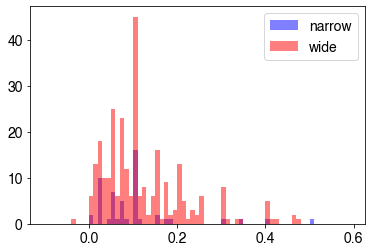

In [208]:
plt.hist(Wtop_slope_narrow_deep_d2sub, bins=np.arange(-0.1,0.6,0.01), color='b', label='narrow', alpha=0.5)
plt.hist(Wtop_slope_wide_deep_d2sub, bins=np.arange(-0.1,0.6,0.01), color='r', label='wide', alpha=0.5)
plt.legend()

## Function to plot individual tracks of updrafts

In [209]:
def plot_tz_sample(xtime, height, da, da_mask, maxETH, cldTop, Wtime_startend, env_dict,
                   cldTop_fit=None, cldBase=None, keep_flag=None,
                   xlim=None, ylim=None, xlabel=None, ylabel=None, title=None, legend=None,
                   cmap=None, cblabels=None, fontsize=None, figsize=None, figname=None):
    
    mpl.rcParams['font.size'] = fontsize
    # mpl.rcParams['font.family'] = 'Helvetica'
    mpl.rcParams['font.family'] = 'DejaVu Sans'
    mpl.rcParams['figure.facecolor'] = 'white'

    fig = plt.figure(figsize=figsize, dpi=100)
    nrows = 1
    gs = gridspec.GridSpec(nrows, 2, height_ratios=np.repeat(1, nrows).tolist(), width_ratios=[1,0.04])
    gs.update(left=0.05, right=0.9, bottom=0.05, top=0.95, wspace=0.1, hspace=0.15)
    ax = plt.subplot(gs[0,0])
    cax = plt.subplot(gs[0,1])
    
    colors = {'ETH':'red', 'cldTop':'b', 'cldBase':'dodgerblue', 'LCL':'violet', 'LFC':'mediumorchid'}
    
    # Plot data
    pcm_da = ax.pcolormesh(xtime, height, da, shading='nearest', cmap=cmap)
    # Plot mask
    pcm_ma = ax.pcolormesh(xtime, height, da_mask, vmin=0., vmax=1, cmap='gray', alpha=0.8)
    # 
    ax.axvline(Wtime_startend['s'], lw=1, color='purple')
    ax.axvline(Wtime_startend['e'], lw=1, color='purple')
    ax.axvline(time_end, lw=1, ls=':', color='purple')
    # ETH line
    ETH_line = ax.plot(xtime, maxETH, color=colors['ETH'], label='10dBZ ETH')
    # cloud/updraft top line
    cldTop_line = ax.plot(xtime, cldTop, color=colors['cldTop'], label='Updraft Top')
    if cldBase is not None:
        cldBase_line = ax.plot(xtime, cldBase, color=colors['cldBase'], label='Updraft Base')
    # cloud/updraft top fit line
    if cldTop_fit is not None:
        cldTop_fitline = ax.plot(xtime, cldTop_fit, color=colors['cldTop'], ls='--', label='Updraft Top (Fit)')
    
    LCL = env_dict['LCL']
    LFC = env_dict['LFC']

    line_length = 50
    LCL_t0 = 0
    LCL_t1 = LCL_t0 + line_length
    LFC_t0 = 30
    LFC_t1 = LFC_t0 + line_length
    ax.hlines(y=LCL, xmin=LCL_t0, xmax=LCL_t1, color=colors['LCL'])
    ax.hlines(y=LFC, xmin=LFC_t0, xmax=LFC_t1, color=colors['LFC'], ls='--')
    LCL_text_x = LCL_t0 + line_length / 2
    LCL_text_y = LCL-0.2
    LFC_text_x = LFC_t0 + line_length / 2
    LFC_text_y = LFC-0.2
    ax.text(LCL_text_x, LCL_text_y, 'LCL', ha='center', va='top', color=colors['LCL'], fontsize=fontsize)
    ax.text(LFC_text_x, LFC_text_y, 'LFC', ha='center', va='top', color=colors['LFC'], fontsize=fontsize)
    
    ax.legend(fontsize=fontsize*0.7)
    # Draw an arrow below xaxis
    ax.annotate("", xy=(1, -0.2), xycoords='axes fraction', xytext=(0, -0.2), arrowprops=dict(facecolor='black'))
    # Flag to
    if keep_flag==True:
        track_flag = u'\u2713'
        track_color = 'green'
    else:
        track_flag = u'\u2717'
        track_color = 'red'
    if keep_flag is not None:
        ax.set_title(track_flag, loc='right', color=track_color)
    ax.set_title(title, loc='left')
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    ax.set_xlim(xlim[0], xlim[1])
    ax.set_ylim(ylim[0], ylim[1])
    ax.grid(ls='--')
    # Colorbar
    cb = plt.colorbar(pcm_da, cax=cax, label=cblabels,)
    
    fig.savefig(figname, bbox_inches='tight', dpi=200, facecolor='w')
    return fig

In [210]:
f'{figdir}/updraft_tracks_narrowwide/'

'/gpfs/wolf2/arm/atm131/proj-shared/zfeng/cacti/les/figures//updraft_tracks_narrowwide/'

/gpfs/wolf2/arm/atm131/proj-shared/zfeng/cacti/les/figures//updraft_tracks_narrowwide/CoreMaxW_d2_narrow_deep_0002.png


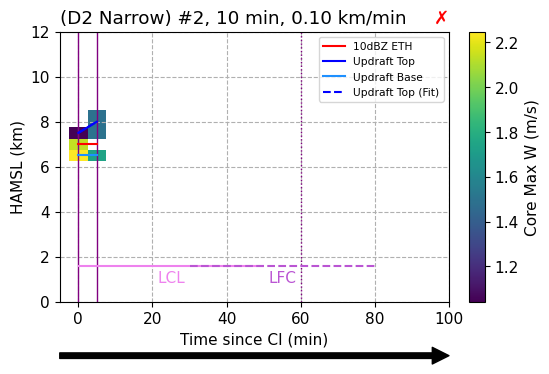

In [211]:
itrack = 2
# itrack = 338

_da = CoreMaxW_up_narrow_deep_d2sub.isel(tracks=itrack).transpose()
_maxETH = maxETH_10dbz_narrow_deep_d2sub.isel(tracks=itrack)
_da_mask = Wmask_dict_narrow_deep_d2sub['Wmask_plt'].isel(tracks=itrack).transpose()
_Wtop = Wmask_dict_narrow_deep_d2sub['Wtop'].isel(tracks=itrack)
_Wbase = Wmask_dict_narrow_deep_d2sub['Wbase'].isel(tracks=itrack)
_t_s = Wmask_dict_narrow_deep_d2sub['Wtime_start'].isel(tracks=itrack)
_t_e = Wmask_dict_narrow_deep_d2sub['Wtime_end'].isel(tracks=itrack)
_Wlifetime = Wmask_dict_narrow_deep_d2sub['Wlifetime'].isel(tracks=itrack)
_Wtime_startend = {'s':_t_s, 'e':_t_e}
_WtopMax = _Wtop.max(dim='times').item()
_env_dict = {'LCL':LCL_mu_narrow_deep_d2sub.isel(tracks=itrack), 'LFC':LFC_mu_narrow_deep_d2sub.isel(tracks=itrack)}
_Wtop_fit = Wtop_fit_narrow_deep_d2sub[itrack]
_Wtop_slope = Wtop_slope_narrow_deep_d2sub[itrack]
_keep_flag = Wkeep_flag_narrow_deep_d2sub[itrack]

xlim = (-5,100)
ylim = (0,12)
# title = f'(D2) #{itrack}, {_Wlifetime:.0f} min, {_WtopMax} km, {_Wtop_slope:}'
title = f'(D2 Narrow) #{itrack}, {_Wlifetime:.0f} min, {_Wtop_slope:.2f} km/min'
xlabel = 'Time since CI (min)'
ylabel = 'HAMSL (km)'
cmap = 'viridis'
cblabels = 'Core Max W (m/s)'
figbasename = 'CoreMaxW'
# cblabels = 'Core Width (km)'
# figbasename = 'CoreWidth'
figdir_sample = f'{figdir}/updraft_tracks_narrowwide/'
os.makedirs(figdir_sample, exist_ok=True)
figname = f'{figdir_sample}{figbasename}_d2_narrow_deep_{itrack:04}.png'
figsize = (5,3)
fontsize = 11

fig = plot_tz_sample(xtime, height, _da, _da_mask, _maxETH, _Wtop, _Wtime_startend, _env_dict,
                     cldTop_fit=_Wtop_fit, cldBase=_Wbase, keep_flag=_keep_flag,
                     xlim=xlim, ylim=ylim, title=title, xlabel=xlabel, ylabel=ylabel,
                     cmap=cmap, cblabels=cblabels, fontsize=fontsize, figsize=figsize, figname=figname)
# plt.close(fig)
print(figname)

In [212]:
# itrack = 32

# _da = CoreMaxW_up_shallow_d2sub.isel(tracks=itrack).transpose()
# _maxETH = maxETH_10dbz_shallow_d2sub.isel(tracks=itrack)
# _da_mask = Wmask_dict_shallow_d2sub['Wmask_plt'].isel(tracks=itrack).transpose()
# _Wtop = Wmask_dict_shallow_d2sub['Wtop'].isel(tracks=itrack)
# _Wbase = Wmask_dict_shallow_d2sub['Wbase'].isel(tracks=itrack)
# _t_s = Wmask_dict_shallow_d2sub['Wtime_start'].isel(tracks=itrack)
# _t_e = Wmask_dict_shallow_d2sub['Wtime_end'].isel(tracks=itrack)
# _Wlifetime = Wmask_dict_shallow_d2sub['Wlifetime'].isel(tracks=itrack)
# _Wtime_startend = {'s':_t_s, 'e':_t_e}
# _WtopMax = _Wtop.max(dim='times').item()
# _env_dict = {'LCL':LCL_mu_shallow_d2sub.isel(tracks=itrack), 'LFC':LFC_mu_shallow_d2sub.isel(tracks=itrack)}

# xlim = (-5,100)
# ylim = (0,12)
# title = f'#{itrack}, {_Wlifetime:.0f} min, {_WtopMax} km'
# xlabel = 'Time since CI (min)'
# ylabel = 'HAMSL (km)'
# cmap = 'viridis'
# cblabels = 'Core Max W (m/s)'
# figbasename = 'CoreMaxW'
# # cblabels = 'Core Width (km)'
# # figbasename = 'CoreWidth'
# figdir_sample = f'{figdir}/updraft_tracks/'
# os.makedirs(figdir_sample, exist_ok=True)

# figname = f'{figdir_sample}{figbasename}_d2_shallow_{itrack:04}.png'
# figsize = (5,3)
# fontsize = 12

# fig = plot_tz_sample(xtime, height, _da, _da_mask, _maxETH, _Wtop, _Wtime_startend, _env_dict,
#                      cldBase=_Wbase,
#                      xlim=xlim, ylim=ylim, title=title, xlabel=xlabel, ylabel=ylabel,
#                      cmap=cmap, cblabels=cblabels, fontsize=fontsize, figsize=figsize, figname=figname)
# # plt.close(fig)
# print(figname)

In [214]:
# figdir_sample

In [217]:
# nsamples2plot = 80
# if (nsamples2plot >= ntracksW_narrow_deep_d2)

nsamples2plot = 100
if (nsamples2plot > ntracksW_narrow_deep_d2): nsamples2plot = ntracksW_narrow_deep_d2

46

In [218]:
# Set a seed for reproducibility
np.random.seed(10)

nsamples2plot = 100
if (nsamples2plot > ntracksW_narrow_deep_d2): nsamples2plot = ntracksW_narrow_deep_d2
tracks_random = np.random.randint(0, CoreMaxW_up_narrow_deep_d2sub.sizes['tracks'], nsamples2plot)
tracks_random

array([  9, 100,  15,  64,  28,  89,  93,  29,   8,  73,   0, 106,  40,
        36,  16, 100, 111,  11,  54,  88, 107,  62,  33,  72, 100,  78,
        49,  51,  54,  77,  69,  13,  25,  13,  92,  86,  30,  30,  89,
        12,  65,  31,  57,  36,  27,  18])

In [219]:
# Generate a random number of tracks
nsamples2plot = 100
if (nsamples2plot > ntracksW_narrow_deep_d2): nsamples2plot = ntracksW_narrow_deep_d2
tracks_random = np.random.randint(0, CoreMaxW_up_narrow_deep_d2sub.sizes['tracks'], nsamples2plot)

# Loop over each track to plot
for itrack in tracks_random:
# for itrack in range(0, 1):
    _da = CoreMaxW_up_narrow_deep_d2sub.isel(tracks=itrack).transpose()
    _maxETH = maxETH_10dbz_narrow_deep_d2sub.isel(tracks=itrack)
    _da_mask = Wmask_dict_narrow_deep_d2sub['Wmask_plt'].isel(tracks=itrack).transpose()
    _Wtop = Wmask_dict_narrow_deep_d2sub['Wtop'].isel(tracks=itrack)
    _Wbase = Wmask_dict_narrow_deep_d2sub['Wbase'].isel(tracks=itrack)
    _t_s = Wmask_dict_narrow_deep_d2sub['Wtime_start'].isel(tracks=itrack)
    _t_e = Wmask_dict_narrow_deep_d2sub['Wtime_end'].isel(tracks=itrack)
    _Wlifetime = Wmask_dict_narrow_deep_d2sub['Wlifetime'].isel(tracks=itrack)
    _Wtime_startend = {'s':_t_s, 'e':_t_e}
    _WtopMax = _Wtop.max(dim='times').item()
    _env_dict = {'LCL':LCL_mu_narrow_deep_d2sub.isel(tracks=itrack), 'LFC':LFC_mu_narrow_deep_d2sub.isel(tracks=itrack)}
    _Wtop_fit = Wtop_fit_narrow_deep_d2sub[itrack]
    _Wtop_slope = Wtop_slope_narrow_deep_d2sub[itrack]
    _keep_flag = Wkeep_flag_narrow_deep_d2sub[itrack]

    xlim = (-5,100)
    ylim = (0,12)
    # title = f'(D2) #{itrack}, {_Wlifetime:.0f} min, {_WtopMax} km'
    title = f'(D2 Narrow) #{itrack}, {_Wlifetime:.0f} min, {_Wtop_slope:.2f} km/min'
    xlabel = 'Time since CI (min)'
    ylabel = 'HAMSL (km)'
    cmap = 'viridis'
    cblabels = 'Core Max W (m/s)'
    figbasename = 'CoreMaxW'
    # cblabels = 'Core Width (km)'
    # figbasename = 'CoreWidth'
    figdir_sample = f'{figdir}/updraft_tracks_narrowwide/'
    figname = f'{figdir_sample}{figbasename}_d2_narrow_deep_{itrack:04}.png'
    figsize = (5,3)
    fontsize = 11
   
    fig = plot_tz_sample(xtime, height, _da, _da_mask, _maxETH, _Wtop, _Wtime_startend, _env_dict,
                     cldTop_fit=_Wtop_fit, cldBase=_Wbase, keep_flag=_keep_flag,
                     xlim=xlim, ylim=ylim, title=title, xlabel=xlabel, ylabel=ylabel,
                     cmap=cmap, cblabels=cblabels, fontsize=fontsize, figsize=figsize, figname=figname)
    
    plt.close(fig)
    print(figname)

/gpfs/wolf2/arm/atm131/proj-shared/zfeng/cacti/les/figures//updraft_tracks_narrowwide/CoreMaxW_d2_narrow_deep_0093.png
/gpfs/wolf2/arm/atm131/proj-shared/zfeng/cacti/les/figures//updraft_tracks_narrowwide/CoreMaxW_d2_narrow_deep_0077.png
/gpfs/wolf2/arm/atm131/proj-shared/zfeng/cacti/les/figures//updraft_tracks_narrowwide/CoreMaxW_d2_narrow_deep_0022.png
/gpfs/wolf2/arm/atm131/proj-shared/zfeng/cacti/les/figures//updraft_tracks_narrowwide/CoreMaxW_d2_narrow_deep_0023.png
/gpfs/wolf2/arm/atm131/proj-shared/zfeng/cacti/les/figures//updraft_tracks_narrowwide/CoreMaxW_d2_narrow_deep_0094.png
/gpfs/wolf2/arm/atm131/proj-shared/zfeng/cacti/les/figures//updraft_tracks_narrowwide/CoreMaxW_d2_narrow_deep_0011.png
/gpfs/wolf2/arm/atm131/proj-shared/zfeng/cacti/les/figures//updraft_tracks_narrowwide/CoreMaxW_d2_narrow_deep_0028.png
/gpfs/wolf2/arm/atm131/proj-shared/zfeng/cacti/les/figures//updraft_tracks_narrowwide/CoreMaxW_d2_narrow_deep_0074.png
/gpfs/wolf2/arm/atm131/proj-shared/zfeng/cacti/l

In [221]:
# Generate a random number of tracks
nsamples2plot = 100
if (nsamples2plot > ntracksW_wide_deep_d2): nsamples2plot = ntracksW_wide_deep_d2
tracks_random = np.random.randint(0, CoreMaxW_up_wide_deep_d2sub.sizes['tracks'], nsamples2plot)

# Loop over each track to plot
for itrack in tracks_random:
# for itrack in range(0, 1):
    _da = CoreMaxW_up_wide_deep_d2sub.isel(tracks=itrack).transpose()
    _maxETH = maxETH_10dbz_wide_deep_d2sub.isel(tracks=itrack)
    _da_mask = Wmask_dict_wide_deep_d2sub['Wmask_plt'].isel(tracks=itrack).transpose()
    _Wtop = Wmask_dict_wide_deep_d2sub['Wtop'].isel(tracks=itrack)
    _Wbase = Wmask_dict_wide_deep_d2sub['Wbase'].isel(tracks=itrack)
    _t_s = Wmask_dict_wide_deep_d2sub['Wtime_start'].isel(tracks=itrack)
    _t_e = Wmask_dict_wide_deep_d2sub['Wtime_end'].isel(tracks=itrack)
    _Wlifetime = Wmask_dict_wide_deep_d2sub['Wlifetime'].isel(tracks=itrack)
    _Wtime_startend = {'s':_t_s, 'e':_t_e}
    _WtopMax = _Wtop.max(dim='times').item()
    _env_dict = {'LCL':LCL_mu_wide_deep_d2sub.isel(tracks=itrack), 'LFC':LFC_mu_wide_deep_d2sub.isel(tracks=itrack)}
    _Wtop_fit = Wtop_fit_wide_deep_d2sub[itrack]
    _Wtop_slope = Wtop_slope_wide_deep_d2sub[itrack]
    _keep_flag = Wkeep_flag_wide_deep_d2sub[itrack]

    xlim = (-5,100)
    ylim = (0,12)
    # title = f'(D2) #{itrack}, {_Wlifetime:.0f} min, {_WtopMax} km'
    title = f'(D2 Wide) #{itrack}, {_Wlifetime:.0f} min, {_Wtop_slope:.2f} km/min'
    xlabel = 'Time since CI (min)'
    ylabel = 'HAMSL (km)'
    cmap = 'viridis'
    cblabels = 'Core Max W (m/s)'
    figbasename = 'CoreMaxW'
    # cblabels = 'Core Width (km)'
    # figbasename = 'CoreWidth'
    figdir_sample = f'{figdir}/updraft_tracks_narrowwide/'
    figname = f'{figdir_sample}{figbasename}_d2_wide_deep_{itrack:04}.png'
    figsize = (5,3)
    fontsize = 11
   
    fig = plot_tz_sample(xtime, height, _da, _da_mask, _maxETH, _Wtop, _Wtime_startend, _env_dict,
                     cldTop_fit=_Wtop_fit, cldBase=_Wbase, keep_flag=_keep_flag,
                     xlim=xlim, ylim=ylim, title=title, xlabel=xlabel, ylabel=ylabel,
                     cmap=cmap, cblabels=cblabels, fontsize=fontsize, figsize=figsize, figname=figname)
    
    plt.close(fig)
    print(figname)

/gpfs/wolf2/arm/atm131/proj-shared/zfeng/cacti/les/figures//updraft_tracks_narrowwide/CoreMaxW_d2_wide_deep_0158.png
/gpfs/wolf2/arm/atm131/proj-shared/zfeng/cacti/les/figures//updraft_tracks_narrowwide/CoreMaxW_d2_wide_deep_0372.png
/gpfs/wolf2/arm/atm131/proj-shared/zfeng/cacti/les/figures//updraft_tracks_narrowwide/CoreMaxW_d2_wide_deep_0330.png
/gpfs/wolf2/arm/atm131/proj-shared/zfeng/cacti/les/figures//updraft_tracks_narrowwide/CoreMaxW_d2_wide_deep_0286.png
/gpfs/wolf2/arm/atm131/proj-shared/zfeng/cacti/les/figures//updraft_tracks_narrowwide/CoreMaxW_d2_wide_deep_0137.png
/gpfs/wolf2/arm/atm131/proj-shared/zfeng/cacti/les/figures//updraft_tracks_narrowwide/CoreMaxW_d2_wide_deep_0258.png
/gpfs/wolf2/arm/atm131/proj-shared/zfeng/cacti/les/figures//updraft_tracks_narrowwide/CoreMaxW_d2_wide_deep_0115.png
/gpfs/wolf2/arm/atm131/proj-shared/zfeng/cacti/les/figures//updraft_tracks_narrowwide/CoreMaxW_d2_wide_deep_0141.png
/gpfs/wolf2/arm/atm131/proj-shared/zfeng/cacti/les/figures//updr

In [110]:
# # Generate a random number of tracks
# tracks_random = np.random.randint(0, CoreMaxW_up_shallow_d2sub.sizes['tracks'], nsamples2plot)

# # Loop over each track to plot
# for itrack in tracks_random:
#     _da = CoreMaxW_up_shallow_d2sub.isel(tracks=itrack).transpose()
#     _maxETH = maxETH_10dbz_shallow_d2sub.isel(tracks=itrack)
#     _da_mask = Wmask_dict_shallow_d2sub['Wmask_plt'].isel(tracks=itrack).transpose()
#     _Wtop = Wmask_dict_shallow_d2sub['Wtop'].isel(tracks=itrack)
#     _Wbase = Wmask_dict_shallow_d2sub['Wbase'].isel(tracks=itrack)
#     _t_s = Wmask_dict_shallow_d2sub['Wtime_start'].isel(tracks=itrack)
#     _t_e = Wmask_dict_shallow_d2sub['Wtime_end'].isel(tracks=itrack)
#     _Wlifetime = Wmask_dict_shallow_d2sub['Wlifetime'].isel(tracks=itrack)
#     _Wtime_startend = {'s':_t_s, 'e':_t_e}
#     _WtopMax = _Wtop.max(dim='times').item()
#     _env_dict = {'LCL':LCL_mu_shallow_d2sub.isel(tracks=itrack), 'LFC':LFC_mu_shallow_d2sub.isel(tracks=itrack)}

#     xlim = (-5,100)
#     ylim = (0,12)
#     title = f'(D2) #{itrack}, {_Wlifetime:.0f} min, {_WtopMax} km'
#     xlabel = 'Time since CI (min)'
#     ylabel = 'HAMSL (km)'
#     cmap = 'viridis'
#     cblabels = 'Core Max W (m/s)'
#     figbasename = 'CoreMaxW'
#     # cblabels = 'Core Width (km)'
#     # figbasename = 'CoreWidth'
#     figdir_sample = f'{figdir}/updraft_tracks/'
#     figname = f'{figdir_sample}{figbasename}_d2_shallow_{itrack:04}.png'
#     figsize = (5,3)
#     fontsize = 12

#     fig = plot_tz_sample(xtime, height, _da, _da_mask, _maxETH, _Wtop, _Wtime_startend, _env_dict,
#                          cldBase=_Wbase,
#                          xlim=xlim, ylim=ylim, title=title, xlabel=xlabel, ylabel=ylabel,
#                          cmap=cmap, cblabels=cblabels, fontsize=fontsize, figsize=figsize, figname=figname)
#     plt.close(fig)
#     print(figname)

## Subset DataSets for final analysis

In [206]:
# Get track indices from the keep flag
trackID_Wkeep_d2sub = Wkeep_flag_d2sub.where(Wkeep_flag_d2sub, drop=True).tracks.data
# Subset the deep cell DataSet for tracks to keep
ds_deep_final_d2 = dss_deep_d2sub.sel(tracks=trackID_Wkeep_d2sub).chunk(dict(tracks=-1))
# Subset deep updraft mask to keep
Wmask_deep_final_d2 = Wmask_dict_deep_d2sub['Wmask'].sel(tracks=trackID_Wkeep_d2sub)

# Shallow cell DataSet is final
# ds_shallow_final_d2 = dss_shallow_d2sub.chunk(dict(tracks=-1))
# Get lifetime-max 10dBZ ETH
maxETH_10dbz_d2sub = dss_shallow_d2sub['maxETH_10dbz'].max(dim='times')
# Filter all variables above max ETH
ds_shallow_final_d2 = dss_shallow_d2sub.where(height <= maxETH_10dbz_d2sub+1).chunk(dict(tracks=-1))

# Get number of final tracks
ntracks_shallow_d2 = ds_shallow_final_d2.sizes['tracks']
ntracks_deep_d2 = ds_deep_final_d2.sizes['tracks']
print(f'Final number of tracks for D2')
print(f'Shallow: {ntracks_shallow_d2}')
print(f'Deep: {ntracks_deep_d2}')

Final number of tracks for D2
Shallow: 395
Deep: 290


In [207]:
# # Get lifetime-max 10dBZ ETH
# maxETH_10dbz_d2sub = dss_shallow_d2sub['maxETH_10dbz'].max(dim='times')
# # Filter all variables above max ETH
# ds_shallow_final_d2 = dss_shallow_d2sub.where(height <= maxETH_10dbz_d2sub+1).chunk(dict(tracks=-1))

In [208]:
# Get track indices from the keep flag
trackID_Wkeep_d3sub = Wkeep_flag_d3sub.where(Wkeep_flag_d3sub, drop=True).tracks.data
# Subset the deep cell DataSet for tracks to keep
ds_deep_final_d3 = dss_deep_d3sub.sel(tracks=trackID_Wkeep_d3sub).chunk(dict(tracks=-1))
# Subset deep updraft mask to keep
Wmask_deep_final_d3 = Wmask_dict_deep_d3sub['Wmask'].sel(tracks=trackID_Wkeep_d3sub)

# Shallow cell DataSet is final
# ds_shallow_final_d3 = dss_shallow_d3sub.chunk(dict(tracks=-1))
# Get lifetime-max 10dBZ ETH
maxETH_10dbz_d3sub = dss_shallow_d3sub['maxETH_10dbz'].max(dim='times')
# Filter all variables above max ETH
ds_shallow_final_d3 = dss_shallow_d3sub.where(height <= maxETH_10dbz_d3sub+1).chunk(dict(tracks=-1))

# Get number of final tracks
ntracks_shallow_d3 = ds_shallow_final_d3.sizes['tracks']
ntracks_deep_d3 = ds_deep_final_d3.sizes['tracks']
print(f'Final number of tracks for D3')
print(f'Shallow: {ntracks_shallow_d3}')
print(f'deep: {ntracks_deep_d3}')

Final number of tracks for D3
Shallow: 970
deep: 482


In [209]:
# Get track indices from the keep flag
trackID_Wkeep_d4sub = Wkeep_flag_d4sub.where(Wkeep_flag_d4sub, drop=True).tracks.data
# Subset the deep cell DataSet for tracks to keep
ds_deep_final_d4 = dss_deep_d4sub.sel(tracks=trackID_Wkeep_d4sub).chunk(dict(tracks=-1))
# Subset deep updraft mask to keep
Wmask_deep_final_d4 = Wmask_dict_deep_d4sub['Wmask'].sel(tracks=trackID_Wkeep_d4sub)

# Shallow cell DataSet is final
# ds_shallow_final_d4 = dss_shallow_d4sub.chunk(dict(tracks=-1))
# Get lifetime-max 10dBZ ETH
maxETH_10dbz_d4sub = dss_shallow_d4sub['maxETH_10dbz'].max(dim='times')
# Filter all variables above max ETH
ds_shallow_final_d4 = dss_shallow_d4sub.where(height <= maxETH_10dbz_d4sub+1).chunk(dict(tracks=-1))

# Get number of final tracks
ntracks_shallow_d4 = ds_shallow_final_d4.sizes['tracks']
ntracks_deep_d4 = ds_deep_final_d4.sizes['tracks']
print(f'Final number of tracks for D4')
print(f'Shallow: {ntracks_shallow_d4}')
print(f'deep: {ntracks_deep_d4}')

Final number of tracks for D4
Shallow: 903
deep: 501


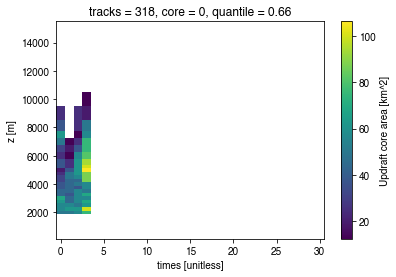

In [210]:
# Example to mask first updraft core and select a track to plot
ds_deep_final_d2.CoreArea_up.isel(core=0).where(Wmask_deep_final_d2 == 1).isel(tracks=29).transpose().sel(times=slice(0,30), z=slice(0,15000)).plot()

In [278]:
ds_deep_final_d2

<xarray.Dataset>
Dimensions:                  (tracks: 290, times: 212, height: 101, z: 40,
                              core: 10)
Coordinates:
  * tracks                   (tracks) int64 1 3 9 50 54 ... 2671 2672 2674 2685
  * times                    (times) int64 -12 -11 -10 -9 -8 ... 196 197 198 199
  * height                   (height) float64 0.0 200.0 400.0 ... 1.98e+04 2e+04
  * z                        (z) float64 250.0 500.0 750.0 ... 2e+04 2.1e+04
  * core                     (core) int64 0 1 2 3 4 5 6 7 8 9
    quantile                 float64 0.66
Data variables: (12/189)
    temperature              (tracks, times, height) float32 dask.array<chunksize=(290, 212, 101), meta=np.ndarray>
    qv                       (tracks, times, height) float32 dask.array<chunksize=(290, 212, 101), meta=np.ndarray>
    rh                       (tracks, times, height) float32 dask.array<chunksize=(290, 212, 101), meta=np.ndarray>
    pressure                 (tracks, times, height) float32 dask.array<chunksize=(290, 212, 101), meta=np.ndarray>
    u                        (tracks, times, height) float32 dask.array<chunksize=(290, 212, 101), meta=np.ndarray>
    v                        (tracks, times, height) float32 dask.array<chunksize=(290, 212, 101), meta=np.ndarray>
    ...                       ...
    start_split_tracknumber  (tracks) float64 dask.array<chunksize=(290,), meta=np.ndarray>
    start_split_timeindex    (tracks) float64 dask.array<chunksize=(290,), meta=np.ndarray>
    start_split_cloudnumber  (tracks) float64 dask.array<chunksize=(290,), meta=np.ndarray>
    end_merge_tracknumber    (tracks) float64 dask.array<chunksize=(290,), meta=np.ndarray>
    end_merge_timeindex      (tracks) float64 dask.array<chunksize=(290,), meta=np.ndarray>
    end_merge_cloudnumber    (tracks) float64 dask.array<chunksize=(290,), meta=np.ndarray>
Attributes:
    title:                 Tracked cell W statistics
    source_trackfile:      /gpfs/wolf/atm131/proj-shared/zfeng/cacti/meso/201...
    startdate:             20181129.1200
    enddate:               20181130.0000
    timegap_hour:          0.5
    time_resolution_hour:  0.08333
    pixel_radius_km:       2.5

## Compute lifetime-max updraft statistics

In [213]:
prof_quantiles = [0.25, 0.5, 0.75]

# Suppress RuntimeWarning messages
warnings.filterwarnings("ignore", category=RuntimeWarning)

# Deep
trackmax_CoreAreaUp_deep_prof_pts_d2 = ds_deep_final_d2.CoreArea_up.isel(core=0).where(Wmask_deep_final_d2 == 1).max(dim='times').quantile(prof_quantiles, dim='tracks', keep_attrs=True, skipna=True).load()
trackmax_CoreMeanWUp_deep_prof_pts_d2 = ds_deep_final_d2.CoreMeanW_up.isel(core=0).where(Wmask_deep_final_d2 == 1).max(dim='times').quantile(prof_quantiles, dim='tracks', keep_attrs=True, skipna=True).load()
trackmax_CoreMaxWUp_deep_prof_pts_d2 = ds_deep_final_d2.CoreMaxW_up.isel(core=0).where(Wmask_deep_final_d2 == 1).max(dim='times').quantile(prof_quantiles, dim='tracks', keep_attrs=True, skipna=True).load()
trackmax_CoreMassfluxUp_deep_prof_pts_d2 = ds_deep_final_d2.CoreMassFlux_up.isel(core=0).where(Wmask_deep_final_d2 == 1).max(dim='times').quantile(prof_quantiles, dim='tracks', keep_attrs=True, skipna=True).load()
trackmax_MassfluxUp_deep_prof_pts_d2 = ds_deep_final_d2.MassFlux_up.where(Wmask_deep_final_d2 == 1).max(dim='times').quantile(prof_quantiles, dim='tracks', keep_attrs=True, skipna=True).load()
trackmax_CoreThteMaxUp_deep_prof_pts_d2 = ds_deep_final_d2.CoreThteMax_up.isel(core=0).where(Wmask_deep_final_d2 == 1).max(dim='times').quantile(prof_quantiles, dim='tracks', keep_attrs=True, skipna=True).load()
trackmax_CoreBuoyThtvUp_deep_prof_pts_d2 = ds_deep_final_d2.CoreBuoyThtv_up.isel(core=0).where(Wmask_deep_final_d2 == 1).max(dim='times').quantile(prof_quantiles, dim='tracks', keep_attrs=True, skipna=True).load()
trackmin_CoreRHprm_deep_prof_pts_d2 = ds_deep_final_d2.CoreRhMean_prm.isel(core=0).where(Wmask_deep_final_d2 == 1).min(dim='times').quantile(prof_quantiles, dim='tracks', keep_attrs=True, skipna=True).load()

# Shallow
trackmax_CoreAreaUp_shallow_prof_pts_d2 = ds_shallow_final_d2.CoreArea_up.isel(core=0).max(dim='times').quantile(prof_quantiles, dim='tracks', keep_attrs=True, skipna=True).load()
trackmax_CoreMeanWUp_shallow_prof_pts_d2 = ds_shallow_final_d2.CoreMeanW_up.isel(core=0).max(dim='times').quantile(prof_quantiles, dim='tracks', keep_attrs=True, skipna=True).load()
trackmax_CoreMaxWUp_shallow_prof_pts_d2 = ds_shallow_final_d2.CoreMaxW_up.isel(core=0).max(dim='times').quantile(prof_quantiles, dim='tracks', keep_attrs=True, skipna=True).load()
trackmax_CoreMassfluxUp_shallow_prof_pts_d2 = ds_shallow_final_d2.CoreMassFlux_up.isel(core=0).max(dim='times').quantile(prof_quantiles, dim='tracks', keep_attrs=True, skipna=True).load()
trackmax_MassfluxUp_shallow_prof_pts_d2 = ds_shallow_final_d2.MassFlux_up.max(dim='times').quantile(prof_quantiles, dim='tracks', keep_attrs=True, skipna=True).load()
trackmax_CoreThteMaxUp_shallow_prof_pts_d2 = ds_shallow_final_d2.CoreThteMax_up.isel(core=0).max(dim='times').quantile(prof_quantiles, dim='tracks', keep_attrs=True, skipna=True).load()
trackmax_CoreBuoyThtvUp_shallow_prof_pts_d2 = ds_shallow_final_d2.CoreBuoyThtv_up.isel(core=0).max(dim='times').quantile(prof_quantiles, dim='tracks', keep_attrs=True, skipna=True).load()
trackmin_CoreRHprm_shallow_prof_pts_d2 = ds_shallow_final_d2.CoreRhMean_prm.isel(core=0).min(dim='times').quantile(prof_quantiles, dim='tracks', keep_attrs=True, skipna=True).load()

# Number of sample at each time & height for all tracks
nsample_CoreAreaUp_shallow_d2 = (ds_shallow_final_d2.CoreArea_up.isel(core=0) > 0).sum(dim='tracks').load()
nsample_CoreAreaUp_deep_d2 = (ds_deep_final_d4.CoreArea_up.isel(core=0).where(Wmask_deep_final_d4 == 1) > 0).sum(dim='tracks').load()

In [214]:
# Deep
trackmax_CoreAreaUp_deep_prof_pts_d3 = ds_deep_final_d3.CoreArea_up.isel(core=0).where(Wmask_deep_final_d3 == 1).max(dim='times').quantile(prof_quantiles, dim='tracks', keep_attrs=True, skipna=True).load()
trackmax_CoreMeanWUp_deep_prof_pts_d3 = ds_deep_final_d3.CoreMeanW_up.isel(core=0).where(Wmask_deep_final_d3 == 1).max(dim='times').quantile(prof_quantiles, dim='tracks', keep_attrs=True, skipna=True).load()
trackmax_CoreMaxWUp_deep_prof_pts_d3 = ds_deep_final_d3.CoreMaxW_up.isel(core=0).where(Wmask_deep_final_d3 == 1).max(dim='times').quantile(prof_quantiles, dim='tracks', keep_attrs=True, skipna=True).load()
trackmax_CoreMassfluxUp_deep_prof_pts_d3 = ds_deep_final_d3.CoreMassFlux_up.isel(core=0).where(Wmask_deep_final_d3 == 1).max(dim='times').quantile(prof_quantiles, dim='tracks', keep_attrs=True, skipna=True).load()
trackmax_MassfluxUp_deep_prof_pts_d3 = ds_deep_final_d3.MassFlux_up.where(Wmask_deep_final_d3 == 1).max(dim='times').quantile(prof_quantiles, dim='tracks', keep_attrs=True, skipna=True).load()
trackmax_CoreThteMaxUp_deep_prof_pts_d3 = ds_deep_final_d3.CoreThteMax_up.isel(core=0).where(Wmask_deep_final_d3 == 1).max(dim='times').quantile(prof_quantiles, dim='tracks', keep_attrs=True, skipna=True).load()
trackmax_CoreBuoyThtvUp_deep_prof_pts_d3 = ds_deep_final_d3.CoreBuoyThtv_up.isel(core=0).where(Wmask_deep_final_d3 == 1).max(dim='times').quantile(prof_quantiles, dim='tracks', keep_attrs=True, skipna=True).load()
trackmin_CoreRHprm_deep_prof_pts_d3 = ds_deep_final_d3.CoreRhMean_prm.isel(core=0).where(Wmask_deep_final_d3 == 1).min(dim='times').quantile(prof_quantiles, dim='tracks', keep_attrs=True, skipna=True).load()

# Shallow
trackmax_CoreAreaUp_shallow_prof_pts_d3 = ds_shallow_final_d3.CoreArea_up.isel(core=0).max(dim='times').quantile(prof_quantiles, dim='tracks', keep_attrs=True, skipna=True).load()
trackmax_CoreMeanWUp_shallow_prof_pts_d3 = ds_shallow_final_d3.CoreMeanW_up.isel(core=0).max(dim='times').quantile(prof_quantiles, dim='tracks', keep_attrs=True, skipna=True).load()
trackmax_CoreMaxWUp_shallow_prof_pts_d3 = ds_shallow_final_d3.CoreMaxW_up.isel(core=0).max(dim='times').quantile(prof_quantiles, dim='tracks', keep_attrs=True, skipna=True).load()
trackmax_CoreMassfluxUp_shallow_prof_pts_d3 = ds_shallow_final_d3.CoreMassFlux_up.isel(core=0).max(dim='times').quantile(prof_quantiles, dim='tracks', keep_attrs=True, skipna=True).load()
trackmax_MassfluxUp_shallow_prof_pts_d3 = ds_shallow_final_d3.MassFlux_up.max(dim='times').quantile(prof_quantiles, dim='tracks', keep_attrs=True, skipna=True).load()
trackmax_CoreThteMaxUp_shallow_prof_pts_d3 = ds_shallow_final_d3.CoreThteMax_up.isel(core=0).max(dim='times').quantile(prof_quantiles, dim='tracks', keep_attrs=True, skipna=True).load()
trackmax_CoreBuoyThtvUp_shallow_prof_pts_d3 = ds_shallow_final_d3.CoreBuoyThtv_up.isel(core=0).max(dim='times').quantile(prof_quantiles, dim='tracks', keep_attrs=True, skipna=True).load()
trackmin_CoreRHprm_shallow_prof_pts_d3 = ds_shallow_final_d3.CoreRhMean_prm.isel(core=0).min(dim='times').quantile(prof_quantiles, dim='tracks', keep_attrs=True, skipna=True).load()

# Number of sample at each time & height for all tracks
nsample_CoreAreaUp_shallow_d3 = (ds_shallow_final_d3.CoreArea_up.isel(core=0) > 0).sum(dim='tracks').load()
nsample_CoreAreaUp_deep_d3 = (ds_deep_final_d4.CoreArea_up.isel(core=0).where(Wmask_deep_final_d4 == 1) > 0).sum(dim='tracks').load()

In [215]:
# Deep
trackmax_CoreAreaUp_deep_prof_pts_d4 = ds_deep_final_d4.CoreArea_up.isel(core=0).where(Wmask_deep_final_d4 == 1).max(dim='times').quantile(prof_quantiles, dim='tracks', keep_attrs=True, skipna=True).load()
trackmax_CoreMeanWUp_deep_prof_pts_d4 = ds_deep_final_d4.CoreMeanW_up.isel(core=0).where(Wmask_deep_final_d4 == 1).max(dim='times').quantile(prof_quantiles, dim='tracks', keep_attrs=True, skipna=True).load()
trackmax_CoreMaxWUp_deep_prof_pts_d4 = ds_deep_final_d4.CoreMaxW_up.isel(core=0).where(Wmask_deep_final_d4 == 1).max(dim='times').quantile(prof_quantiles, dim='tracks', keep_attrs=True, skipna=True).load()
trackmax_CoreMassfluxUp_deep_prof_pts_d4 = ds_deep_final_d4.CoreMassFlux_up.isel(core=0).where(Wmask_deep_final_d4 == 1).max(dim='times').quantile(prof_quantiles, dim='tracks', keep_attrs=True, skipna=True).load()
trackmax_MassfluxUp_deep_prof_pts_d4 = ds_deep_final_d4.MassFlux_up.where(Wmask_deep_final_d4 == 1).max(dim='times').quantile(prof_quantiles, dim='tracks', keep_attrs=True, skipna=True).load()
trackmax_CoreThteMaxUp_deep_prof_pts_d4 = ds_deep_final_d4.CoreThteMax_up.isel(core=0).where(Wmask_deep_final_d4 == 1).max(dim='times').quantile(prof_quantiles, dim='tracks', keep_attrs=True, skipna=True).load()
trackmax_CoreBuoyThtvUp_deep_prof_pts_d4 = ds_deep_final_d4.CoreBuoyThtv_up.isel(core=0).where(Wmask_deep_final_d4 == 1).max(dim='times').quantile(prof_quantiles, dim='tracks', keep_attrs=True, skipna=True).load()
trackmin_CoreRHprm_deep_prof_pts_d4 = ds_deep_final_d4.CoreRhMean_prm.isel(core=0).where(Wmask_deep_final_d4 == 1).min(dim='times').quantile(prof_quantiles, dim='tracks', keep_attrs=True, skipna=True).load()

# Shallow
trackmax_CoreAreaUp_shallow_prof_pts_d4 = ds_shallow_final_d4.CoreArea_up.isel(core=0).max(dim='times').quantile(prof_quantiles, dim='tracks', keep_attrs=True, skipna=True).load()
trackmax_CoreMeanWUp_shallow_prof_pts_d4 = ds_shallow_final_d4.CoreMeanW_up.isel(core=0).max(dim='times').quantile(prof_quantiles, dim='tracks', keep_attrs=True, skipna=True).load()
trackmax_CoreMaxWUp_shallow_prof_pts_d4 = ds_shallow_final_d4.CoreMaxW_up.isel(core=0).max(dim='times').quantile(prof_quantiles, dim='tracks', keep_attrs=True, skipna=True).load()
trackmax_CoreMassfluxUp_shallow_prof_pts_d4 = ds_shallow_final_d4.CoreMassFlux_up.isel(core=0).max(dim='times').quantile(prof_quantiles, dim='tracks', keep_attrs=True, skipna=True).load()
trackmax_MassfluxUp_shallow_prof_pts_d4 = ds_shallow_final_d4.MassFlux_up.max(dim='times').quantile(prof_quantiles, dim='tracks', keep_attrs=True, skipna=True).load()
trackmax_CoreThteMaxUp_shallow_prof_pts_d4 = ds_shallow_final_d4.CoreThteMax_up.isel(core=0).max(dim='times').quantile(prof_quantiles, dim='tracks', keep_attrs=True, skipna=True).load()
trackmax_CoreBuoyThtvUp_shallow_prof_pts_d4 = ds_shallow_final_d4.CoreBuoyThtv_up.isel(core=0).max(dim='times').quantile(prof_quantiles, dim='tracks', keep_attrs=True, skipna=True).load()
trackmin_CoreRHprm_shallow_prof_pts_d4 = ds_shallow_final_d4.CoreRhMean_prm.isel(core=0).min(dim='times').quantile(prof_quantiles, dim='tracks', keep_attrs=True, skipna=True).load()

# Number of sample at each time & height for all tracks
nsample_CoreAreaUp_shallow_d4 = (ds_shallow_final_d4.CoreArea_up.isel(core=0) > 0).sum(dim='tracks').load()
nsample_CoreAreaUp_deep_d4 = (ds_deep_final_d4.CoreArea_up.isel(core=0).where(Wmask_deep_final_d4 == 1) > 0).sum(dim='tracks').load()

In [216]:
# Number of sample at each time & height for all tracks
track_ns_init_shallow_d2 = (ds_shallow_final_d2.CoreArea_up.isel(core=0) > 0).sum(dim=('tracks','times')).load()
track_ns_init_deep_d2 = (ds_deep_final_d4.CoreArea_up.isel(core=0).where(Wmask_deep_final_d4 == 1) > 0).sum(dim=('tracks','times')).load()

In [217]:
# Number of sample at each time & height for all tracks
track_ns_init_shallow_d3 = (ds_shallow_final_d3.CoreArea_up.isel(core=0) > 0).sum(dim=('tracks','times')).load()
track_ns_init_deep_d3 = (ds_deep_final_d4.CoreArea_up.isel(core=0).where(Wmask_deep_final_d4 == 1) > 0).sum(dim=('tracks','times')).load()

In [218]:
# Number of sample at each time & height for all tracks
track_ns_init_shallow_d4 = (ds_shallow_final_d4.CoreArea_up.isel(core=0) > 0).sum(dim=('tracks','times')).load()
track_ns_init_deep_d4 = (ds_deep_final_d4.CoreArea_up.isel(core=0).where(Wmask_deep_final_d4 == 1) > 0).sum(dim=('tracks','times')).load()

In [266]:
# trackmin_CoreRHprm_deep_prof_pts_d4 = ds_deep_final_d4.CoreRhMean_prm.isel(core=0).where(Wmask_deep_final_d4 == 1).min(dim='times').quantile(prof_quantiles, dim='tracks', keep_attrs=True, skipna=True).load()
# trackmin_CoreRHprm_shallow_prof_pts_d4 = ds_shallow_final_d4.CoreRhMean_prm.isel(core=0).min(dim='times').quantile(prof_quantiles, dim='tracks', keep_attrs=True, skipna=True).load()

In [267]:
# trackmin_CoreRHprm_deep_prof_pts_d3 = ds_deep_final_d3.CoreRhMean_prm.isel(core=0).where(Wmask_deep_final_d3 == 1).min(dim='times').quantile(prof_quantiles, dim='tracks', keep_attrs=True, skipna=True).load()

# trackmin_CoreRHprm_shallow_prof_pts_d3 = ds_shallow_final_d3.CoreRhMean_prm.isel(core=0).min(dim='times').quantile(prof_quantiles, dim='tracks', keep_attrs=True, skipna=True).load()

In [268]:
# trackmin_CoreRHprm_deep_prof_pts_d2 = ds_deep_final_d2.CoreRhMean_prm.isel(core=0).where(Wmask_deep_final_d2 == 1).min(dim='times').quantile(prof_quantiles, dim='tracks', keep_attrs=True, skipna=True).load()

# trackmin_CoreRHprm_shallow_prof_pts_d2 = ds_shallow_final_d2.CoreRhMean_prm.isel(core=0).min(dim='times').quantile(prof_quantiles, dim='tracks', keep_attrs=True, skipna=True).load()

In [219]:
# trackmax_CoreThteMaxUp_deep_prof_pts_d2 = ds_deep_final_d2.CoreThteMax_up.isel(core=0).where(Wmask_deep_final_d2 == 1).max(dim='times').quantile(prof_quantiles, dim='tracks', keep_attrs=True, skipna=True).load()
# trackmax_CoreThteMaxUp_shallow_prof_pts_d2 = ds_shallow_final_d2.CoreThteMax_up.isel(core=0).max(dim='times').quantile(prof_quantiles, dim='tracks', keep_attrs=True, skipna=True).load()

In [220]:
# trackmax_CoreThteMaxUp_deep_prof_pts_d3 = ds_deep_final_d3.CoreThteMax_up.isel(core=0).where(Wmask_deep_final_d3 == 1).max(dim='times').quantile(prof_quantiles, dim='tracks', keep_attrs=True, skipna=True).load()
# trackmax_CoreThteMaxUp_shallow_prof_pts_d3 = ds_shallow_final_d3.CoreThteMax_up.isel(core=0).max(dim='times').quantile(prof_quantiles, dim='tracks', keep_attrs=True, skipna=True).load()

In [221]:
# trackmax_CoreThteMaxUp_deep_prof_pts_d4 = ds_deep_final_d4.CoreThteMax_up.isel(core=0).where(Wmask_deep_final_d4 == 1).max(dim='times').quantile(prof_quantiles, dim='tracks', keep_attrs=True, skipna=True).load()
# trackmax_CoreThteMaxUp_shallow_prof_pts_d4 = ds_shallow_final_d4.CoreThteMax_up.isel(core=0).max(dim='times').quantile(prof_quantiles, dim='tracks', keep_attrs=True, skipna=True).load()

In [230]:
# prof_quantiles = [0.25, 0.5, 0.75]
# trackmax_CoreAreaUp_shallow_prof_pts_d2sub = CoreArea_up_shallow_d2sub.max(dim='times').quantile(prof_quantiles, dim='tracks', keep_attrs=True, skipna=True)
# trackmax_CoreMaxWUp_shallow_prof_pts_d2sub = CoreMaxW_up_shallow_d2sub.max(dim='times').quantile(prof_quantiles, dim='tracks', keep_attrs=True, skipna=True)

# trackmax_CoreAreaUp_deep_prof_pts_d2sub = CoreArea_up_deep_d2sub.max(dim='times').quantile(prof_quantiles, dim='tracks', keep_attrs=True, skipna=True)
# trackmax_CoreMaxWUp_deep_prof_pts_d2sub = CoreMaxW_up_deep_d2sub.max(dim='times').quantile(prof_quantiles, dim='tracks', keep_attrs=True, skipna=True)

In [231]:
# trackmax_CoreAreaUp_shallow_prof_pts_d3sub = CoreArea_up_shallow_d3sub.max(dim='times').quantile(prof_quantiles, dim='tracks', keep_attrs=True, skipna=True)
# trackmax_CoreMaxWUp_shallow_prof_pts_d3sub = CoreMaxW_up_shallow_d3sub.max(dim='times').quantile(prof_quantiles, dim='tracks', keep_attrs=True, skipna=True)

# trackmax_CoreAreaUp_deep_prof_pts_d3sub = CoreArea_up_deep_d3sub.max(dim='times').quantile(prof_quantiles, dim='tracks', keep_attrs=True, skipna=True)
# trackmax_CoreMaxWUp_deep_prof_pts_d3sub = CoreMaxW_up_deep_d3sub.max(dim='times').quantile(prof_quantiles, dim='tracks', keep_attrs=True, skipna=True)

In [232]:
# trackmax_CoreAreaUp_shallow_prof_pts_d4sub = CoreArea_up_shallow_d4sub.max(dim='times').quantile(prof_quantiles, dim='tracks', keep_attrs=True, skipna=True)
# trackmax_CoreMaxWUp_shallow_prof_pts_d4sub = CoreMaxW_up_shallow_d4sub.max(dim='times').quantile(prof_quantiles, dim='tracks', keep_attrs=True, skipna=True)

# trackmax_CoreAreaUp_deep_prof_pts_d4sub = CoreArea_up_deep_d4sub.max(dim='times').quantile(prof_quantiles, dim='tracks', keep_attrs=True, skipna=True)
# trackmax_CoreMaxWUp_deep_prof_pts_d4sub = CoreMaxW_up_deep_d4sub.max(dim='times').quantile(prof_quantiles, dim='tracks', keep_attrs=True, skipna=True)

In [233]:
# # Calculate total number of samples
# track_ns_init_shallow_d2 = nsample_CoreArea_up_shallow_d2.sum(dim='times')
# track_ns_init_deep_d2 = nsample_CoreArea_up_deep_d2.sum(dim='times')

In [234]:
# track_ns_init_shallow_d3 = nsample_CoreArea_up_shallow_d3.sum(dim='times')
# track_ns_init_deep_d3 = nsample_CoreArea_up_deep_d3.sum(dim='times')

In [235]:
# track_ns_init_shallow_d4 = nsample_CoreArea_up_shallow_d4.sum(dim='times')
# track_ns_init_deep_d4 = nsample_CoreArea_up_deep_d4.sum(dim='times')

## Function to plot profiles

In [236]:
def plot_profiles(nrows, ncols, height, dict_s, dict_d, dict_s_3profs, dict_d_3profs,
                  legend=None, titles=None, xlables=None, ylabels=None, xlims=None, ylims=None, fontsize=None, figsize=None, figname=None):

    mpl.rcParams['font.size'] = fontsize
    mpl.rcParams['font.family'] = 'Helvetica'
    fig, axes = plt.subplots(nrows, ncols+2, figsize=figsize, dpi=150)
    lw = 4
    colors = {'s': 'dodgerblue', 'd': 'orangered'}
    colors_d = {'d2':'royalblue', 'd3':'lightseagreen', 'd4':'crimson'}
    
    for col in range(ncols):
        ax = axes[col]
        med_shallow = dict_s[col]['line']
        med_deep = dict_d[col]['line']
        fill_shallow = dict_s[col]['fill']
        fill_deep = dict_d[col]['fill']
        
        ax.plot(med_shallow, height, color=colors['s'], lw=lw, label='shallow')
        ax.plot(med_deep, height, color=colors['d'], lw=lw, label='deep')
        ax.fill_betweenx(height, fill_deep[0], fill_deep[1], facecolor=colors['d'], alpha=0.5)
        ax.fill_betweenx(height, fill_shallow[0], fill_shallow[1], facecolor=colors['s'], alpha=0.5)
        ax.grid(ls='--')
        if (ylims is not None): ax.set_ylim(ylims[col][0], ylims[col][1])
        if (xlims is not None): ax.set_xlim(xlims[col][0], xlims[col][1])
        ax.grid(ls='--')
        ax.set_title(titles[col], loc='left')
        ax.set_xlabel(xlabels[col])
        ax.set_ylabel(ylabels[col])
        ax.legend()

    # Second to last column 
    ax = axes[ncols]
    for key in dict_s_3profs.keys():
        med_shallow = dict_s_3profs[key]
        ax.plot(med_shallow, height, color=colors_d[key], lw=lw, label=legend[key])
        ax.grid(ls='--')
        ax.legend()
        ax.set_title(titles[ncols], loc='left')
        ax.set_xlabel(xlabels[ncols])
        if (ylims is not None): ax.set_ylim(ylims[col][0], ylims[col][1])
    # Last column 
    ax = axes[ncols+1]
    for key in dict_s_3profs.keys():
        med_deep = dict_d_3profs[key]
        ax.plot(med_deep, height, color=colors_d[key], lw=lw, label=legend[key])
        ax.grid(ls='--')
        ax.legend()
        ax.set_title(titles[ncols+1], loc='left')
        ax.set_xlabel(xlabels[ncols+1])
        if (ylims is not None): ax.set_ylim(ylims[col][0], ylims[col][1])
        
    fig.tight_layout()
    fig.savefig(figname, bbox_inches='tight', dpi=300, facecolor='w')
    return fig

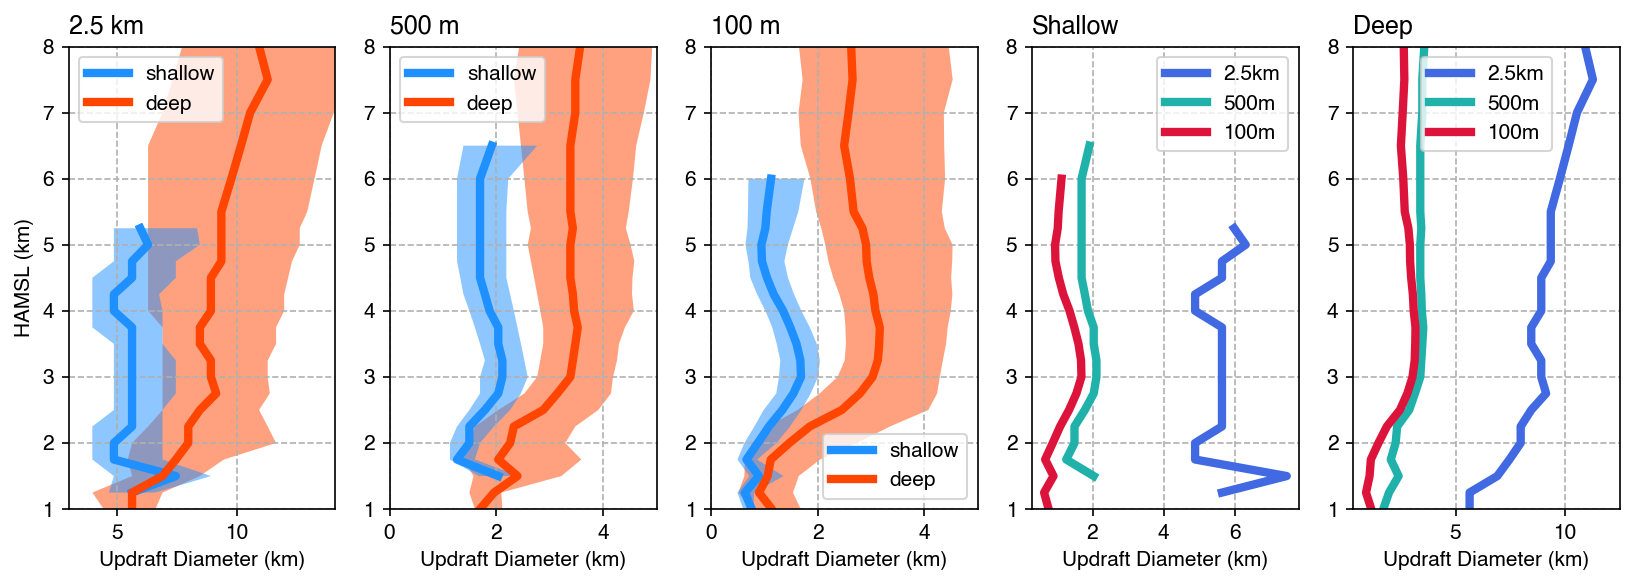

In [272]:
min_ns_shallow = 10
min_ns_deep = 10

# Convert CoreArea to CoreDiameter, filter heights with low samples
prof_s_d2 = np.sqrt(trackmax_CoreAreaUp_shallow_prof_pts_d2.where(track_ns_init_shallow_d2 >= min_ns_shallow)/np.pi)*2
prof_s_d3 = np.sqrt(trackmax_CoreAreaUp_shallow_prof_pts_d3.where(track_ns_init_shallow_d3 >= min_ns_shallow)/np.pi)*2
prof_s_d4 = np.sqrt(trackmax_CoreAreaUp_shallow_prof_pts_d4.where(track_ns_init_shallow_d4 >= min_ns_shallow)/np.pi)*2

prof_d_d2 = np.sqrt(trackmax_CoreAreaUp_deep_prof_pts_d2.where(track_ns_init_deep_d2 >= min_ns_deep)/np.pi)*2
prof_d_d3 = np.sqrt(trackmax_CoreAreaUp_deep_prof_pts_d3.where(track_ns_init_deep_d3 >= min_ns_deep)/np.pi)*2
prof_d_d4 = np.sqrt(trackmax_CoreAreaUp_deep_prof_pts_d4.where(track_ns_init_deep_d4 >= min_ns_deep)/np.pi)*2

dict_s = [
    {
        'line':prof_s_d2.sel(quantile=0.5),
        'fill':[prof_s_d2.sel(quantile=0.25), prof_s_d2.sel(quantile=0.75),],
    },
    {
        'line':prof_s_d3.sel(quantile=0.5),
        'fill':[prof_s_d3.sel(quantile=0.25), prof_s_d3.sel(quantile=0.75),],
    },
    {
        'line':prof_s_d4.sel(quantile=0.5),
        'fill':[prof_s_d4.sel(quantile=0.25), prof_s_d4.sel(quantile=0.75),],
    },
]
dict_d = [
    {
        'line':prof_d_d2.sel(quantile=0.5),
        'fill':[prof_d_d2.sel(quantile=0.25), prof_d_d2.sel(quantile=0.75),],
    },
    {
        'line':prof_d_d3.sel(quantile=0.5),
        'fill':[prof_d_d3.sel(quantile=0.25), prof_d_d3.sel(quantile=0.75),],
    },
    {
        'line':prof_d_d4.sel(quantile=0.5),
        'fill':[prof_d_d4.sel(quantile=0.25), prof_d_d4.sel(quantile=0.75),],
    },
]
dict_s_3profs = {'d2':prof_s_d2.sel(quantile=0.5), 'd3':prof_s_d3.sel(quantile=0.5), 'd4':prof_s_d4.sel(quantile=0.5),}
dict_d_3profs = {'d2':prof_d_d2.sel(quantile=0.5), 'd3':prof_d_d3.sel(quantile=0.5), 'd4':prof_d_d4.sel(quantile=0.5),}
legend_ds = {'d2':'2.5km', 'd3':'500m', 'd4':'100m'}
titles = ['2.5 km', '500 m', '100 m', 'Shallow', 'Deep']
ylabels = ['HAMSL (km)', '', '']
xlabels = ['Updraft Diameter (km)']*5
xlims = [(3,14.1),(0,5),(0,5)]
# xlims = None
ylims = [(1,8)]*3
figsize = (11,4)
fontsize = 10
figname = f'{figdir}Updraft_CoreDiameter_profiles_shallow_deep_d2_d3_d4.png'

fig = plot_profiles(1, 3, height, dict_s, dict_d, dict_s_3profs, dict_d_3profs, legend=legend_ds,
                    titles=titles, xlables=xlabels, ylabels=ylabels, xlims=xlims, ylims=ylims, fontsize=fontsize, figsize=figsize, figname=figname)

In [238]:
# min_ns_shallow = 10
# min_ns_deep = 10

# dict_s = [
#     {
#         'line':trackmax_CoreAreaUp_shallow_prof_pts_d2sub.sel(quantile=0.5).where(track_ns_init_shallow_d2 >= min_ns_shallow),
#         'fill':[trackmax_CoreAreaUp_shallow_prof_pts_d2sub.sel(quantile=0.25).where(track_ns_init_shallow_d2 >= min_ns_shallow),
#                 trackmax_CoreAreaUp_shallow_prof_pts_d2sub.sel(quantile=0.75).where(track_ns_init_shallow_d2 >= min_ns_shallow),],
#     },
#     {
#         'line':trackmax_CoreAreaUp_shallow_prof_pts_d3sub.sel(quantile=0.5).where(track_ns_init_shallow_d3 >= min_ns_shallow),
#         'fill':[trackmax_CoreAreaUp_shallow_prof_pts_d3sub.sel(quantile=0.25).where(track_ns_init_shallow_d3 >= min_ns_shallow),
#                 trackmax_CoreAreaUp_shallow_prof_pts_d3sub.sel(quantile=0.75).where(track_ns_init_shallow_d3 >= min_ns_shallow),],
#     },
#     {
#         'line':trackmax_CoreAreaUp_shallow_prof_pts_d4sub.sel(quantile=0.5).where(track_ns_init_shallow_d4 >= min_ns_shallow),
#         'fill':[trackmax_CoreAreaUp_shallow_prof_pts_d4sub.sel(quantile=0.25).where(track_ns_init_shallow_d4 >= min_ns_shallow),
#                 trackmax_CoreAreaUp_shallow_prof_pts_d4sub.sel(quantile=0.75).where(track_ns_init_shallow_d4 >= min_ns_shallow),],
#     },
# ]
# dict_d = [
#     {
#         'line':trackmax_CoreAreaUp_deep_prof_pts_d2sub.sel(quantile=0.5).where(track_ns_init_deep_d2 >= min_ns_deep),
#         'fill':[trackmax_CoreAreaUp_deep_prof_pts_d2sub.sel(quantile=0.25).where(track_ns_init_deep_d2 >= min_ns_deep),
#                trackmax_CoreAreaUp_deep_prof_pts_d2sub.sel(quantile=0.75).where(track_ns_init_deep_d2 >= min_ns_deep),],
#     },
#     {
#         'line':trackmax_CoreAreaUp_deep_prof_pts_d3sub.sel(quantile=0.5).where(track_ns_init_deep_d3 >= min_ns_deep),
#         'fill':[trackmax_CoreAreaUp_deep_prof_pts_d3sub.sel(quantile=0.25).where(track_ns_init_deep_d3 >= min_ns_deep),
#                trackmax_CoreAreaUp_deep_prof_pts_d3sub.sel(quantile=0.75).where(track_ns_init_deep_d3 >= min_ns_deep),],
#     },
#     {
#         'line':trackmax_CoreAreaUp_deep_prof_pts_d4sub.sel(quantile=0.5).where(track_ns_init_deep_d4 >= min_ns_deep),
#         'fill':[trackmax_CoreAreaUp_deep_prof_pts_d4sub.sel(quantile=0.25).where(track_ns_init_deep_d4 >= min_ns_deep),
#                trackmax_CoreAreaUp_deep_prof_pts_d4sub.sel(quantile=0.75).where(track_ns_init_deep_d4 >= min_ns_deep),],
#     }, 
# ]

# titles = ['2.5 km', '500 m', '100 m']
# ylabels = ['HAMSL (km)', '', '']
# xlabels = ['Updraft Diameter (km)']*3
# xlims = [(10,40),(0,8),(0,8)]
# ylims = [(1,7)]*3
# figsize = (10,4)
# fontsize = 12
# figname = f'{figdir}Updraft_CoreDiameter_profiles_shallow_deep_d2_d3_d4.png'

# fig = plot_profiles(1, 3, height, dict_s, dict_d,
#                     titles=titles, xlables=xlabels, ylabels=ylabels, xlims=xlims, ylims=ylims, fontsize=fontsize, figsize=figsize, figname=figname)

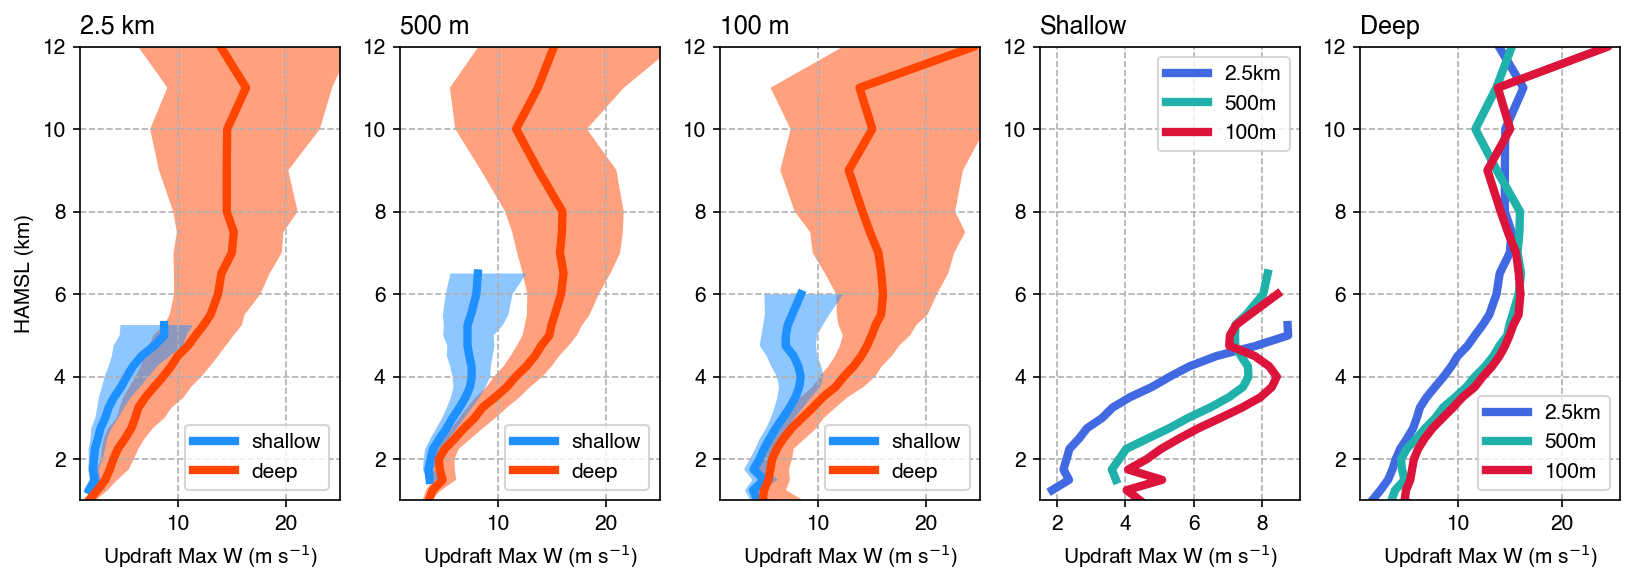

In [240]:
min_ns_shallow = 10
min_ns_deep = 10

# Convert CoreArea to CoreDiameter, filter heights with low samples
prof_s_d2 = trackmax_CoreMaxWUp_shallow_prof_pts_d2.where(track_ns_init_shallow_d2 >= min_ns_shallow)
prof_s_d3 = trackmax_CoreMaxWUp_shallow_prof_pts_d3.where(track_ns_init_shallow_d3 >= min_ns_shallow)
prof_s_d4 = trackmax_CoreMaxWUp_shallow_prof_pts_d4.where(track_ns_init_shallow_d4 >= min_ns_shallow)

prof_d_d2 = trackmax_CoreMaxWUp_deep_prof_pts_d2.where(track_ns_init_deep_d2 >= min_ns_deep)
prof_d_d3 = trackmax_CoreMaxWUp_deep_prof_pts_d3.where(track_ns_init_deep_d3 >= min_ns_deep)
prof_d_d4 = trackmax_CoreMaxWUp_deep_prof_pts_d4.where(track_ns_init_deep_d4 >= min_ns_deep)

dict_s = [
    {
        'line':prof_s_d2.sel(quantile=0.5),
        'fill':[prof_s_d2.sel(quantile=0.25), prof_s_d2.sel(quantile=0.75),],
    },
    {
        'line':prof_s_d3.sel(quantile=0.5),
        'fill':[prof_s_d3.sel(quantile=0.25), prof_s_d3.sel(quantile=0.75),],
    },
    {
        'line':prof_s_d4.sel(quantile=0.5),
        'fill':[prof_s_d4.sel(quantile=0.25), prof_s_d4.sel(quantile=0.75),],
    },
]
dict_d = [
    {
        'line':prof_d_d2.sel(quantile=0.5),
        'fill':[prof_d_d2.sel(quantile=0.25), prof_d_d2.sel(quantile=0.75),],
    },
    {
        'line':prof_d_d3.sel(quantile=0.5),
        'fill':[prof_d_d3.sel(quantile=0.25), prof_d_d3.sel(quantile=0.75),],
    },
    {
        'line':prof_d_d4.sel(quantile=0.5),
        'fill':[prof_d_d4.sel(quantile=0.25), prof_d_d4.sel(quantile=0.75),],
    },
]
dict_s_3profs = {'d2':prof_s_d2.sel(quantile=0.5), 'd3':prof_s_d3.sel(quantile=0.5), 'd4':prof_s_d4.sel(quantile=0.5),}
dict_d_3profs = {'d2':prof_d_d2.sel(quantile=0.5), 'd3':prof_d_d3.sel(quantile=0.5), 'd4':prof_d_d4.sel(quantile=0.5),}
legend_ds = {'d2':'2.5km', 'd3':'500m', 'd4':'100m'}
titles = ['2.5 km', '500 m', '100 m', 'Shallow', 'Deep']
ylabels = ['HAMSL (km)', '', '']
xlabels = ['Updraft Max W (m s$^{-1}$)']*5
xlims = [(1,25),(1,25),(1,25)]
# xlims = None
ylims = [(1,12)]*5
figsize = (11,4)
fontsize = 10
figname = f'{figdir}Updraft_CoreMaxW_profiles_shallow_deep_d2_d3_d4.png'

# ylims
fig = plot_profiles(1, 3, height, dict_s, dict_d, dict_s_3profs, dict_d_3profs,
                    legend=legend_ds, titles=titles, xlables=xlabels, ylabels=ylabels, xlims=xlims, ylims=ylims, fontsize=fontsize, figsize=figsize, figname=figname)

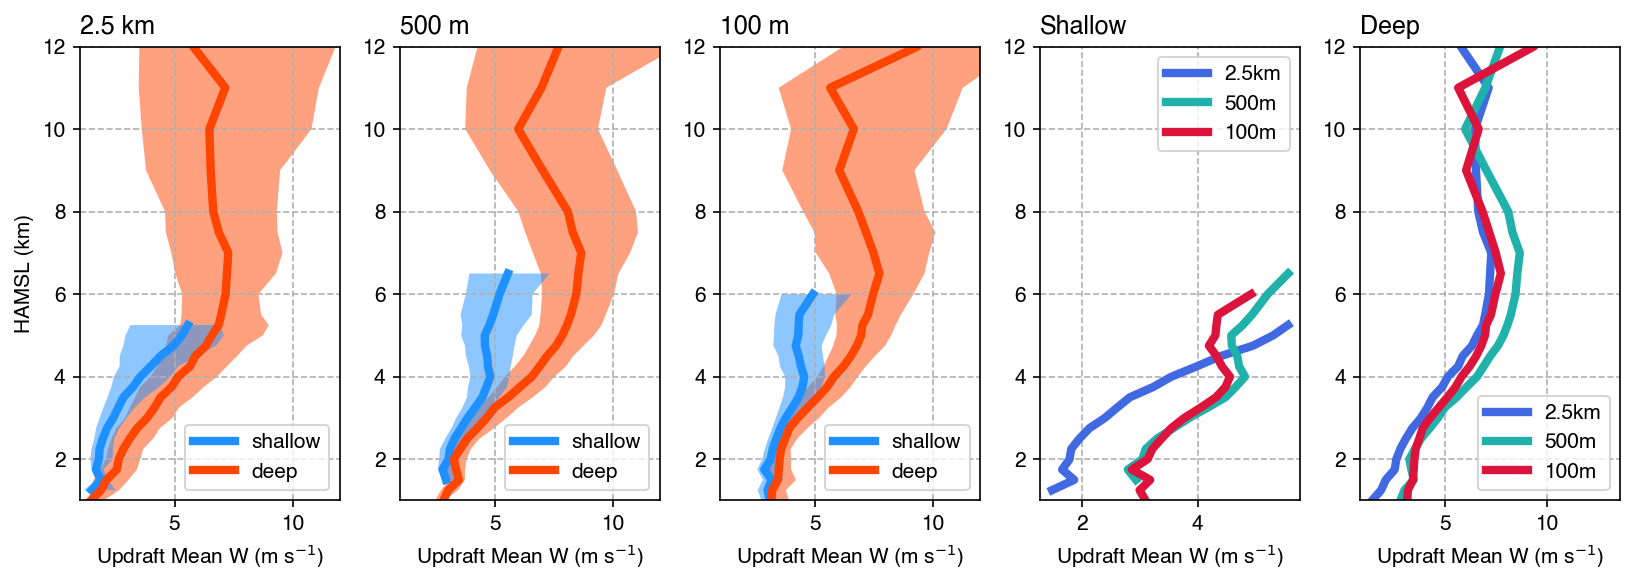

In [241]:
min_ns_shallow = 10
min_ns_deep = 10

# Filter heights with low samples
prof_s_d2 = trackmax_CoreMeanWUp_shallow_prof_pts_d2.where(track_ns_init_shallow_d2 >= min_ns_shallow)
prof_s_d3 = trackmax_CoreMeanWUp_shallow_prof_pts_d3.where(track_ns_init_shallow_d3 >= min_ns_shallow)
prof_s_d4 = trackmax_CoreMeanWUp_shallow_prof_pts_d4.where(track_ns_init_shallow_d4 >= min_ns_shallow)

prof_d_d2 = trackmax_CoreMeanWUp_deep_prof_pts_d2.where(track_ns_init_deep_d2 >= min_ns_deep)
prof_d_d3 = trackmax_CoreMeanWUp_deep_prof_pts_d3.where(track_ns_init_deep_d3 >= min_ns_deep)
prof_d_d4 = trackmax_CoreMeanWUp_deep_prof_pts_d4.where(track_ns_init_deep_d4 >= min_ns_deep)

dict_s = [
    {
        'line':prof_s_d2.sel(quantile=0.5),
        'fill':[prof_s_d2.sel(quantile=0.25), prof_s_d2.sel(quantile=0.75),],
    },
    {
        'line':prof_s_d3.sel(quantile=0.5),
        'fill':[prof_s_d3.sel(quantile=0.25), prof_s_d3.sel(quantile=0.75),],
    },
    {
        'line':prof_s_d4.sel(quantile=0.5),
        'fill':[prof_s_d4.sel(quantile=0.25), prof_s_d4.sel(quantile=0.75),],
    },
]
dict_d = [
    {
        'line':prof_d_d2.sel(quantile=0.5),
        'fill':[prof_d_d2.sel(quantile=0.25), prof_d_d2.sel(quantile=0.75),],
    },
    {
        'line':prof_d_d3.sel(quantile=0.5),
        'fill':[prof_d_d3.sel(quantile=0.25), prof_d_d3.sel(quantile=0.75),],
    },
    {
        'line':prof_d_d4.sel(quantile=0.5),
        'fill':[prof_d_d4.sel(quantile=0.25), prof_d_d4.sel(quantile=0.75),],
    },
]
dict_s_3profs = {'d2':prof_s_d2.sel(quantile=0.5), 'd3':prof_s_d3.sel(quantile=0.5), 'd4':prof_s_d4.sel(quantile=0.5),}
dict_d_3profs = {'d2':prof_d_d2.sel(quantile=0.5), 'd3':prof_d_d3.sel(quantile=0.5), 'd4':prof_d_d4.sel(quantile=0.5),}
legend_ds = {'d2':'2.5km', 'd3':'500m', 'd4':'100m'}
titles = ['2.5 km', '500 m', '100 m', 'Shallow', 'Deep']
ylabels = ['HAMSL (km)', '', '']
xlabels = ['Updraft Mean W (m s$^{-1}$)']*5
xlims = [(1,12),(1,12),(1,12)]
# xlims = None
ylims = [(1,12)]*3
figsize = (11,4)
fontsize = 10
figname = f'{figdir}Updraft_CoreMeanW_profiles_shallow_deep_d2_d3_d4.png'

# ylims
fig = plot_profiles(1, 3, height, dict_s, dict_d, dict_s_3profs, dict_d_3profs,
                    legend=legend_ds, titles=titles, xlables=xlabels, ylabels=ylabels, xlims=xlims, ylims=ylims, fontsize=fontsize, figsize=figsize, figname=figname)

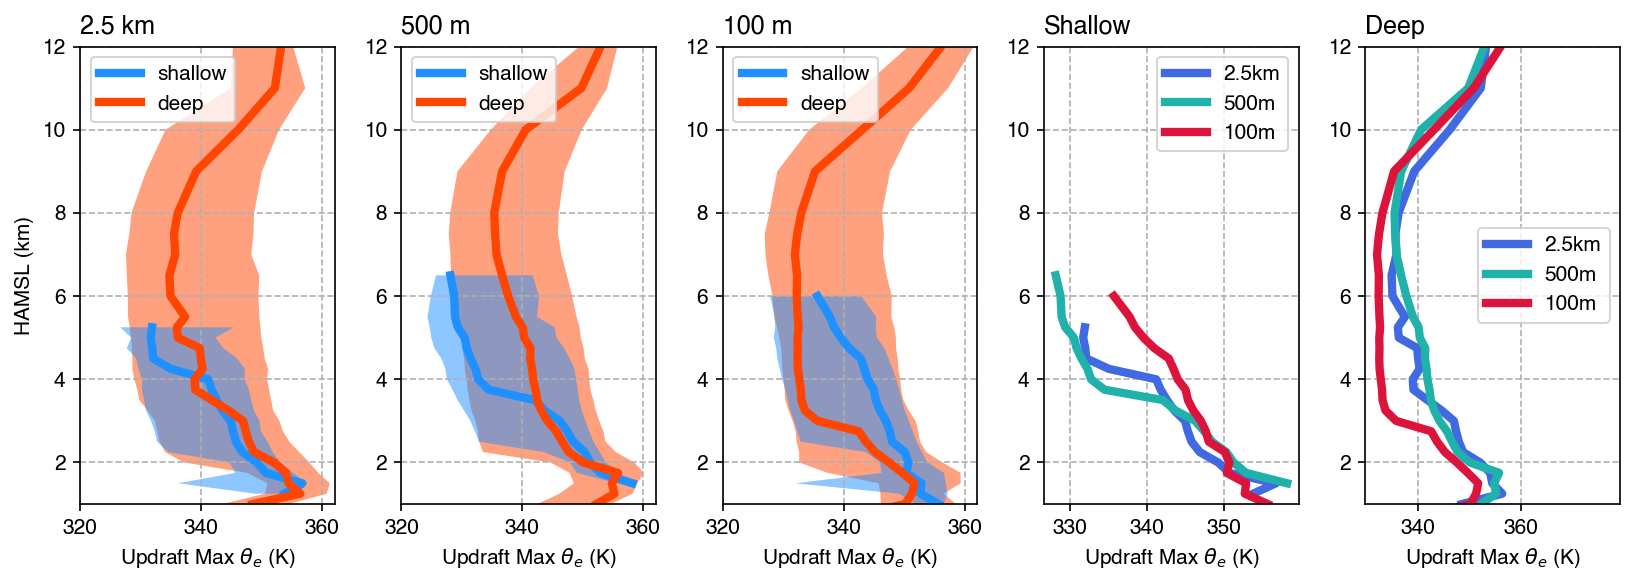

In [242]:
min_ns_shallow = 10
min_ns_deep = 10

# Filter heights with low samples
prof_s_d2 = trackmax_CoreThteMaxUp_shallow_prof_pts_d2.where(track_ns_init_shallow_d2 >= min_ns_shallow)
prof_s_d3 = trackmax_CoreThteMaxUp_shallow_prof_pts_d3.where(track_ns_init_shallow_d3 >= min_ns_shallow)
prof_s_d4 = trackmax_CoreThteMaxUp_shallow_prof_pts_d4.where(track_ns_init_shallow_d4 >= min_ns_shallow)

prof_d_d2 = trackmax_CoreThteMaxUp_deep_prof_pts_d2.where(track_ns_init_deep_d2 >= min_ns_deep)
prof_d_d3 = trackmax_CoreThteMaxUp_deep_prof_pts_d3.where(track_ns_init_deep_d3 >= min_ns_deep)
prof_d_d4 = trackmax_CoreThteMaxUp_deep_prof_pts_d4.where(track_ns_init_deep_d4 >= min_ns_deep)

dict_s = [
    {
        'line':prof_s_d2.sel(quantile=0.5),
        'fill':[prof_s_d2.sel(quantile=0.25), prof_s_d2.sel(quantile=0.75),],
    },
    {
        'line':prof_s_d3.sel(quantile=0.5),
        'fill':[prof_s_d3.sel(quantile=0.25), prof_s_d3.sel(quantile=0.75),],
    },
    {
        'line':prof_s_d4.sel(quantile=0.5),
        'fill':[prof_s_d4.sel(quantile=0.25), prof_s_d4.sel(quantile=0.75),],
    },
]
dict_d = [
    {
        'line':prof_d_d2.sel(quantile=0.5),
        'fill':[prof_d_d2.sel(quantile=0.25), prof_d_d2.sel(quantile=0.75),],
    },
    {
        'line':prof_d_d3.sel(quantile=0.5),
        'fill':[prof_d_d3.sel(quantile=0.25), prof_d_d3.sel(quantile=0.75),],
    },
    {
        'line':prof_d_d4.sel(quantile=0.5),
        'fill':[prof_d_d4.sel(quantile=0.25), prof_d_d4.sel(quantile=0.75),],
    },
]
dict_s_3profs = {'d2':prof_s_d2.sel(quantile=0.5), 'd3':prof_s_d3.sel(quantile=0.5), 'd4':prof_s_d4.sel(quantile=0.5),}
dict_d_3profs = {'d2':prof_d_d2.sel(quantile=0.5), 'd3':prof_d_d3.sel(quantile=0.5), 'd4':prof_d_d4.sel(quantile=0.5),}
legend_ds = {'d2':'2.5km', 'd3':'500m', 'd4':'100m'}
titles = ['2.5 km', '500 m', '100 m', 'Shallow', 'Deep']
ylabels = ['HAMSL (km)', '', '']
xlabels = ['Updraft Max '+r'$\theta_e$ '+'(K)']*5
# xlims = [(39,42.1),(39,42.1),(39,42.1)]
xlims = [(320,362.1),(320,362.1),(320,362.1)]
# xlims = None
ylims = [(1,12)]*3
figsize = (11,4)
fontsize = 10
figname = f'{figdir}Updraft_CoreMaxThetaE_profiles_shallow_deep_d2_d3_d4.png'

# ylims
fig = plot_profiles(1, 3, height, dict_s, dict_d, dict_s_3profs, dict_d_3profs,
                    legend=legend_ds, titles=titles, xlables=xlabels, ylabels=ylabels, xlims=xlims, ylims=ylims, fontsize=fontsize, figsize=figsize, figname=figname)

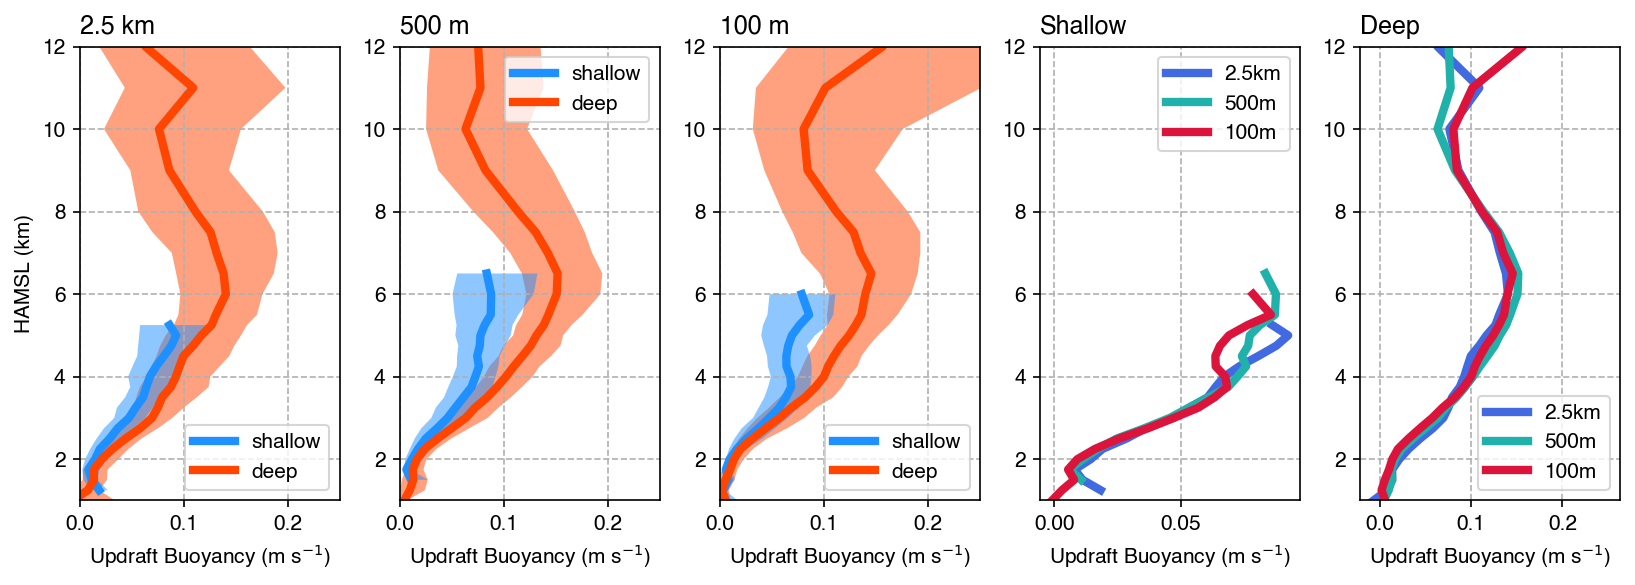

In [244]:
min_ns_shallow = 10
min_ns_deep = 10

# Filter heights with low samples
prof_s_d2 = trackmax_CoreBuoyThtvUp_shallow_prof_pts_d2.where(track_ns_init_shallow_d2 >= min_ns_shallow)
prof_s_d3 = trackmax_CoreBuoyThtvUp_shallow_prof_pts_d3.where(track_ns_init_shallow_d3 >= min_ns_shallow)
prof_s_d4 = trackmax_CoreBuoyThtvUp_shallow_prof_pts_d4.where(track_ns_init_shallow_d4 >= min_ns_shallow)

prof_d_d2 = trackmax_CoreBuoyThtvUp_deep_prof_pts_d2.where(track_ns_init_deep_d2 >= min_ns_deep)
prof_d_d3 = trackmax_CoreBuoyThtvUp_deep_prof_pts_d3.where(track_ns_init_deep_d3 >= min_ns_deep)
prof_d_d4 = trackmax_CoreBuoyThtvUp_deep_prof_pts_d4.where(track_ns_init_deep_d4 >= min_ns_deep)

dict_s = [
    {
        'line':prof_s_d2.sel(quantile=0.5),
        'fill':[prof_s_d2.sel(quantile=0.25), prof_s_d2.sel(quantile=0.75),],
    },
    {
        'line':prof_s_d3.sel(quantile=0.5),
        'fill':[prof_s_d3.sel(quantile=0.25), prof_s_d3.sel(quantile=0.75),],
    },
    {
        'line':prof_s_d4.sel(quantile=0.5),
        'fill':[prof_s_d4.sel(quantile=0.25), prof_s_d4.sel(quantile=0.75),],
    },
]
dict_d = [
    {
        'line':prof_d_d2.sel(quantile=0.5),
        'fill':[prof_d_d2.sel(quantile=0.25), prof_d_d2.sel(quantile=0.75),],
    },
    {
        'line':prof_d_d3.sel(quantile=0.5),
        'fill':[prof_d_d3.sel(quantile=0.25), prof_d_d3.sel(quantile=0.75),],
    },
    {
        'line':prof_d_d4.sel(quantile=0.5),
        'fill':[prof_d_d4.sel(quantile=0.25), prof_d_d4.sel(quantile=0.75),],
    },
]
dict_s_3profs = {'d2':prof_s_d2.sel(quantile=0.5), 'd3':prof_s_d3.sel(quantile=0.5), 'd4':prof_s_d4.sel(quantile=0.5),}
dict_d_3profs = {'d2':prof_d_d2.sel(quantile=0.5), 'd3':prof_d_d3.sel(quantile=0.5), 'd4':prof_d_d4.sel(quantile=0.5),}
legend_ds = {'d2':'2.5km', 'd3':'500m', 'd4':'100m'}
titles = ['2.5 km', '500 m', '100 m', 'Shallow', 'Deep']
ylabels = ['HAMSL (km)', '', '']
xlabels = ['Updraft Buoyancy (m s$^{-1}$)']*5
xlims = [(0,0.25),(0,0.25),(0,0.25)]
# xlims = None
ylims = [(1,12)]*3
figsize = (11,4)
fontsize = 10
figname = f'{figdir}Updraft_CoreBuoyThetavUp_profiles_shallow_deep_d2_d3_d4.png'

# ylims
fig = plot_profiles(1, 3, height, dict_s, dict_d, dict_s_3profs, dict_d_3profs,
                    legend=legend_ds, titles=titles, xlables=xlabels, ylabels=ylabels, xlims=xlims, ylims=ylims, fontsize=fontsize, figsize=figsize, figname=figname)

In [273]:
trackmin_CoreRHprm_shallow_prof_pts_d2

<xarray.DataArray 'CoreRhMean_prm' (quantile: 3, z: 40)>
array([[        nan,         nan,         nan, 97.51010132, 91.09586143,
        93.89060974, 91.83100128, 92.26971436, 90.75030708, 88.14490318,
        85.73861313, 80.44205666, 76.52352905, 70.79258728, 65.55137253,
        61.1006279 , 58.75331974, 56.07372665, 56.18742752, 57.18887711,
        49.0506382 ,         nan,         nan,         nan,         nan,
                nan,         nan,         nan,         nan,         nan,
                nan,         nan,         nan,         nan,         nan,
                nan,         nan,         nan,         nan,         nan],
       [        nan,         nan,         nan, 97.51010132, 94.45663452,
        95.46656799, 94.67749023, 94.52758789, 93.54734039, 91.99486923,
        91.37808228, 88.24348068, 85.83341217, 82.3400116 , 77.97050476,
        71.76709747, 71.28924179, 67.86734009, 67.14990234, 66.19680786,
        64.58401108,         nan,         nan,         nan,         nan,
                nan,         nan,         nan,         nan,         nan,
                nan,         nan,         nan,         nan,         nan,
                nan,         nan,         nan,         nan,         nan],
       [        nan,         nan,         nan, 97.51010132, 98.06784248,
        96.62782288, 97.37138367, 96.76138306, 95.91197395, 95.64430809,
        94.99992752, 93.35718346, 92.4462471 , 89.46047974, 86.17047501,
        82.42282104, 79.49655914, 76.29999542, 76.43881226, 74.75361633,
        78.84699059,         nan,         nan,         nan,         nan,
                nan,         nan,         nan,         nan,         nan,
                nan,         nan,         nan,         nan,         nan,
                nan,         nan,         nan,         nan,         nan]])
Coordinates:
  * z         (z) float64 250.0 500.0 750.0 1e+03 ... 1.9e+04 2e+04 2.1e+04
  * quantile  (quantile) float64 0.25 0.5 0.75

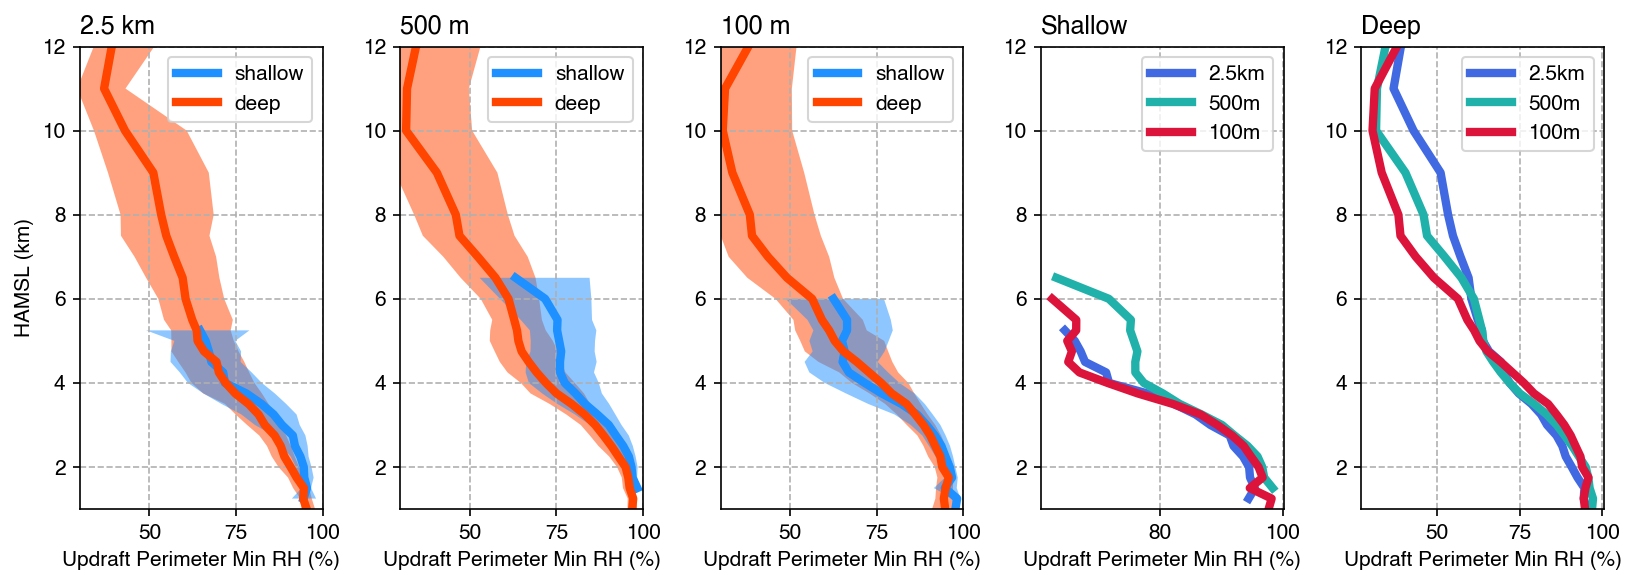

In [277]:
min_ns_shallow = 10
min_ns_deep = 10

# Filter heights with low samples
prof_s_d2 = trackmin_CoreRHprm_shallow_prof_pts_d2.where(track_ns_init_shallow_d2 >= min_ns_shallow)
prof_s_d3 = trackmin_CoreRHprm_shallow_prof_pts_d3.where(track_ns_init_shallow_d3 >= min_ns_shallow)
prof_s_d4 = trackmin_CoreRHprm_shallow_prof_pts_d4.where(track_ns_init_shallow_d4 >= min_ns_shallow)

prof_d_d2 = trackmin_CoreRHprm_deep_prof_pts_d2.where(track_ns_init_deep_d2 >= min_ns_deep)
prof_d_d3 = trackmin_CoreRHprm_deep_prof_pts_d3.where(track_ns_init_deep_d3 >= min_ns_deep)
prof_d_d4 = trackmin_CoreRHprm_deep_prof_pts_d4.where(track_ns_init_deep_d4 >= min_ns_deep)

dict_s = [
    {
        'line':prof_s_d2.sel(quantile=0.5),
        'fill':[prof_s_d2.sel(quantile=0.25), prof_s_d2.sel(quantile=0.75),],
    },
    {
        'line':prof_s_d3.sel(quantile=0.5),
        'fill':[prof_s_d3.sel(quantile=0.25), prof_s_d3.sel(quantile=0.75),],
    },
    {
        'line':prof_s_d4.sel(quantile=0.5),
        'fill':[prof_s_d4.sel(quantile=0.25), prof_s_d4.sel(quantile=0.75),],
    },
]
dict_d = [
    {
        'line':prof_d_d2.sel(quantile=0.5),
        'fill':[prof_d_d2.sel(quantile=0.25), prof_d_d2.sel(quantile=0.75),],
    },
    {
        'line':prof_d_d3.sel(quantile=0.5),
        'fill':[prof_d_d3.sel(quantile=0.25), prof_d_d3.sel(quantile=0.75),],
    },
    {
        'line':prof_d_d4.sel(quantile=0.5),
        'fill':[prof_d_d4.sel(quantile=0.25), prof_d_d4.sel(quantile=0.75),],
    },
]
dict_s_3profs = {'d2':prof_s_d2.sel(quantile=0.5), 'd3':prof_s_d3.sel(quantile=0.5), 'd4':prof_s_d4.sel(quantile=0.5),}
dict_d_3profs = {'d2':prof_d_d2.sel(quantile=0.5), 'd3':prof_d_d3.sel(quantile=0.5), 'd4':prof_d_d4.sel(quantile=0.5),}
legend_ds = {'d2':'2.5km', 'd3':'500m', 'd4':'100m'}
titles = ['2.5 km', '500 m', '100 m', 'Shallow', 'Deep']
ylabels = ['HAMSL (km)', '', '']
xlabels = ['Updraft Perimeter Min RH (%)']*5
xlims = [(30,100),(30,100),(30,100)]
# xlims = None
ylims = [(1,12)]*3
figsize = (11,4)
fontsize = 10
figname = f'{figdir}Updraft_CoreRHperimeter_profiles_shallow_deep_d2_d3_d4.png'

# ylims
fig = plot_profiles(1, 3, height, dict_s, dict_d, dict_s_3profs, dict_d_3profs,
                    legend=legend_ds, titles=titles, xlables=xlabels, ylabels=ylabels, xlims=xlims, ylims=ylims, fontsize=fontsize, figsize=figsize, figname=figname)

In [245]:
# prof_quantiles = [0.25, 0.5, 0.75]
# trackmax_CoreAreaUp_shallow_d2 = CoreArea_up_shallow_d2.sel(times=slice(0,2)).max(dim='times')
# trackmax_CoreAreaUp_shallow_prof_pts_d2 = trackmax_CoreAreaUp_shallow_d2.quantile(prof_quantiles, dim='tracks', keep_attrs=True, skipna=True)
# trackmax_CoreMaxWUp_shallow_d2 = CoreMaxW_up_shallow_d2.sel(times=slice(0,2)).max(dim='times')
# trackmax_CoreMaxWUp_shallow_prof_pts_d2 = trackmax_CoreMaxWUp_shallow_d2.quantile(prof_quantiles, dim='tracks', keep_attrs=True, skipna=True)

# trackmax_CoreAreaUp_deep_d2 = CoreArea_up_deep_d2.sel(times=slice(0,2)).max(dim='times')
# trackmax_CoreAreaUp_deep_prof_pts_d2 = trackmax_CoreAreaUp_deep_d2.quantile(prof_quantiles, dim='tracks', keep_attrs=True, skipna=True)
# trackmax_CoreMaxWUp_deep_d2 = CoreMaxW_up_deep_d2.sel(times=slice(0,2)).max(dim='times')
# trackmax_CoreMaxWUp_deep_prof_pts_d2 = trackmax_CoreMaxWUp_deep_d2.quantile(prof_quantiles, dim='tracks', keep_attrs=True, skipna=True)

In [246]:
# trackmax_CoreAreaUp_shallow_d3 = CoreArea_up_shallow_d3.sel(times=slice(0,2)).max(dim='times')
# trackmax_CoreAreaUp_shallow_prof_pts_d3 = trackmax_CoreAreaUp_shallow_d3.quantile(prof_quantiles, dim='tracks', keep_attrs=True, skipna=True)
# trackmax_CoreMaxWUp_shallow_d3 = CoreMaxW_up_shallow_d3.sel(times=slice(0,2)).max(dim='times')
# trackmax_CoreMaxWUp_shallow_prof_pts_d3 = trackmax_CoreMaxWUp_shallow_d3.quantile(prof_quantiles, dim='tracks', keep_attrs=True, skipna=True)

# trackmax_CoreAreaUp_deep_d3 = CoreArea_up_deep_d3.sel(times=slice(0,2)).max(dim='times')
# trackmax_CoreAreaUp_deep_prof_pts_d3 = trackmax_CoreAreaUp_deep_d3.quantile(prof_quantiles, dim='tracks', keep_attrs=True, skipna=True)
# trackmax_CoreMaxWUp_deep_d3 = CoreMaxW_up_deep_d3.sel(times=slice(0,2)).max(dim='times')
# trackmax_CoreMaxWUp_deep_prof_pts_d3 = trackmax_CoreMaxWUp_deep_d3.quantile(prof_quantiles, dim='tracks', keep_attrs=True, skipna=True)

In [247]:
# trackmax_CoreAreaUp_shallow_d4 = CoreArea_up_shallow_d4.sel(times=slice(0,2)).max(dim='times')
# trackmax_CoreAreaUp_shallow_prof_pts_d4 = trackmax_CoreAreaUp_shallow_d4.quantile(prof_quantiles, dim='tracks', keep_attrs=True, skipna=True)
# trackmax_CoreMaxWUp_shallow_d4 = CoreMaxW_up_shallow_d4.sel(times=slice(0,2)).max(dim='times')
# trackmax_CoreMaxWUp_shallow_prof_pts_d4 = trackmax_CoreMaxWUp_shallow_d4.quantile(prof_quantiles, dim='tracks', keep_attrs=True, skipna=True)

# trackmax_CoreAreaUp_deep_d4 = CoreArea_up_deep_d4.sel(times=slice(0,2)).max(dim='times')
# trackmax_CoreAreaUp_deep_prof_pts_d4 = trackmax_CoreAreaUp_deep_d4.quantile(prof_quantiles, dim='tracks', keep_attrs=True, skipna=True)
# trackmax_CoreMaxWUp_deep_d4 = CoreMaxW_up_deep_d4.sel(times=slice(0,2)).max(dim='times')
# trackmax_CoreMaxWUp_deep_prof_pts_d4 = trackmax_CoreMaxWUp_deep_d4.quantile(prof_quantiles, dim='tracks', keep_attrs=True, skipna=True)

In [248]:
# # Calculate total number of samples during initial times
# track_ns_init_shallow_d2 = nsample_CoreArea_up_shallow_d2.sel(times=slice(0,2)).sum(dim='times')
# track_ns_init_deep_d2 = nsample_CoreArea_up_deep_d2.sel(times=slice(0,2)).sum(dim='times')

# track_ns_init_shallow_d3 = nsample_CoreArea_up_shallow_d3.sel(times=slice(0,2)).sum(dim='times')
# track_ns_init_deep_d3 = nsample_CoreArea_up_deep_d3.sel(times=slice(0,2)).sum(dim='times')

# track_ns_init_shallow_d4 = nsample_CoreArea_up_shallow_d4.sel(times=slice(0,2)).sum(dim='times')
# track_ns_init_deep_d4 = nsample_CoreArea_up_deep_d4.sel(times=slice(0,2)).sum(dim='times')

In [249]:
# fig, axes = plt.subplots(1, 3, figsize=(10,3), dpi=150, sharey=True)
# axes = axes.ravel()

# ax = axes[0]
# ax.plot(track_ns_init_shallow_d2, height, color='b', label='D2 shallow')
# ax.plot(track_ns_init_deep_d2, height, color='r', label='D2 deep')
# ax.legend()

# ax = axes[1]
# ax.plot(track_ns_init_shallow_d3, height, color='b', label='D3 shallow')
# ax.plot(track_ns_init_deep_d3, height, color='r', label='D3 deep')
# ax.legend()

# ax = axes[2]
# ax.plot(track_ns_init_shallow_d4, height, color='b', label='D4 shallow')
# ax.plot(track_ns_init_deep_d4, height, color='r', label='D4 deep')
# ax.legend()

# plt.subplots_adjust(left=None, bottom=None, right=None, top=None, wspace=0, hspace=0)

In [250]:
# track_ns_init_deep_d2

In [251]:
# fig, axes = plt.subplots(1, 3, figsize=(10,3), dpi=150)

# ax = axes[0]
# ax.plot(trackmax_CoreAreaUp_shallow_prof_pts_d2.sel(quantile=0.5).where(track_ns_init_shallow_d2 >= 5), height, color='b', label='D2 shallow')
# ax.plot(trackmax_CoreAreaUp_deep_prof_pts_d2.sel(quantile=0.5).where(track_ns_init_deep_d2 >= 10), height, color='r', label='D2 deep')
# ax.legend()
# ax.set_ylim(1,7)
# ax.set_xlim(10,20)

# ax = axes[1]
# ax.plot(trackmax_CoreAreaUp_shallow_prof_pts_d3.sel(quantile=0.5).where(track_ns_init_shallow_d3 >= 5), height, color='b', label='D3 shallow')
# ax.plot(trackmax_CoreAreaUp_deep_prof_pts_d3.sel(quantile=0.5).where(track_ns_init_deep_d3 >= 10), height, color='r', label='D3 deep')
# ax.legend()
# ax.set_ylim(1,7)
# ax.set_xlim(0,5)

# ax = axes[2]
# ax.plot(trackmax_CoreAreaUp_shallow_prof_pts_d4.sel(quantile=0.5).where(track_ns_init_shallow_d4 >= 5), height, color='b', label='D4 shallow')
# ax.plot(trackmax_CoreAreaUp_deep_prof_pts_d4.sel(quantile=0.5).where(track_ns_init_deep_d4 >= 10), height, color='r', label='D4 deep')
# ax.legend()
# ax.set_ylim(1,7)
# ax.set_xlim(0,5)

In [252]:
# fig, axes = plt.subplots(1, 3, figsize=(10,3), dpi=150)

# ax = axes[0]
# ax.plot(trackmax_CoreMaxWUp_shallow_prof_pts_d2.sel(quantile=0.5).where(track_ns_init_shallow_d2 >= 5), height, color='b', label='D2 shallow')
# ax.plot(trackmax_CoreMaxWUp_deep_prof_pts_d2.sel(quantile=0.5).where(track_ns_init_deep_d2 >= 10), height, color='r', label='D2 deep')
# ax.legend()
# ax.set_ylim(1,7)
# ax.set_xlim(2,10)

# ax = axes[1]
# ax.plot(trackmax_CoreMaxWUp_shallow_prof_pts_d3.sel(quantile=0.5).where(track_ns_init_shallow_d3 >= 5), height, color='b', label='D3 shallow')
# ax.plot(trackmax_CoreMaxWUp_deep_prof_pts_d3.sel(quantile=0.5).where(track_ns_init_deep_d3 >= 10), height, color='r', label='D3 deep')
# ax.legend()
# ax.set_ylim(1,7)
# ax.set_xlim(2,10)

# ax = axes[2]
# ax.plot(trackmax_CoreMaxWUp_shallow_prof_pts_d4.sel(quantile=0.5).where(track_ns_init_shallow_d4 >= 5), height, color='b', label='D4 shallow')
# ax.plot(trackmax_CoreMaxWUp_deep_prof_pts_d4.sel(quantile=0.5).where(track_ns_init_deep_d4 >= 10), height, color='r', label='D4 deep')
# ax.legend()
# ax.set_ylim(1,7)
# ax.set_xlim(2,10)

In [253]:
# prof_quantiles = [0.25, 0.5, 0.75]
# maxCoreAreaUp_shallow_d2 = dss_d2.CoreArea_up.where(max10dbz_d2 <= max10dbz_pts_d2[0], drop=True).isel(core=0).chunk(dict(tracks=-1)).max(dim='times')
# # maxCoreAreaUp_shallow_prof_pts_d2 = maxCoreAreaUp_shallow_d2.quantile(prof_quantiles, dim='tracks', keep_attrs=True, skipna=True)
# maxCoreAreaUp_shallow_prof_pts_d2 = maxCoreAreaUp_shallow_d2.where(maxCoreAreaUp_shallow_d2.z <= max10dbz_pts_d2[0]*1000).quantile(prof_quantiles, dim='tracks', keep_attrs=True, skipna=True)

In [254]:
# maxCoreAreaUp_deep_d2 = ds_d2.isel(tracks=tid_d2['nms']).CoreArea_up.where(max10dbz_d2 >= max10dbz_pts_d2[2], drop=True).isel(core=0).chunk(dict(tracks=-1)).max(dim='times')
# maxCoreAreaUp_deep_prof_pts_d2 = maxCoreAreaUp_deep_d2.where(maxCoreAreaUp_deep_d2.z <= max10dbz_pts_d2[2]*1000).quantile(prof_quantiles, dim='tracks', keep_attrs=True, skipna=True)

In [255]:
# ds_d2.isel(tracks=tid_d2['nms']).CoreArea_up.where(max10dbz_d2 <= max10dbz_pts_d2[0])

In [256]:
# maxCoreAreaUp_shallow_prof_pts_d2.sel(quantile=0.5).plot()
# maxCoreAreaUp_deep_prof_pts_d2.sel(quantile=0.5).plot()

In [257]:
# maxCoreAreaUp_shallow_prof_pts_d2.sel(quantile=0.75).plot()

In [258]:
# max10dbz_d2

In [259]:
# CoreAreaUp_shallow_d2 = ds_d2.isel(tracks=tid_d2['nms']).CoreArea_up.where(max10dbz_d2 <= max10dbz_pts_d2[0], drop=True).isel(core=0).chunk(dict(tracks=-1))
# CoreAreaUp_deep_d2 = ds_d2.isel(tracks=tid_d2['nms']).CoreArea_up.where(max10dbz_d2 >= max10dbz_pts_d2[2], drop=True).isel(core=0).chunk(dict(tracks=-1))

In [260]:
# CoreAreaUp_deep_d2 = ds_d2.isel(tracks=tid_d2['nms']).CoreArea_up.where(max10dbz_d2 >= max10dbz_pts_d2[2], drop=True).isel(core=0).load()

In [261]:
# # ds_d2.times
# time_res = 5.0  # [min]
# xtime = ds_d2.times * time_res
# height = ds_d2.z / 1000.